# 특장차 대기시간 분석

이 노트북은 `03_wait_time_data_preprocessing.ipynb`에서 생성한 특장차 분석용 데이터셋을 불러와 대기시간을 분석한다.

특장차는 `바로콜`, `전일접수`, `심야시간 사전예약`, `기타 예약성/미분류`가 함께 존재하므로 접수유형 후보별로 분석 대상을 분리한다. 정기접수는 고객 식별자가 없어 확정 분류하지 않고 `정기접수_가능패턴여부` 보조 플래그로만 확인한다.


In [18]:
import json
import platform
from pathlib import Path
import importlib

import statsmodels
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.regression as sns_regression

sns_regression = importlib.reload(sns_regression)

from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

print("statsmodels:", statsmodels.__version__)
print("seaborn:", sns.__version__)

statsmodels: 0.15.0
seaborn: 0.13.2


In [19]:
PROJECT_ROOT = Path("/Users/blaumonde/calltaxi-DA")
processed_dir = PROJECT_ROOT / "data" / "processed"

final_dataset_path = processed_dir / "특장차_대기시간_전처리_접수유형분류.csv"
final_summary_path = processed_dir / "특장차_대기시간_전처리_접수유형분류_요약.csv"

print("final_dataset_path", final_dataset_path.exists(), final_dataset_path)
print("final_summary_path", final_summary_path.exists(), final_summary_path)

final_dataset_path True /Users/blaumonde/calltaxi-DA/data/processed/특장차_대기시간_전처리_접수유형분류.csv
final_summary_path True /Users/blaumonde/calltaxi-DA/data/processed/특장차_대기시간_전처리_접수유형분류_요약.csv


In [20]:
datetime_cols = [
    "접수일시",
    "예정일시",
    "배차일시",
    "승차일시",
    "하차일시",
    "취소일시",
    "접수일자",
    "예정일자",
    "배차일자",
    "승차일자",
    "하차일자",
]

def read_special_dataset(path):
    df = pd.read_csv(path)
    for col in datetime_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

df_special = read_special_dataset(final_dataset_path)
special_analysis_dataset_summary = pd.read_csv(final_summary_path)

request_type_col = "특장차_접수유형_후보_최종"
if request_type_col not in df_special.columns:
    request_type_col = "특장차_접수유형_후보_보완"

special_ride_valid = df_special[
    df_special["특장차_탑승완료_시간논리정상여부"].fillna(False)
].copy()

special_ride_baro_call = special_ride_valid[
    special_ride_valid[request_type_col].eq("바로콜 후보")
].copy()

special_ride_previous_day = special_ride_valid[
    special_ride_valid[request_type_col].eq("전일접수 후보")
].copy()

special_ride_night_reservation = special_ride_valid[
    special_ride_valid[request_type_col].eq("심야시간 사전예약 후보")
].copy()

special_ride_other = special_ride_valid[
    special_ride_valid[request_type_col].eq("기타 예약성/미분류")
].copy()

special_cancel = df_special[df_special["취소일시"].notna()].copy()

print(f"특장차 전처리 전체: {len(df_special):,}건")
print(f"특장차 탑승완료 정상: {len(special_ride_valid):,}건")
print(f"접수유형 분류 컬럼: {request_type_col}")
display(special_analysis_dataset_summary)


특장차 전처리 전체: 1,393,534건
특장차 탑승완료 정상: 1,164,430건
접수유형 분류 컬럼: 특장차_접수유형_후보_최종


,구분,건수,비율_전체대비(%),요약구분,비율(%)
0,특장차 전체 전처리 건수,1393534,100.00,분석용 데이터셋,NaN
1,탑승완료 정상 건수,1164430,83.56,분석용 데이터셋,NaN
2,바로콜 후보 건수,1099084,78.87,분석용 데이터셋,NaN
3,전일접수 후보 건수,48931,3.51,분석용 데이터셋,NaN
4,심야시간 사전예약 후보 건수,116,0.01,분석용 데이터셋,NaN
5,기타 예약성/미분류 건수,16299,1.17,분석용 데이터셋,NaN
6,정기접수 가능패턴 건수,135789,9.74,분석용 데이터셋,NaN
7,취소 전체 건수,228987,16.43,분석용 데이터셋,NaN
8,바로콜 후보,1099084,NaN,접수유형 후보 분포,78.87
9,승차완료 외/분류대상 아님,229104,NaN,접수유형 후보 분포,16.44


## 1. 전처리 결과 및 분석 데이터셋 재확인

분석에 들어가기 전에 전처리 결과와 분석용 데이터셋 건수를 확인한다. 특히 접수유형 후보별 승차 완료 데이터셋과 취소 데이터셋을 분리해서 사용한다.


In [21]:
# 코드 셀 목적: 특장차 분석용 데이터셋 건수와 핵심 대기시간 유효 표본 수를 재확인한다.

analysis_dataset_summary = pd.DataFrame({
    "데이터셋": [
        "df_special",
        "special_ride_valid",
        "special_ride_baro_call",
        "special_ride_previous_day",
        "special_ride_night_reservation",
        "special_ride_other",
        "special_cancel",
    ],
    "용도": [
        "특장차 전체 전처리 결과",
        "특장차 탑승완료 정상 건",
        "특장차 바로콜 후보 승차 대기시간 분석",
        "특장차 전일접수 후보 대기시간 분석",
        "특장차 심야시간 사전예약 후보 분석",
        "특장차 기타 예약성/미분류 확인",
        "특장차 취소 전체 분석",
    ],
    "건수": [
        len(df_special),
        len(special_ride_valid),
        len(special_ride_baro_call),
        len(special_ride_previous_day),
        len(special_ride_night_reservation),
        len(special_ride_other),
        len(special_cancel),
    ],
})

wait_cols = [
    "접수_배차_분",
    "접수_승차_분",
    "접수_취소_분",
    "배차_취소_분",
    "배차_승차_분",
]

wait_valid_summary = pd.DataFrame({
    "컬럼명": wait_cols,
    "유효건수": [df_special[col].notna().sum() for col in wait_cols],
    "결측건수": [df_special[col].isna().sum() for col in wait_cols],
})

display(analysis_dataset_summary)
display(wait_valid_summary)


,데이터셋,용도,건수
0,df_special,특장차 전체 전처리 결과,1393534
1,special_ride_valid,특장차 탑승완료 정상 건,1164430
2,special_ride_baro_call,특장차 바로콜 후보 승차 대기시간 분석,1099084
3,special_ride_previous_day,특장차 전일접수 후보 대기시간 분석,48931
4,special_ride_night_reservation,특장차 심야시간 사전예약 후보 분석,116
5,special_ride_other,특장차 기타 예약성/미분류 확인,16299
6,special_cancel,특장차 취소 전체 분석,228987


,컬럼명,유효건수,결측건수
0,접수_배차_분,1215984,177550
1,접수_승차_분,1164483,229051
2,접수_취소_분,228987,1164547
3,배차_취소_분,51461,1342073
4,배차_승차_분,1164483,229051


## 2. 접수유형 후보별 기본 현황

접수유형 후보별 건수와 대기시간 분포를 비교한다. 특장차는 접수유형에 따라 `접수→승차`의 의미가 달라지므로 전체를 한 번에 해석하지 않는다.


In [22]:
# 코드 셀 목적: 접수유형 후보별 탑승완료 건수와 핵심 대기시간 요약을 확인한다.

request_type_summary = (
    special_ride_valid
    .groupby(request_type_col, observed=False)
    .agg(
        건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

request_type_summary["비율(%)"] = (
    request_type_summary["건수"] / request_type_summary["건수"].sum() * 100
)

display(request_type_summary.sort_values("건수", ascending=False))


,특장차_접수유형_후보_최종,건수,접수_배차_중앙값,접수_배차_90분위수,접수_승차_중앙값,접수_승차_90분위수,배차_승차_중앙값,배차_승차_90분위수,비율(%)
1,바로콜 후보,1099084,11.975408,72.116748,33.419308,95.134233,17.854283,29.419167,94.388156
3,전일접수 후보,48931,1443.255933,1449.309500,1460.757283,1476.484833,18.457550,29.163450,4.202142
0,기타 예약성/미분류,16299,1086.536383,1814.475167,1105.370783,1847.506310,20.005617,33.518490,1.399741
2,심야시간 사전예약 후보,116,847.613833,1062.402083,872.354642,1091.093333,25.086892,39.032008,0.009962


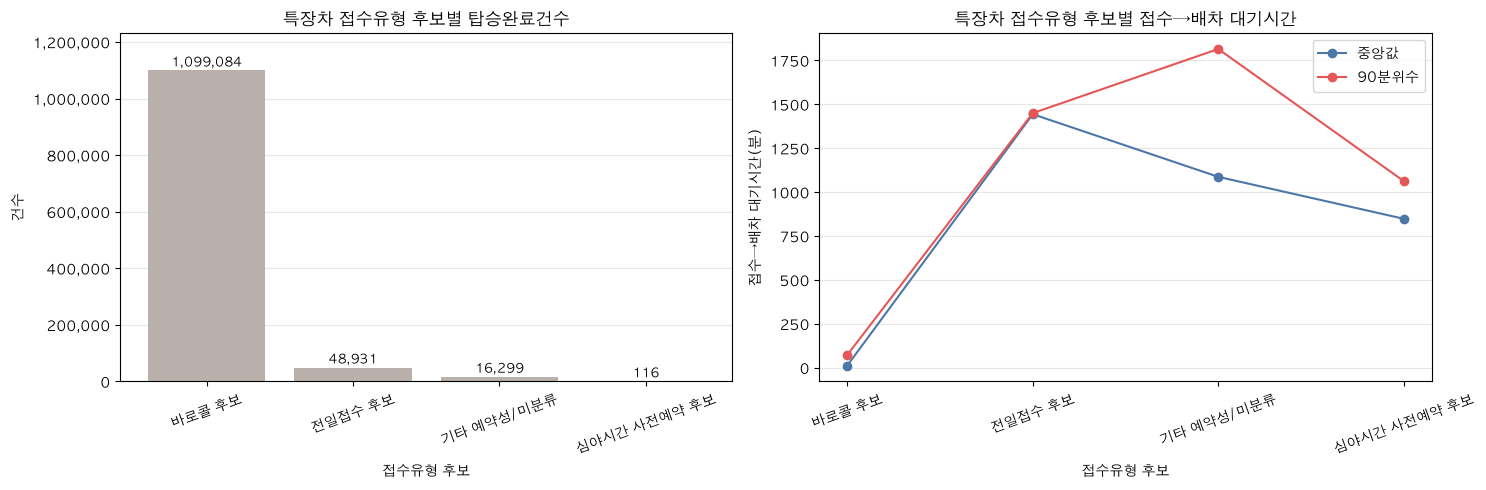

In [23]:
# 코드 셀 목적: 접수유형 후보별 건수와 접수→배차 90분위수를 함께 시각화한다.

from matplotlib.ticker import FuncFormatter

plot_data = request_type_summary.sort_values("건수", ascending=False).reset_index(drop=True)
x = range(len(plot_data))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(x, plot_data["건수"], color="#bab0ab")
for i, row in plot_data.iterrows():
    axes[0].text(
        i,
        row["건수"],
        f'{row["건수"]:,}',
        ha="center",
        va="bottom",
        fontsize=9,
    )

axes[0].set_title("특장차 접수유형 후보별 탑승완료건수")
axes[0].set_xlabel("접수유형 후보")
axes[0].set_ylabel("건수")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(plot_data[request_type_col], rotation=20)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{int(value):,}"))
axes[0].set_ylim(0, plot_data["건수"].max() * 1.12)
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(x, plot_data["접수_배차_중앙값"], marker="o", label="중앙값", color="#4c78a8")
axes[1].plot(x, plot_data["접수_배차_90분위수"], marker="o", label="90분위수", color="#e45756")
axes[1].set_title("특장차 접수유형 후보별 접수→배차 대기시간")
axes[1].set_xlabel("접수유형 후보")
axes[1].set_ylabel("접수→배차 대기시간(분)")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(plot_data[request_type_col], rotation=20)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. 특장차 바로콜 승차 대기시간 분석

바로콜 후보를 대상으로 `접수→배차`, `접수→승차`, `배차→승차`를 비교한다. 바로콜에서는 이용자가 체감하는 전체 대기시간인 `접수→승차`와, 공급 부족 가능성을 보여주는 `접수→배차`가 핵심 지표다.


In [24]:
# 코드 셀 목적: 특장차 바로콜 후보의 승차 대기시간 요약을 확인한다.

ride_wait_cols = ["접수_배차_분", "접수_승차_분", "배차_승차_분"]
baro_wait_summary = []

for col in ride_wait_cols:
    values = special_ride_baro_call[col].dropna()
    baro_wait_summary.append({
        "구간": col.replace("_", "→").replace("분", "").rstrip("→"),
        "건수": values.count(),
        "평균": values.mean(),
        "중앙값": values.median(),
        "75분위수": values.quantile(0.75),
        "90분위수": values.quantile(0.90),
        "95분위수": values.quantile(0.95),
        "99분위수": values.quantile(0.99),
        "최대값": values.max(),
    })

baro_wait_summary = pd.DataFrame(baro_wait_summary)
display(baro_wait_summary)


,구간,건수,평균,중앙값,75분위수,90분위수,95분위수,99분위수,최대값
0,접수→배차,1099084,27.472058,11.975408,36.918754,72.116748,107.834617,142.376381,198.331383
1,접수→승차,1099084,46.270226,33.419308,57.332404,95.134233,133.938383,166.639232,199.990767
2,배차→승차,1099084,18.798168,17.854283,23.560887,29.419167,33.463898,42.765773,137.371950


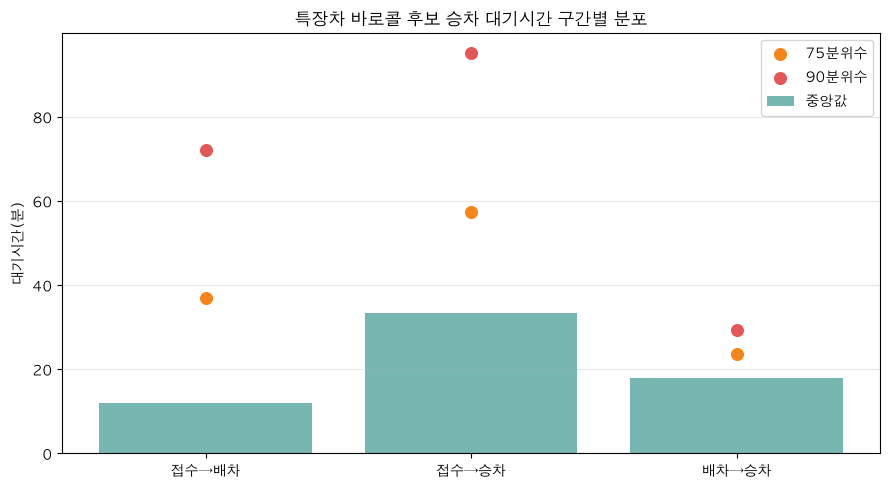

In [25]:
# 코드 셀 목적: 특장차 바로콜 후보의 대기시간 구간별 분포를 시각화한다.

plot_data = baro_wait_summary.copy()
x = range(len(plot_data))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x, plot_data["중앙값"], color="#76b7b2", label="중앙값")
ax.scatter(x, plot_data["75분위수"], color="#f58518", s=70, zorder=3, label="75분위수")
ax.scatter(x, plot_data["90분위수"], color="#e45756", s=70, zorder=3, label="90분위수")
ax.set_title("특장차 바로콜 후보 승차 대기시간 구간별 분포")
ax.set_ylabel("대기시간(분)")
ax.set_xticks(list(x))
ax.set_xticklabels(plot_data["구간"])
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


,접수시간대_HHMMSS,승차완료건수,접수_배차_중앙값,접수_배차_75분위수,접수_배차_90분위수,접수_승차_중앙값,접수_승차_75분위수,접수_승차_90분위수,배차_승차_중앙값,배차_승차_75분위수,배차_승차_90분위수
0,00:00:00,1685,12.794550,29.302833,49.737143,39.600500,54.929167,75.003963,23.566383,30.318450,36.497030
1,01:00:00,1024,11.816808,30.223437,78.963933,39.381117,56.781158,106.820100,22.865833,29.382300,36.537767
2,02:00:00,2546,97.308608,104.252900,110.526308,119.057758,130.913675,140.874892,22.815675,29.820642,36.451025
3,03:00:00,2583,9.864433,99.965258,111.006950,36.779667,127.465075,138.895287,22.610000,29.041808,36.020743
4,04:00:00,10542,133.877300,149.557138,163.818178,152.726200,170.161704,184.428728,19.408225,25.034504,31.062772
5,05:00:00,12134,128.158392,135.759938,150.307000,146.668533,161.238804,174.286215,19.959442,25.709204,31.179402
6,06:00:00,18466,51.965725,104.330867,136.965908,71.488633,125.876963,160.573467,18.909200,24.412142,29.906033
7,07:00:00,69751,36.519717,60.467833,76.104000,56.374617,80.251808,98.218717,19.556950,24.869967,30.216383
8,08:00:00,88382,36.083450,57.287000,73.659738,55.216083,76.687304,95.187872,18.757283,23.817346,28.861617
9,09:00:00,75245,19.072383,39.218450,69.865730,39.315000,59.139717,91.948830,18.462550,23.762167,29.060150


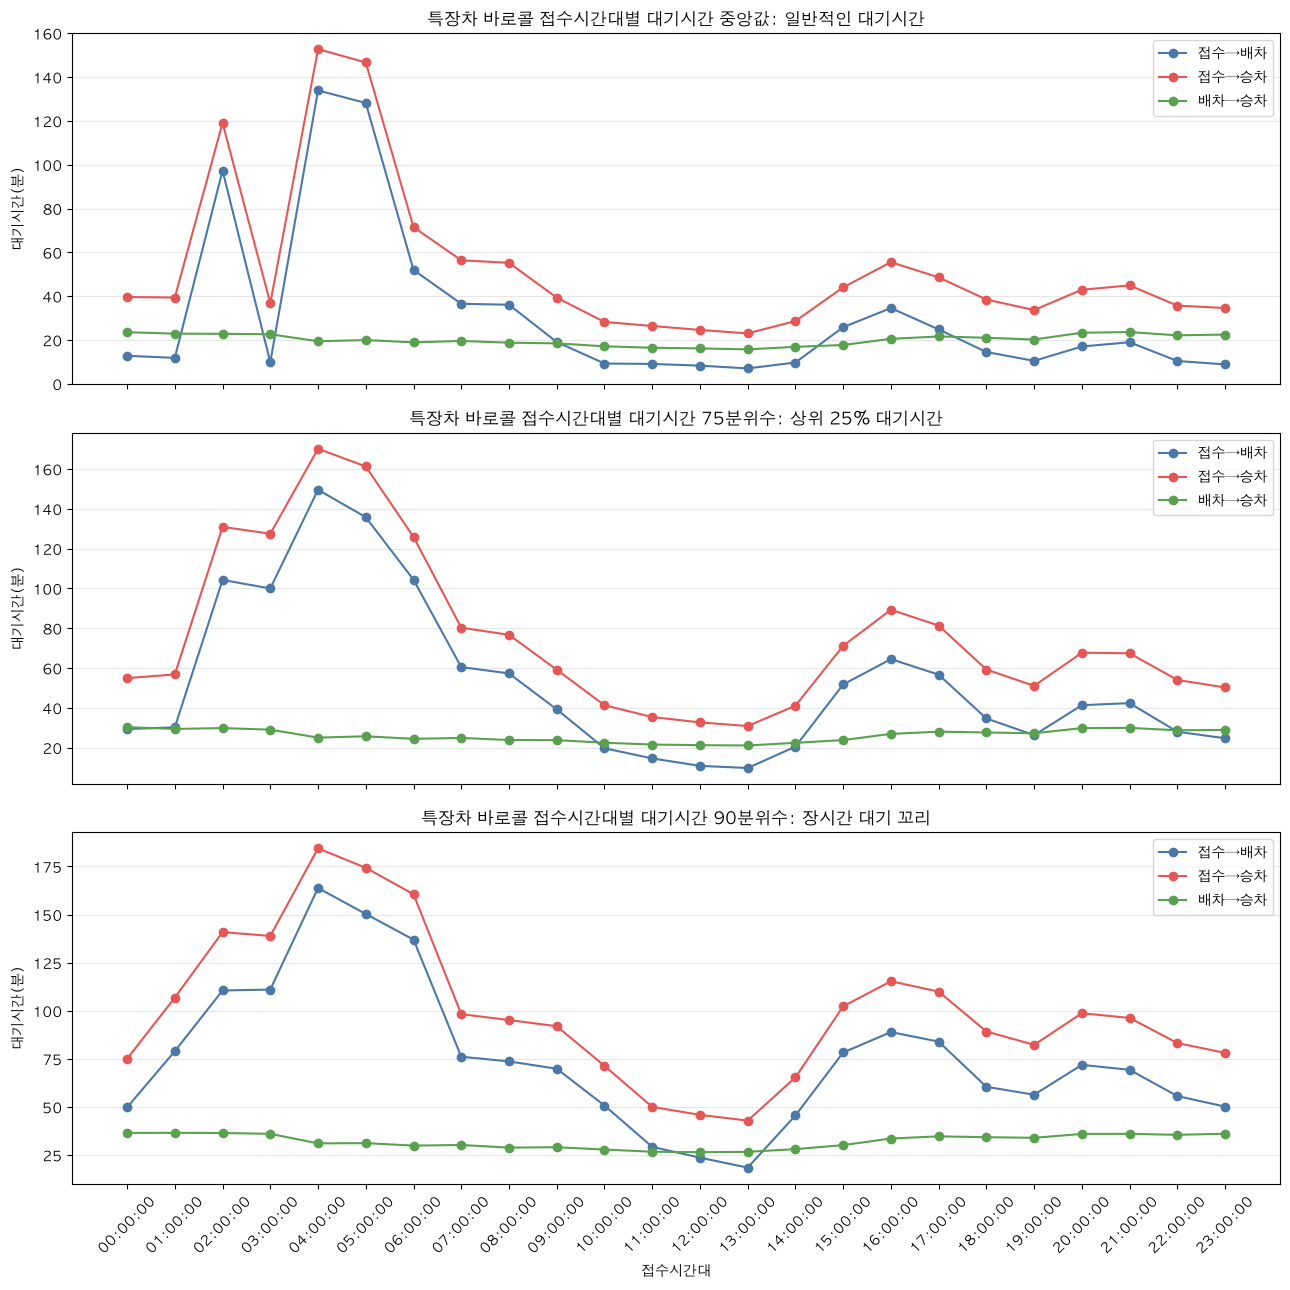

In [26]:
# 코드 셀 목적: 특장차 바로콜 후보에서 접수→승차 긴 꼬리가 접수→배차와 함께 움직이는지 확인한다.

baro_tail_compare = special_ride_baro_call.copy()

baro_tail_compare["접수일시"] = pd.to_datetime(
    baro_tail_compare["접수일시"],
    errors="coerce",
)
baro_tail_compare["접수시간대_HHMMSS"] = (
    baro_tail_compare["접수일시"]
    .dt.strftime("%H:00:00")
)

wait_cols = [
    "접수_배차_분",
    "접수_승차_분",
    "배차_승차_분",
]

for col in wait_cols:
    baro_tail_compare[col] = pd.to_numeric(
        baro_tail_compare[col],
        errors="coerce",
    )

hour_order = [f"{hour:02d}:00:00" for hour in range(24)]

baro_tail_hour_summary = (
    baro_tail_compare
    .groupby("접수시간대_HHMMSS", observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_75분위수=("접수_배차_분", lambda x: x.quantile(0.75)),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_75분위수=("접수_승차_분", lambda x: x.quantile(0.75)),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_75분위수=("배차_승차_분", lambda x: x.quantile(0.75)),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
    )
    .reindex(hour_order)
    .reset_index()
)

display(baro_tail_hour_summary)

fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=True)

quantile_settings = [
    ("중앙값", "일반적인 대기시간"),
    ("75분위수", "상위 25% 대기시간"),
    ("90분위수", "장시간 대기 꼬리"),
]

for ax, (suffix, title_suffix) in zip(axes, quantile_settings):
    ax.plot(
        baro_tail_hour_summary["접수시간대_HHMMSS"],
        baro_tail_hour_summary[f"접수_배차_{suffix}"],
        marker="o",
        label="접수→배차",
        color="#4c78a8",
    )
    ax.plot(
        baro_tail_hour_summary["접수시간대_HHMMSS"],
        baro_tail_hour_summary[f"접수_승차_{suffix}"],
        marker="o",
        label="접수→승차",
        color="#e45756",
    )
    ax.plot(
        baro_tail_hour_summary["접수시간대_HHMMSS"],
        baro_tail_hour_summary[f"배차_승차_{suffix}"],
        marker="o",
        label="배차→승차",
        color="#59a14f",
    )
    ax.set_title(f"특장차 바로콜 접수시간대별 대기시간 {suffix}: {title_suffix}")
    ax.set_ylabel("대기시간(분)")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("접수시간대")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3-1. 바로콜 접수시간대별 접수→배차 대기시간 상세

특장차 바로콜 후보만 대상으로 접수시간대별 `접수→배차` 대기시간을 다시 확인한다.

선그래프는 시간대별 중앙값, 75분위수, 90분위수 흐름을 보여준다. 아래 히트맵은 요일·접수시간대별 90분위수와 승차완료건수를 함께 보여주므로, 장시간 대기가 특정 요일 문제인지 시간대 문제인지 구분하는 데 사용한다.


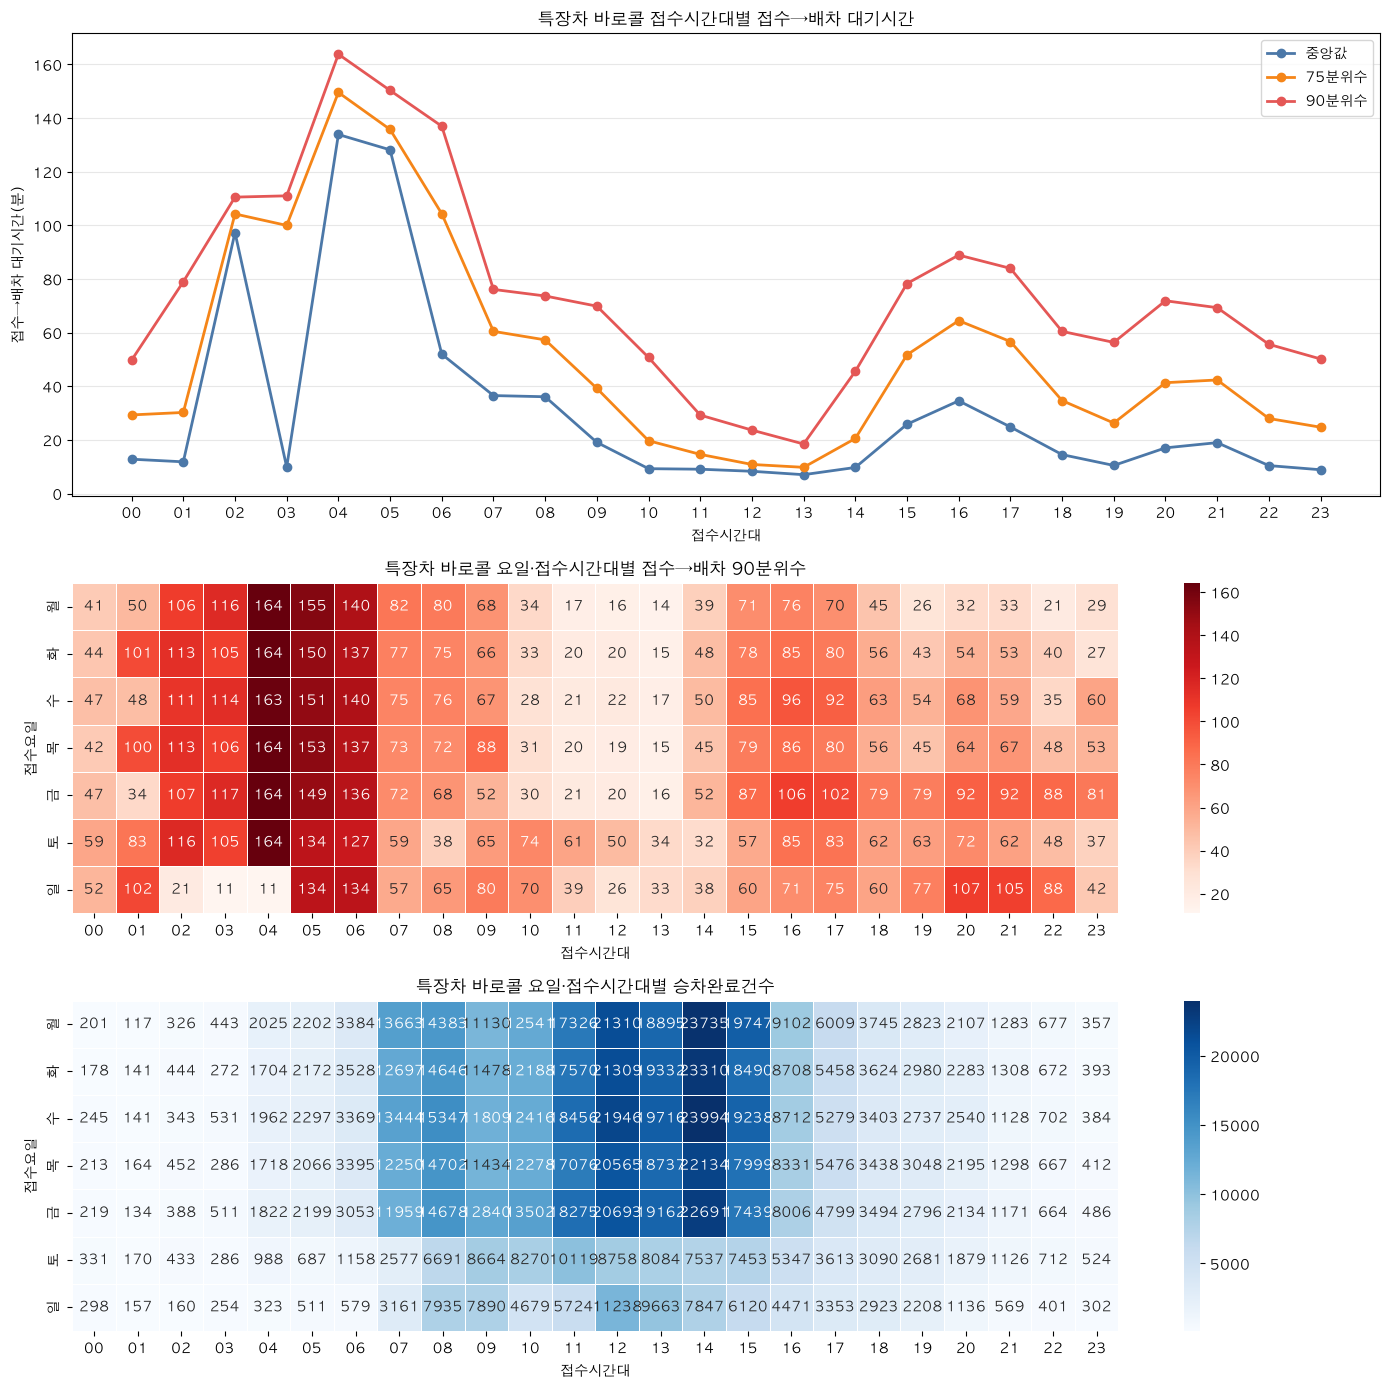

In [27]:
# 코드 셀 목적: 특장차 바로콜 후보의 접수시간대별 접수→배차 대기시간과 요일·시간대 히트맵을 함께 시각화한다.

baro_data = special_ride_baro_call.copy()

baro_data["접수일시"] = pd.to_datetime(baro_data["접수일시"], errors="coerce")
baro_data["접수시간대_HH"] = baro_data["접수일시"].dt.strftime("%H")
baro_data["접수_배차_분"] = pd.to_numeric(baro_data["접수_배차_분"], errors="coerce")

weekday_order = ["월", "화", "수", "목", "금", "토", "일"]

baro_dispatch_by_hour = (
    baro_data
    .dropna(subset=["접수시간대_HH", "접수_배차_분"])
    .groupby("접수시간대_HH", observed=False)
    .agg(
        건수=("접수_배차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_75분위수=("접수_배차_분", lambda x: x.quantile(0.75)),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
    .sort_values("접수시간대_HH")
)

dispatch_p90_heatmap = (
    baro_data
    .dropna(subset=["접수요일", "접수시간대_HH", "접수_배차_분"])
    .pivot_table(
        index="접수요일",
        columns="접수시간대_HH",
        values="접수_배차_분",
        aggfunc=lambda x: x.quantile(0.90),
        observed=False,
    )
    .reindex(weekday_order)
)

dispatch_count_heatmap = (
    baro_data
    .dropna(subset=["접수요일", "접수시간대_HH", "접수_배차_분"])
    .pivot_table(
        index="접수요일",
        columns="접수시간대_HH",
        values="접수_배차_분",
        aggfunc="count",
        observed=False,
    )
    .reindex(weekday_order)
)

fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(3, 1, height_ratios=[1.4, 1, 1])

ax_line = fig.add_subplot(gs[0, 0])
ax_heat1 = fig.add_subplot(gs[1, 0])
ax_heat2 = fig.add_subplot(gs[2, 0])

ax_line.plot(
    baro_dispatch_by_hour["접수시간대_HH"],
    baro_dispatch_by_hour["접수_배차_중앙값"],
    marker="o",
    linewidth=2,
    color="#4c78a8",
    label="중앙값",
)
ax_line.plot(
    baro_dispatch_by_hour["접수시간대_HH"],
    baro_dispatch_by_hour["접수_배차_75분위수"],
    marker="o",
    linewidth=2,
    color="#f58518",
    label="75분위수",
)
ax_line.plot(
    baro_dispatch_by_hour["접수시간대_HH"],
    baro_dispatch_by_hour["접수_배차_90분위수"],
    marker="o",
    linewidth=2,
    color="#e45756",
    label="90분위수",
)

ax_line.set_title("특장차 바로콜 접수시간대별 접수→배차 대기시간")
ax_line.set_xlabel("접수시간대")
ax_line.set_ylabel("접수→배차 대기시간(분)")
ax_line.grid(axis="y", alpha=0.3)
ax_line.legend()

sns.heatmap(
    dispatch_p90_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    ax=ax_heat1,
)
ax_heat1.set_title("특장차 바로콜 요일·접수시간대별 접수→배차 90분위수")
ax_heat1.set_xlabel("접수시간대")
ax_heat1.set_ylabel("접수요일")

sns.heatmap(
    dispatch_count_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax_heat2,
)
ax_heat2.set_title("특장차 바로콜 요일·접수시간대별 승차완료건수")
ax_heat2.set_xlabel("접수시간대")
ax_heat2.set_ylabel("접수요일")

plt.tight_layout()
plt.show()


특장차 바로콜은 수요가 많은 시간대와 대기시간 위험이 높은 시간대가 다르다.

- 낮 10~15시: 이용량이 많지만 배차 대기시간은 비교적 안정적
- 새벽 02~06시: 이용량은 적지만 접수→배차 장시간 대기 위험이 큼
- 04시 전후: 대부분 요일에서 90분위수가 매우 높아 위험 안내 필요
- 금요일 오후·저녁, 일요일 저녁: 추가 확인이 필요한 보조 위험 구간

따라서 경로추천에서는 단순 평균 대기시간이 아니라
요일×시간대별 접수→배차 75분위수·90분위수를 반영해야 한다.

## 3-2. 바로콜 접수→배차 대기시간 전체 분포

특장차 바로콜 후보의 `접수→배차` 대기시간 전체 분포를 확인한다.

히스토그램은 전체 대기시간이 어느 구간에 몰리는지 보여주고, 히트맵은 접수시간대별로 장시간 대기 구간이 어디에 집중되는지 보여준다. 두 번째 히트맵은 `0~10분`을 제외해 장시간 대기 패턴을 더 잘 보이게 한다.


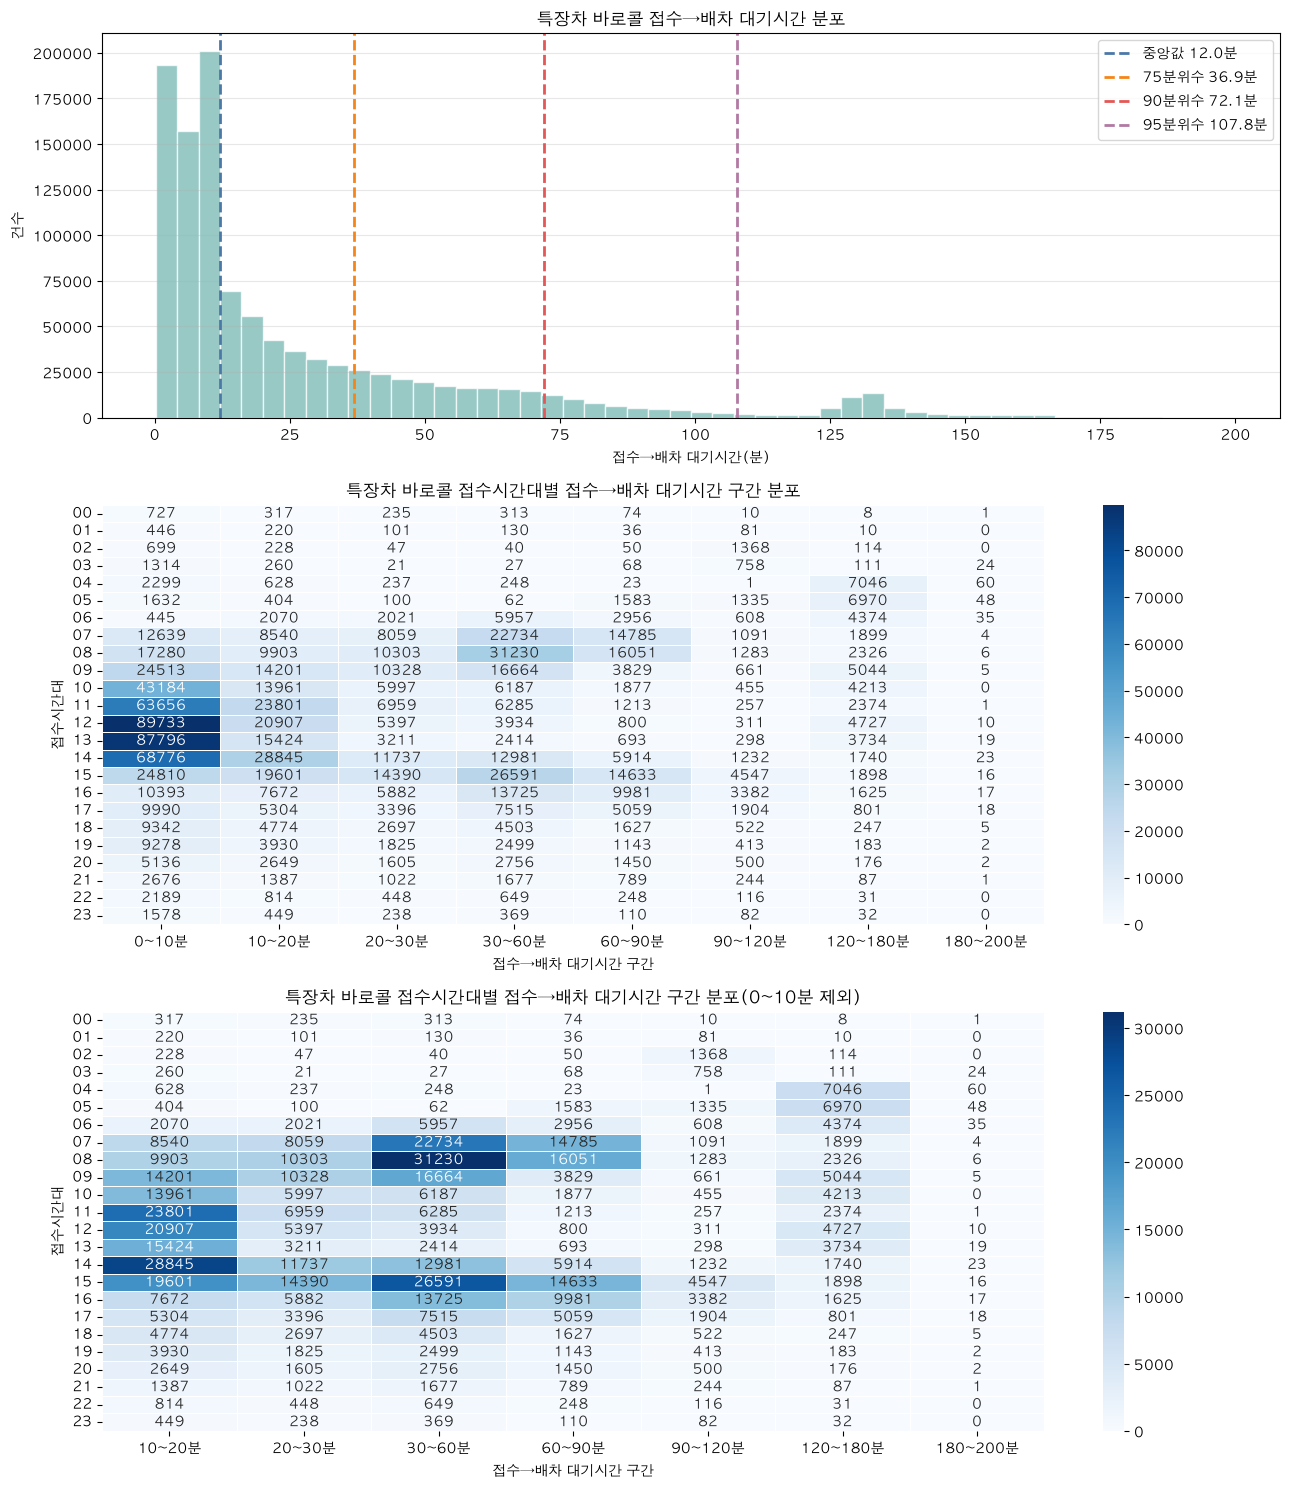

In [28]:
# 코드 셀 목적: 특장차 바로콜 후보의 접수→배차 대기시간 전체 분포와 시간대별 구간 분포를 시각화한다.

baro_data = special_ride_baro_call.copy()

baro_data["접수일시"] = pd.to_datetime(baro_data["접수일시"], errors="coerce")
baro_data["접수시간대_HH"] = baro_data["접수일시"].dt.strftime("%H")
baro_data["접수_배차_분"] = pd.to_numeric(baro_data["접수_배차_분"], errors="coerce")

baro_data = baro_data.dropna(subset=["접수시간대_HH", "접수_배차_분"]).copy()
baro_data = baro_data[
    (baro_data["접수_배차_분"] >= 0)
    & (baro_data["접수_배차_분"] <= 200)
].copy()

quantiles = {
    "중앙값": baro_data["접수_배차_분"].quantile(0.50),
    "75분위수": baro_data["접수_배차_분"].quantile(0.75),
    "90분위수": baro_data["접수_배차_분"].quantile(0.90),
    "95분위수": baro_data["접수_배차_분"].quantile(0.95),
}

wait_bins = [0, 10, 20, 30, 60, 90, 120, 180, 200]
wait_labels = [
    "0~10분",
    "10~20분",
    "20~30분",
    "30~60분",
    "60~90분",
    "90~120분",
    "120~180분",
    "180~200분",
]

baro_data["접수_배차_구간"] = pd.cut(
    baro_data["접수_배차_분"],
    bins=wait_bins,
    labels=wait_labels,
    right=True,
    include_lowest=True,
)

heatmap_data = (
    baro_data
    .pivot_table(
        index="접수시간대_HH",
        columns="접수_배차_구간",
        values="접수_배차_분",
        aggfunc="count",
        observed=False,
    )
    .reindex(columns=wait_labels)
    .fillna(0)
)

heatmap_data_without_short_wait = (
    baro_data[baro_data["접수_배차_구간"].ne("0~10분")]
    .pivot_table(
        index="접수시간대_HH",
        columns="접수_배차_구간",
        values="접수_배차_분",
        aggfunc="count",
        observed=False,
    )
    .reindex(columns=wait_labels[1:])
    .fillna(0)
)

fig = plt.figure(figsize=(13, 15))
gs = fig.add_gridspec(3, 1, height_ratios=[1.1, 1.2, 1.2])
ax_hist = fig.add_subplot(gs[0, 0])
ax_heat_all = fig.add_subplot(gs[1, 0])
ax_heat_long = fig.add_subplot(gs[2, 0])

ax_hist.hist(
    baro_data["접수_배차_분"],
    bins=50,
    color="#76b7b2",
    alpha=0.75,
    edgecolor="white",
)

line_colors = {
    "중앙값": "#4c78a8",
    "75분위수": "#f58518",
    "90분위수": "#e45756",
    "95분위수": "#b279a2",
}

for label, value in quantiles.items():
    ax_hist.axvline(
        value,
        color=line_colors[label],
        linestyle="--",
        linewidth=2,
        label=f"{label} {value:.1f}분",
    )

ax_hist.set_title("특장차 바로콜 접수→배차 대기시간 분포")
ax_hist.set_xlabel("접수→배차 대기시간(분)")
ax_hist.set_ylabel("건수")
ax_hist.grid(axis="y", alpha=0.3)
ax_hist.legend()

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax_heat_all,
)
ax_heat_all.set_title("특장차 바로콜 접수시간대별 접수→배차 대기시간 구간 분포")
ax_heat_all.set_xlabel("접수→배차 대기시간 구간")
ax_heat_all.set_ylabel("접수시간대")

sns.heatmap(
    heatmap_data_without_short_wait,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax_heat_long,
)
ax_heat_long.set_title("특장차 바로콜 접수시간대별 접수→배차 대기시간 구간 분포(0~10분 제외)")
ax_heat_long.set_xlabel("접수→배차 대기시간 구간")
ax_heat_long.set_ylabel("접수시간대")

plt.tight_layout()
plt.show()


,접수시간대_HH,승차완료건수,접수_승차_중앙값,접수_승차_90분위수
0,00,1685,39.600500,75.003963
1,01,1024,39.381117,106.820100
2,02,2546,119.057758,140.874892
3,03,2583,36.779667,138.895287
4,04,10542,152.726200,184.428728
5,05,12134,146.668533,174.286215
6,06,18466,71.488633,160.573467
7,07,69751,56.374617,98.218717
8,08,88382,55.216083,95.187872
9,09,75245,39.315000,91.948830


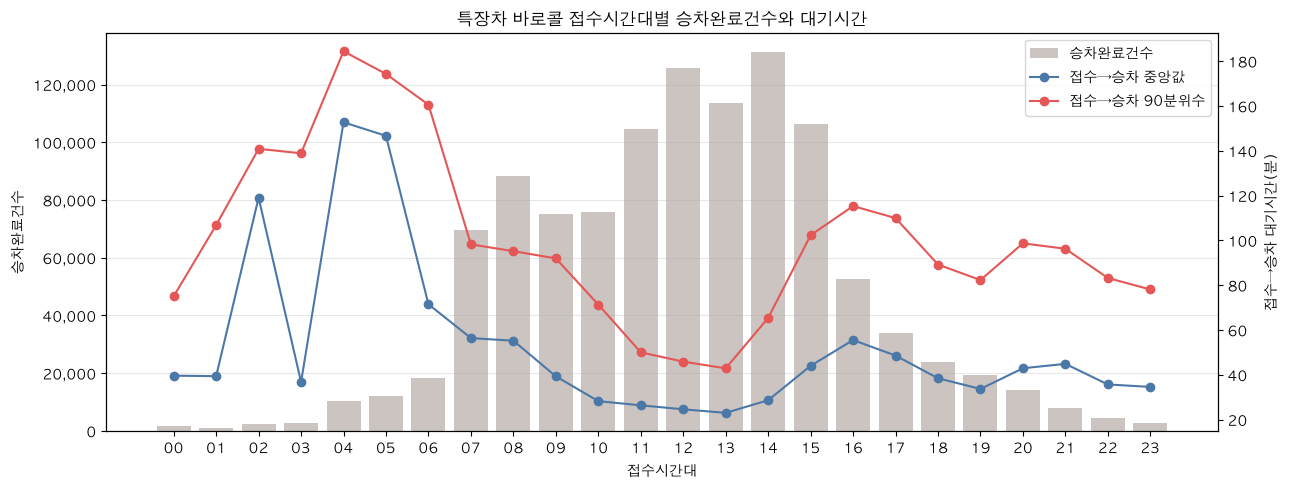

In [29]:
# 코드 셀 목적: 특장차 바로콜 후보의 접수시간대별 승차완료건수와 접수→승차 대기시간을 함께 확인한다.

from matplotlib.ticker import FuncFormatter

baro_hour_boarding = special_ride_baro_call.copy()

baro_hour_boarding["접수일시"] = pd.to_datetime(
    baro_hour_boarding["접수일시"],
    errors="coerce",
)
baro_hour_boarding["접수시간대_HH"] = (
    baro_hour_boarding["접수일시"]
    .dt.strftime("%H")
)

baro_hour_boarding["접수_승차_분"] = pd.to_numeric(
    baro_hour_boarding["접수_승차_분"],
    errors="coerce",
)

hour_order = [f"{hour:02d}" for hour in range(24)]

baro_hour_boarding_summary = (
    baro_hour_boarding
    .groupby("접수시간대_HH", observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reindex(hour_order)
    .reset_index()
)

display(baro_hour_boarding_summary)

fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.bar(
    baro_hour_boarding_summary["접수시간대_HH"],
    baro_hour_boarding_summary["승차완료건수"],
    color="#bab0ab",
    alpha=0.75,
    label="승차완료건수",
)
ax1.set_xlabel("접수시간대")
ax1.set_ylabel("승차완료건수")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax1.grid(axis="y", alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    baro_hour_boarding_summary["접수시간대_HH"],
    baro_hour_boarding_summary["접수_승차_중앙값"],
    marker="o",
    color="#4c78a8",
    label="접수→승차 중앙값",
)
ax2.plot(
    baro_hour_boarding_summary["접수시간대_HH"],
    baro_hour_boarding_summary["접수_승차_90분위수"],
    marker="o",
    color="#e45756",
    label="접수→승차 90분위수",
)
ax2.set_ylabel("접수→승차 대기시간(분)")

handles_1, labels_1 = ax1.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper right")

ax1.set_title("특장차 바로콜 접수시간대별 승차완료건수와 대기시간")

plt.tight_layout()
plt.show()

,접수요일,승차완료건수,접수_승차_중앙값,접수_승차_90분위수
0,월,187531,31.599500,94.913717
1,화,184885,33.281550,95.235033
2,수,190139,33.838833,98.865750
3,목,180334,32.411692,95.083698
4,금,183115,33.597617,100.781393
5,토,91178,36.286525,88.380100
6,일,81902,34.755083,84.340600


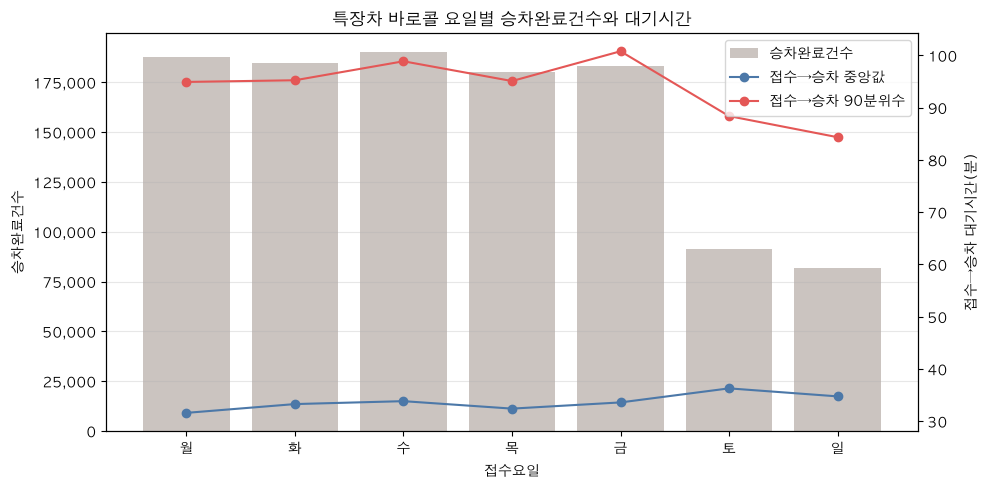

In [30]:
# 코드 셀 목적: 특장차 바로콜 후보의 요일별 승차완료건수와 접수→승차 대기시간을 함께 확인한다.

from matplotlib.ticker import FuncFormatter

baro_weekday_boarding = special_ride_baro_call.copy()

baro_weekday_boarding["접수일시"] = pd.to_datetime(
    baro_weekday_boarding["접수일시"],
    errors="coerce",
)

baro_weekday_boarding["접수요일"] = pd.Categorical(
    baro_weekday_boarding["접수일시"].dt.day_name().map({
        "Monday": "월",
        "Tuesday": "화",
        "Wednesday": "수",
        "Thursday": "목",
        "Friday": "금",
        "Saturday": "토",
        "Sunday": "일",
    }),
    categories=["월", "화", "수", "목", "금", "토", "일"],
    ordered=True,
)

baro_weekday_boarding["접수_승차_분"] = pd.to_numeric(
    baro_weekday_boarding["접수_승차_분"],
    errors="coerce",
)

baro_weekday_boarding_summary = (
    baro_weekday_boarding
    .groupby("접수요일", observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(baro_weekday_boarding_summary)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(
    baro_weekday_boarding_summary["접수요일"].astype(str),
    baro_weekday_boarding_summary["승차완료건수"],
    color="#bab0ab",
    alpha=0.75,
    label="승차완료건수",
)
ax1.set_xlabel("접수요일")
ax1.set_ylabel("승차완료건수")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax1.grid(axis="y", alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    baro_weekday_boarding_summary["접수요일"].astype(str),
    baro_weekday_boarding_summary["접수_승차_중앙값"],
    marker="o",
    color="#4c78a8",
    label="접수→승차 중앙값",
)
ax2.plot(
    baro_weekday_boarding_summary["접수요일"].astype(str),
    baro_weekday_boarding_summary["접수_승차_90분위수"],
    marker="o",
    color="#e45756",
    label="접수→승차 90분위수",
)
ax2.set_ylabel("접수→승차 대기시간(분)")

handles_1, labels_1 = ax1.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper right")

ax1.set_title("특장차 바로콜 요일별 승차완료건수와 대기시간")

plt.tight_layout()
plt.show()

## 4. 전일접수 후보 대기시간 분석

전일접수 후보는 접수 시점과 실제 탑승 예정시각 사이에 하루 정도의 간격이 있으므로, `접수→배차`나 `접수→승차`를 일반적인 대기시간으로 해석하면 안 된다.

전일접수에서 `예정일시`는 탑승예정시간에 가깝게 해석한다. 따라서 배차가 예정시각보다 얼마나 먼저 잡혔는지를 보려면 `배차일시 - 예정일시`가 아니라 `예정일시 - 배차일시` 방향으로 계산하는 것이 더 직관적이다.

분석 지표는 다음처럼 구분한다.

```text
배차여유_분 = 예정일시 - 배차일시
승차지연_분 = 승차일시 - 예정일시
배차_승차_분 = 승차일시 - 배차일시
```

해석 기준은 다음과 같다.

```text
배차여유_분 > 0  → 예정시각보다 먼저 배차됨
배차여유_분 = 0  → 예정시각에 배차됨
배차여유_분 < 0  → 예정시각보다 늦게 배차됨

승차지연_분 > 0  → 예정시각보다 늦게 승차함
승차지연_분 = 0  → 예정시각에 승차함
승차지연_분 < 0  → 예정시각보다 먼저 승차함
```

```text
배차여유_분이 크다 → 차량이 예정시각보다 충분히 먼저 배차됨
배차여유_분이 0에 가깝다 → 예정시각 근처에 배차됨
배차여유_분이 음수다 → 예정시각 이후에 배차됨, 배차 지연 가능성
승차지연_분이 크다 → 예정시각보다 실제 승차가 늦어짐
배차_승차_분이 크다 → 배차 후 차량 접근 또는 승차 완료까지 시간이 오래 걸림.
```


,구간,건수,평균,중앙값,75분위수,90분위수,95분위수,최소값,최대값
0,배차여유,48931,-5.523625,-6.026617,-2.555967,1.566550,5.092858,-99.394050,1428.131950
1,승차지연,48931,24.833721,23.808383,30.302367,37.202617,42.238475,-1409.625783,122.631883
2,배차→승차,48931,19.310096,18.457550,23.792750,29.163450,32.869833,0.000000,121.619333


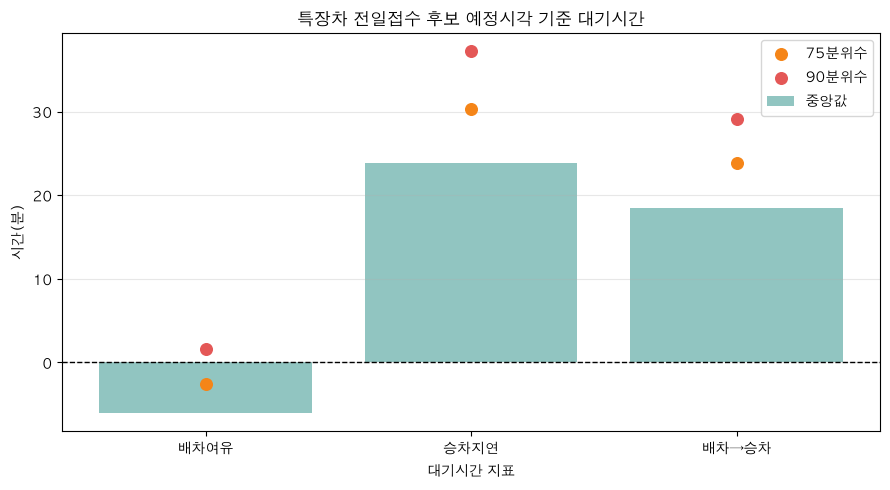

In [31]:
# 코드 셀 목적: 전일접수 후보의 예정시각 기준 배차여유·승차지연·배차후 승차시간을 확인한다.

previous_day_data = special_ride_previous_day.copy()

previous_day_data["예정일시"] = pd.to_datetime(previous_day_data["예정일시"], errors="coerce")
previous_day_data["배차일시"] = pd.to_datetime(previous_day_data["배차일시"], errors="coerce")
previous_day_data["승차일시"] = pd.to_datetime(previous_day_data["승차일시"], errors="coerce")
previous_day_data["배차_승차_분"] = pd.to_numeric(
    previous_day_data["배차_승차_분"],
    errors="coerce",
)

previous_day_data["배차여유_분"] = (
    previous_day_data["예정일시"] - previous_day_data["배차일시"]
).dt.total_seconds() / 60

previous_day_data["승차지연_분"] = (
    previous_day_data["승차일시"] - previous_day_data["예정일시"]
).dt.total_seconds() / 60

previous_day_wait_cols = ["배차여유_분", "승차지연_분", "배차_승차_분"]
previous_day_wait_labels = {
    "배차여유_분": "배차여유",
    "승차지연_분": "승차지연",
    "배차_승차_분": "배차→승차",
}

previous_day_wait_summary = []

for col in previous_day_wait_cols:
    values = previous_day_data[col].dropna()
    previous_day_wait_summary.append({
        "구간": previous_day_wait_labels[col],
        "건수": values.count(),
        "평균": values.mean(),
        "중앙값": values.median(),
        "75분위수": values.quantile(0.75),
        "90분위수": values.quantile(0.90),
        "95분위수": values.quantile(0.95),
        "최소값": values.min(),
        "최대값": values.max(),
    })

previous_day_wait_summary = pd.DataFrame(previous_day_wait_summary)
display(previous_day_wait_summary)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(previous_day_wait_summary))

ax.bar(
    x,
    previous_day_wait_summary["중앙값"],
    color="#76b7b2",
    alpha=0.8,
    label="중앙값",
)

ax.scatter(
    x,
    previous_day_wait_summary["75분위수"],
    color="#f58518",
    s=70,
    label="75분위수",
    zorder=3,
)

ax.scatter(
    x,
    previous_day_wait_summary["90분위수"],
    color="#e45756",
    s=70,
    label="90분위수",
    zorder=3,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("특장차 전일접수 후보 예정시각 기준 대기시간")
ax.set_xlabel("대기시간 지표")
ax.set_ylabel("시간(분)")
ax.set_xticks(list(x))
ax.set_xticklabels(previous_day_wait_summary["구간"])
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

1. `배차여유` 중앙값이 음수
   - `배차여유_분 = 예정일시 - 배차일시` => 음수는 예정시각보다 늦게 배차됐다는 뜻
   - 중앙값이 약 `-6분` => 전일접수 후보의 절반 정도는 예정시각보다 약 6분 이상 늦게 배차됨
   - 다만 90분위수는 양수 => 일부 건은 예정시각보다 미리 배차됨

2. `승차지연` 중앙값은 약 24분
   - `승차지연_분 = 승차일시 - 예정일시` => 실제 승차는 예정시각보다 보통 20분 늦게 이루어짐
   - 90분위수는 약 37분 => 상위 10%는 예정시각보다 35분 이상 늦게 승차

3. `배차→승차` 중앙값은 약 18분
   - 배차 후 실제 승차까지도 일정 시간이 걸림
   - `승차지연`의 상당 부분은 배차 이후 차량 접근 및 승차 완료 과정에서 발생하는 것으로 해석 가능

전일접수 후보의 예정시각 기준 대기시간을 보면, `배차여유` 중앙값은 음수로 나타나 예정시각보다 배차가 다소 늦게 이루어지는 경향이 있다. 다만 지연 폭은 중앙값 기준 약 6분 수준으로 크지는 않다.

반면 `승차지연` 중앙값은 약 24분, 90분위수는 약 37분으로 나타나 실제 승차는 예정시각보다 20~30분가량 늦어지는 경우가 많다. `배차→승차` 중앙값도 약 18분으로 나타나, 전일접수 후보의 체감 대기시간은 배차 자체의 지연뿐 아니라 배차 이후 차량 접근 및 승차 완료 과정에서 주로 발생하는 것으로 해석된다.

## 4-1. 전일접수 후보 예정 기준 대기시간 분포

전일접수 후보는 접수시각보다 탑승예정시간인 `예정일시`를 기준으로 실제 지연을 해석한다.

`예정대비_배차_분`과 `예정대비_승차_분`은 각각 `배차일시 - 예정일시`, `승차일시 - 예정일시`로 계산한다. 양수는 예정시각보다 늦은 배차/승차, 음수는 예정시각보다 이른 배차/승차를 의미한다.


,대기시간구간,건수,평균,중앙값,p75,p90,p95,최소값,최대값
0,배차_승차_분,48931,19.310096,18.457550,23.792750,29.16345,32.869833,0.000000,121.619333
1,배차여유_분,48897,-5.540977,-6.021883,-2.554000,1.56687,5.092773,-59.942283,25.785167
2,승차지연_분,48929,24.892240,23.808617,30.302783,37.20267,42.238980,-8.009550,122.631883


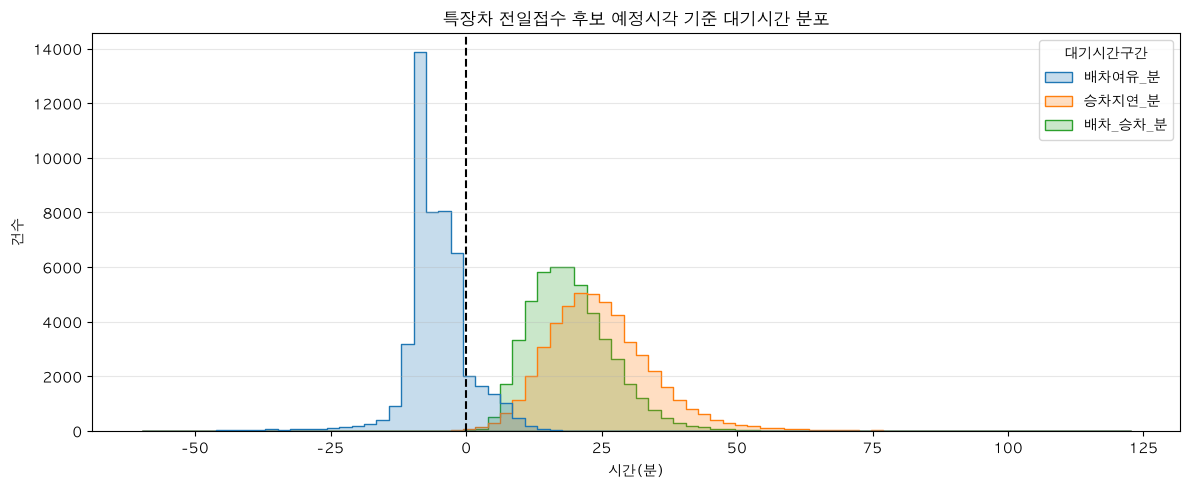

In [32]:
# 코드 셀 목적: 특장차 전일접수 후보의 예정시각 기준 배차여유·승차지연·배차후 승차시간 분포를 히스토그램으로 시각화한다.

previous_day_data = special_ride_previous_day.copy()

previous_day_data["예정일시"] = pd.to_datetime(previous_day_data["예정일시"], errors="coerce")
previous_day_data["배차일시"] = pd.to_datetime(previous_day_data["배차일시"], errors="coerce")
previous_day_data["승차일시"] = pd.to_datetime(previous_day_data["승차일시"], errors="coerce")
previous_day_data["배차_승차_분"] = pd.to_numeric(
    previous_day_data["배차_승차_분"],
    errors="coerce",
)

previous_day_data["배차여유_분"] = (
    previous_day_data["예정일시"] - previous_day_data["배차일시"]
).dt.total_seconds() / 60

previous_day_data["승차지연_분"] = (
    previous_day_data["승차일시"] - previous_day_data["예정일시"]
).dt.total_seconds() / 60

previous_day_wait_long = (
    previous_day_data[["배차여유_분", "승차지연_분", "배차_승차_분"]]
    .melt(var_name="대기시간구간", value_name="대기시간(분)")
    .dropna()
)

previous_day_wait_long = previous_day_wait_long[
    previous_day_wait_long["대기시간(분)"].between(-60, 180)
].copy()

summary = (
    previous_day_wait_long
    .groupby("대기시간구간", observed=False)
    .agg(
        건수=("대기시간(분)", "count"),
        평균=("대기시간(분)", "mean"),
        중앙값=("대기시간(분)", "median"),
        p75=("대기시간(분)", lambda x: x.quantile(0.75)),
        p90=("대기시간(분)", lambda x: x.quantile(0.90)),
        p95=("대기시간(분)", lambda x: x.quantile(0.95)),
        최소값=("대기시간(분)", "min"),
        최대값=("대기시간(분)", "max"),
    )
    .reset_index()
)

display(summary)

fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    data=previous_day_wait_long,
    x="대기시간(분)",
    hue="대기시간구간",
    bins=80,
    element="step",
    stat="count",
    common_norm=False,
    ax=ax,
)

ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="예정시각")
ax.set_title("특장차 전일접수 후보 예정시각 기준 대기시간 분포")
ax.set_xlabel("시간(분)")
ax.set_ylabel("건수")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

1. 파란색 `배차여유_분`은 대부분 `-10~0분` 근처에 몰려 있음
   - `배차여유_분 = 예정일시 - 배차일시`이므로 => 음수는 예정시각보다 늦게 배차됨을 의미
   - 전일접수는 차량이 예정시각보다 넉넉히 먼저 배차되기보다는 예정시각 직전~직후에 배차되는 경우가 많음
   - 특히 분포 중심이 0보다 왼쪽 => 조기 배차보다는 예정시각 약간 이후 배차가 더 일반적인 것으로 해석

2. 초록색 `배차_승차_분`은 `10~25분` 사이에 가장 많이 분포
   - 배차 후 실제 승차까지 차량 접근 또는 탑승 완료 시간이 붙는 구조

3. 주황색 `승차지연_분`은 `15~30분` 부근에 몰려 있음
   - `승차지연_분 = 승차일시 - 예정일시` => 실제 승차는 예정시각보다 보통 20분 전후 늦게 이루어지는 것으로 볼 수 있음
   - 이 값은 `배차여유_분`이 음수인 점과 `배차→승차` 시간이 더해져 만들어진 결과로 해석됨

전일접수 후보의 예정시각 기준 대기시간 분포를 보면, `배차여유_분`은 -10~0분 구간에 집중되어 있어 차량이 예정시각보다 미리 배차되기보다는 예정시각 직전 또는 직후에 배차되는 경향이 나타났다. 특히 분포 중심이 0보다 왼쪽에 있어, 예정시각 이후 배차되는 사례가 더 일반적인 것으로 보인다.

반면 `배차_승차_분`은 10~25분 구간에 집중되어 있으며, 이에 따라 `승차지연_분`은 15~30분 구간에 주로 분포한다. 이는 전일접수 후보의 실제 승차 지연이 예정시각 이후 배차와 배차 후 차량 접근 시간이 결합되어 발생함을 시사한다.

## 4-2. 전일접수 후보 예정시간대별 대기시간 구간 히트맵

전일접수 후보의 예정시간대별 대기시간 구간 분포를 히트맵으로 확인한다.

숫자는 해당 예정시간대와 대기시간 구간에 들어간 탑승완료 건수다. `예정대비_배차_분`, `예정대비_승차_분`, `배차_승차_분`을 나누어 보면 지연이 예정시각 대비 배차 단계에서 생기는지, 배차 이후 승차 단계에서 생기는지 구분할 수 있다.


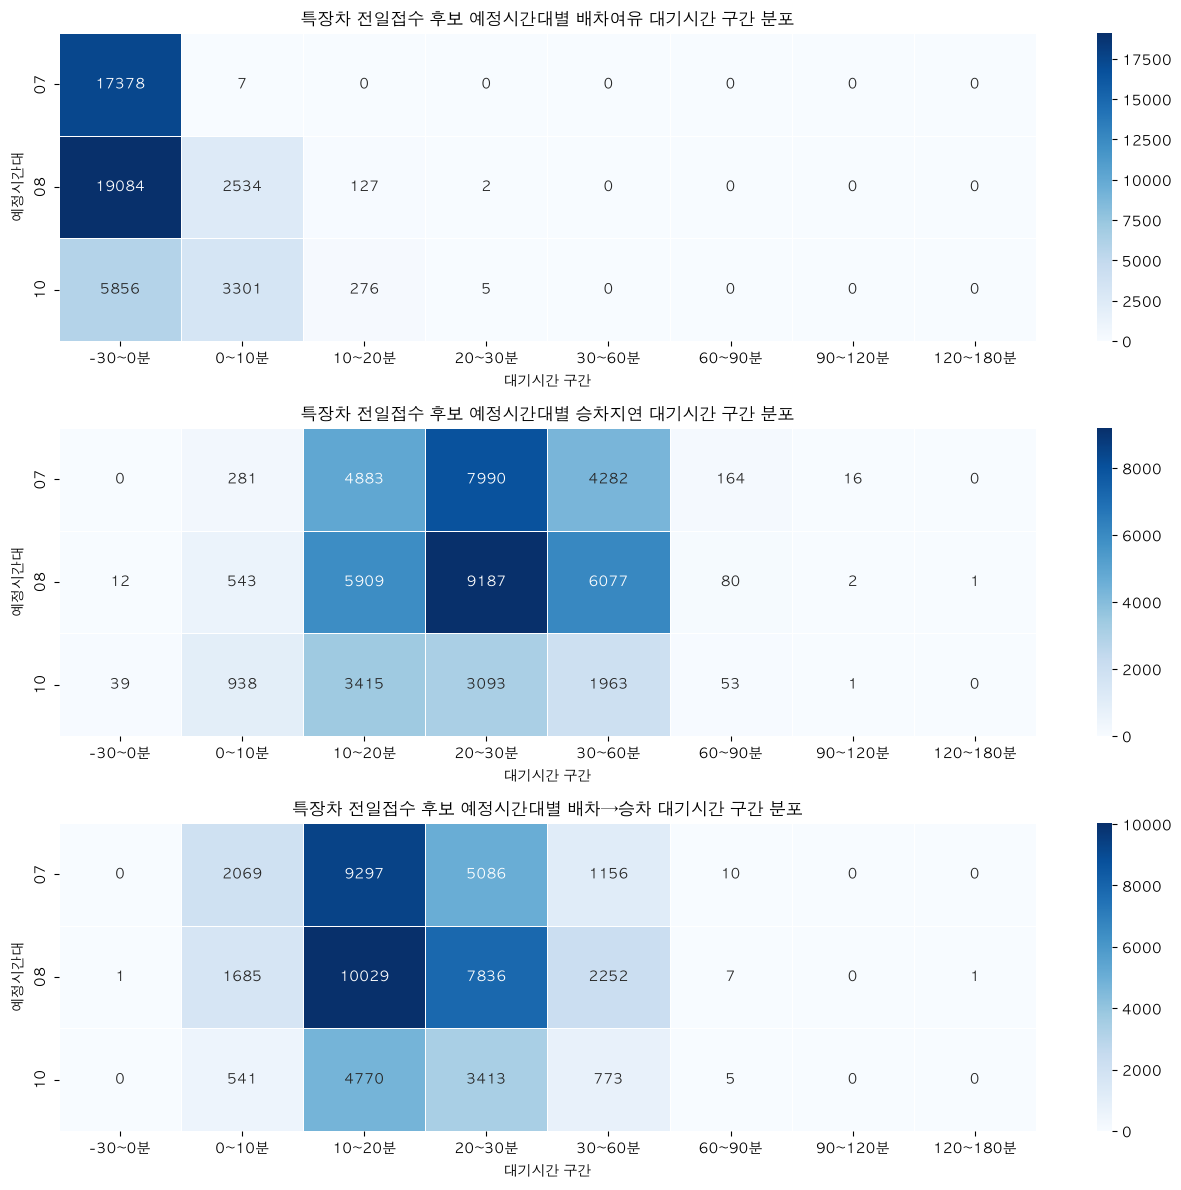

In [33]:
# 코드 셀 목적: 특장차 전일접수 후보의 예정시간대별 배차여유·승차지연·배차후 승차시간 구간 분포를 히트맵으로 시각화한다.

previous_day_heatmap_data = previous_day_data.copy()

previous_day_heatmap_data["예정일시"] = pd.to_datetime(
    previous_day_heatmap_data["예정일시"],
    errors="coerce",
)
previous_day_heatmap_data["예정시간대_HH"] = (
    previous_day_heatmap_data["예정일시"].dt.strftime("%H")
)

previous_day_heatmap_data["배차여유_분"] = pd.to_numeric(
    previous_day_heatmap_data["배차여유_분"],
    errors="coerce",
)
previous_day_heatmap_data["승차지연_분"] = pd.to_numeric(
    previous_day_heatmap_data["승차지연_분"],
    errors="coerce",
)
previous_day_heatmap_data["배차_승차_분"] = pd.to_numeric(
    previous_day_heatmap_data["배차_승차_분"],
    errors="coerce",
)

wait_bins = [-30, 0, 10, 20, 30, 60, 90, 120, 180]
wait_labels = [
    "-30~0분",
    "0~10분",
    "10~20분",
    "20~30분",
    "30~60분",
    "60~90분",
    "90~120분",
    "120~180분",
]

heatmap_specs = [
    ("배차여유_분", "배차여유"),
    ("승차지연_분", "승차지연"),
    ("배차_승차_분", "배차→승차"),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

for ax, (col, title) in zip(axes, heatmap_specs):
    plot_data = previous_day_heatmap_data.dropna(
        subset=["예정시간대_HH", col]
    ).copy()

    plot_data["대기시간구간"] = pd.cut(
        plot_data[col],
        bins=wait_bins,
        labels=wait_labels,
        right=True,
        include_lowest=True,
    )

    heatmap_data = (
        plot_data
        .dropna(subset=["대기시간구간"])
        .pivot_table(
            index="예정시간대_HH",
            columns="대기시간구간",
            values=col,
            aggfunc="count",
            observed=False,
        )
        .reindex(columns=wait_labels)
        .fillna(0)
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        linewidths=0.5,
        ax=ax,
    )

    ax.set_title(f"특장차 전일접수 후보 예정시간대별 {title} 대기시간 구간 분포")
    ax.set_xlabel("대기시간 구간")
    ax.set_ylabel("예정시간대")

plt.tight_layout()
plt.show()

1. `배차여유`는 대부분 음수, 예정시각 이후 배차가 많음
   - 첫 번째 히트맵을 보면 `배차여유`는 `-30~0분` 구간에 가장 많이 몰려 있음
   - 전일접수 후보는 대부분 예정시각보다 `0~30분` 늦게 배차되는 구조. 특히 07시와 08시에 이 패턴이 강하게 나타남
   - 다만 08시와 10시는 `0~10분` 구간도 어느 정도 존재 => 예정시각보다 `0~10분` 먼저 배차된 건으로 해석

2. `승차지연`은 `20~30분` 구간이 중심
   - 두 번째 히트맵을 보면 `승차지연`은 대체로 `20~30분` 구간에 가장 많이 몰려 있음
   - 실제 승차는 예정시각보다 보통 `20~30분` 정도 늦어지는 경우가 많음. 10시는 07시·08시보다 약간 짧아서 `10~20분` 구간도 많이 나타남

3. `배차→승차`는 `10~20분` 또는 `20~30분` 구간이 중심
   - 세 번째 히트맵은 배차 이후 실제 승차까지 걸린 시간
   - 배차된 뒤 실제 승차까지는 대체로 `10~30분` 정도 걸리는 것으로 해석

## 5. 심야시간 사전예약 후보 분석

심야시간 사전예약 후보는 월별 분포와 시간대별 최대 3명 기준을 검증한다. 이 기준은 후보 제외 조건이 아니라 운영 기준과 데이터가 얼마나 맞는지 확인하는 지표다.


In [34]:
# 코드 셀 목적: 심야시간 사전예약 후보의 월별·시간대별 분포와 3명 기준 초과 여부를 확인한다.

night_data = special_ride_night_reservation.copy()

if "승차일시" not in night_data.columns:
    raise KeyError("승차일시 컬럼이 없습니다.")

night_data["승차일시"] = pd.to_datetime(night_data["승차일시"], errors="coerce")
night_data = night_data.dropna(subset=["승차일시"]).copy()

night_data["승차월"] = night_data["승차일시"].dt.to_period("M").astype(str)
night_data["승차일자"] = night_data["승차일시"].dt.normalize()
night_data["승차시간대"] = night_data["승차일시"].dt.strftime("%H:00:00")

night_month_summary = (
    night_data
    .groupby("승차월", observed=False)
    .size()
    .reset_index(name="심야시간사전예약_후보건수")
)

night_capacity_summary = (
    night_data
    .groupby(["승차일자", "승차시간대"], observed=False)
    .size()
    .reset_index(name="탑승완료건수")
)
night_capacity_summary["시간대별_3명초과여부"] = night_capacity_summary["탑승완료건수"].gt(3)

night_capacity_result = (
    night_capacity_summary
    .sort_values(["탑승완료건수", "승차일자", "승차시간대"], ascending=[False, True, True])
    .reset_index(drop=True)
)

print(f"심야시간 사전예약 후보 총 건수: {len(night_data):,}건")
print(f"시간대별 3명 초과 구간 수: {night_capacity_summary['시간대별_3명초과여부'].sum():,}개")
display(night_month_summary)
display(night_capacity_result.head(30))


심야시간 사전예약 후보 총 건수: 116건
시간대별 3명 초과 구간 수: 0개


,승차월,심야시간사전예약_후보건수
0,2025-05,5
1,2025-06,17
2,2025-07,19
3,2025-08,8
4,2025-09,24
5,2025-10,11
6,2025-11,9
7,2025-12,23


,승차일자,승차시간대,탑승완료건수,시간대별_3명초과여부
0,2025-06-03,04:00:00,2,False
1,2025-07-03,03:00:00,2,False
2,2025-11-16,03:00:00,2,False
3,2025-12-15,04:00:00,2,False
4,2025-05-09,03:00:00,1,False
5,2025-05-11,03:00:00,1,False
6,2025-05-16,04:00:00,1,False
7,2025-05-19,04:00:00,1,False
8,2025-05-21,01:00:00,1,False
9,2025-06-04,05:00:00,1,False


## 5-1. 심야시간 사전예약 후보 예정시각 기준 대기시간 분석

심야시간 사전예약 후보는 이용 전일에 미리 접수하는 예약성 접수이므로, `접수→배차`나 `접수→승차`를 일반적인 대기시간으로 해석하면 안 된다.

심야시간 사전예약에서도 `예정일시`는 탑승예정시간에 가깝게 해석한다. 따라서 배차가 예정시각보다 얼마나 먼저 잡혔는지를 보려면 `예정일시 - 배차일시` 방향으로 계산하는 것이 더 직관적이다.

분석 지표는 다음처럼 구분한다.

```text
배차여유_분 = 예정일시 - 배차일시
승차지연_분 = 승차일시 - 예정일시
배차_승차_분 = 승차일시 - 배차일시
```

각 지표의 의미는 다음과 같다.
```text
배차여유_분 > 0  → 예정시각보다 먼저 배차됨
배차여유_분 = 0  → 예정시각에 배차됨
배차여유_분 < 0  → 예정시각보다 늦게 배차됨

승차지연_분 > 0  → 예정시각보다 늦게 승차함
승차지연_분 = 0  → 예정시각에 승차함
승차지연_분 < 0  → 예정시각보다 먼저 승차함
```

,구간,건수,평균,중앙값,75분위수,90분위수,95분위수,최소값,최대값
0,배차여유,116,18.850311,18.798892,23.033071,27.826500,34.393637,-9.742783,51.106717
1,승차지연,116,7.296310,5.654950,12.669167,19.925083,28.593567,-23.191883,49.003167
2,배차→승차,116,26.146621,25.086892,31.199013,39.032008,44.601729,6.804383,58.680550


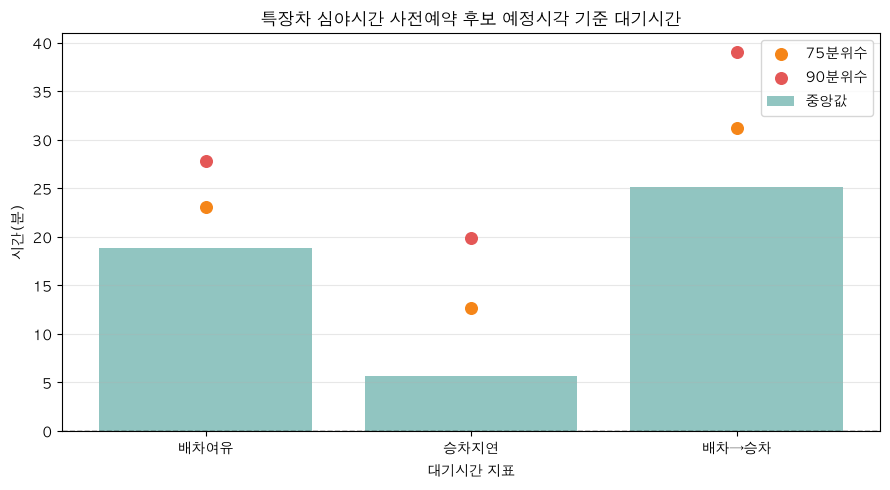

In [35]:
# 코드 셀 목적: 특장차 심야시간 사전예약 후보의 예정시각 기준 배차여유·승차지연·배차후 승차시간을 확인한다.

night_reservation_data = special_ride_night_reservation.copy()

night_reservation_data["예정일시"] = pd.to_datetime(
    night_reservation_data["예정일시"],
    errors="coerce",
)
night_reservation_data["배차일시"] = pd.to_datetime(
    night_reservation_data["배차일시"],
    errors="coerce",
)
night_reservation_data["승차일시"] = pd.to_datetime(
    night_reservation_data["승차일시"],
    errors="coerce",
)

night_reservation_data["배차_승차_분"] = pd.to_numeric(
    night_reservation_data["배차_승차_분"],
    errors="coerce",
)

night_reservation_data["배차여유_분"] = (
    night_reservation_data["예정일시"] - night_reservation_data["배차일시"]
).dt.total_seconds() / 60

night_reservation_data["승차지연_분"] = (
    night_reservation_data["승차일시"] - night_reservation_data["예정일시"]
).dt.total_seconds() / 60

night_wait_cols = ["배차여유_분", "승차지연_분", "배차_승차_분"]
night_wait_labels = {
    "배차여유_분": "배차여유",
    "승차지연_분": "승차지연",
    "배차_승차_분": "배차→승차",
}

night_wait_summary = []

for col in night_wait_cols:
    values = night_reservation_data[col].dropna()
    night_wait_summary.append({
        "구간": night_wait_labels[col],
        "건수": values.count(),
        "평균": values.mean(),
        "중앙값": values.median(),
        "75분위수": values.quantile(0.75),
        "90분위수": values.quantile(0.90),
        "95분위수": values.quantile(0.95),
        "최소값": values.min(),
        "최대값": values.max(),
    })

night_wait_summary = pd.DataFrame(night_wait_summary)
display(night_wait_summary)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(night_wait_summary))

ax.bar(
    x,
    night_wait_summary["중앙값"],
    color="#76b7b2",
    alpha=0.8,
    label="중앙값",
)

ax.scatter(
    x,
    night_wait_summary["75분위수"],
    color="#f58518",
    s=70,
    label="75분위수",
    zorder=3,
)

ax.scatter(
    x,
    night_wait_summary["90분위수"],
    color="#e45756",
    s=70,
    label="90분위수",
    zorder=3,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("특장차 심야시간 사전예약 후보 예정시각 기준 대기시간")
ax.set_xlabel("대기시간 지표")
ax.set_ylabel("시간(분)")
ax.set_xticks(list(x))
ax.set_xticklabels(night_wait_summary["구간"])
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

,대기시간구간,건수,평균,중앙값,p75,p90,p95,최소값,최대값
0,배차_승차_분,116,26.146621,25.086892,31.199013,39.032008,44.601729,6.804383,58.680550
1,배차여유_분,116,18.850311,18.798892,23.033071,27.826500,34.393637,-9.742783,51.106717
2,승차지연_분,116,7.296310,5.654950,12.669167,19.925083,28.593567,-23.191883,49.003167


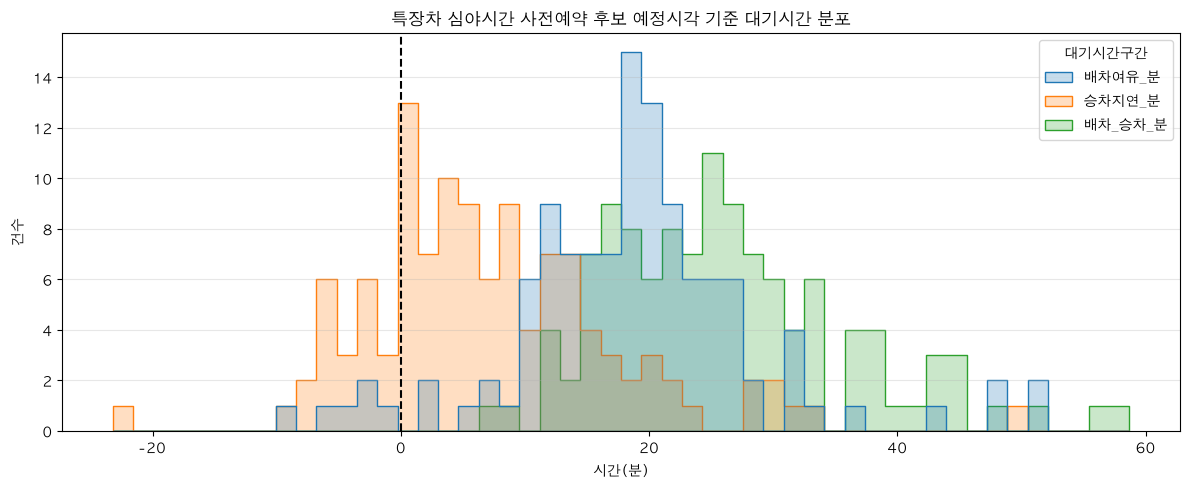

In [36]:
# 코드 셀 목적: 특장차 심야시간 사전예약 후보의 예정시각 기준 대기시간 분포를 히스토그램으로 시각화한다.

night_wait_long = (
    night_reservation_data[["배차여유_분", "승차지연_분", "배차_승차_분"]]
    .melt(var_name="대기시간구간", value_name="대기시간(분)")
    .dropna()
)

night_wait_long = night_wait_long[
    night_wait_long["대기시간(분)"].between(-60, 180)
].copy()

night_distribution_summary = (
    night_wait_long
    .groupby("대기시간구간", observed=False)
    .agg(
        건수=("대기시간(분)", "count"),
        평균=("대기시간(분)", "mean"),
        중앙값=("대기시간(분)", "median"),
        p75=("대기시간(분)", lambda x: x.quantile(0.75)),
        p90=("대기시간(분)", lambda x: x.quantile(0.90)),
        p95=("대기시간(분)", lambda x: x.quantile(0.95)),
        최소값=("대기시간(분)", "min"),
        최대값=("대기시간(분)", "max"),
    )
    .reset_index()
)

display(night_distribution_summary)

fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    data=night_wait_long,
    x="대기시간(분)",
    hue="대기시간구간",
    bins=50,
    element="step",
    stat="count",
    common_norm=False,
    ax=ax,
)

ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="예정시각")
ax.set_title("특장차 심야시간 사전예약 후보 예정시각 기준 대기시간 분포")
ax.set_xlabel("시간(분)")
ax.set_ylabel("건수")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

1. 파란색 `배차여유_분`은 주로 `15~25분` 근처에 몰려 있음
   - `배차여유_분 = 예정일시 - 배차일시` => 양수는 예정시각보다 먼저 배차됐다는 의미
   - 심야시간 사전예약 후보는 전일접수와 달리 예정시각보다 `15~25분` 정도 미리 배차되는 경우가 많아 보임

2. 주황색 `승차지연_분`은 `0~10분` 근처와 음수 구간에도 일부 분포
   - `승차지연_분 = 승차일시 - 예정일시` => 양수는 예정시각보다 늦게 승차, 음수는 예정시각보다 먼저 승차를 의미
   - 전반적으로 예정시각 직후 또는 그보다 이른 승차가 적지 않게 나타남
   - 심야시간 사전예약이 실제 탑승시각에 맞춰 비교적 미리 배차되고 이용자가 예정시각 전후로 탑승하는 구조일 가능성

3. 초록색 `배차→승차`는 `15~35분` 정도로 넓게 퍼져 있음
   - 배차 후 실제 승차까지 걸리는 시간이 전일접수보다 다소 길거나 변동성이 커 보암
   - 심야시간에는 차량 접근 거리, 운행 가능 차량 수, 심야 도로 및 대기 조건 등이 영향을 줄 수 있음

4. 해석 시 표본 수에 주의해야 함
   - 심야시간 사전예약 후보는 건수가 `116건`으로 작음
   - 따라서 이 그래프는 전일접수처럼 일반화하기보다는 후보군의 패턴을 확인하는 참고 지표로 해석하는 것이 안전

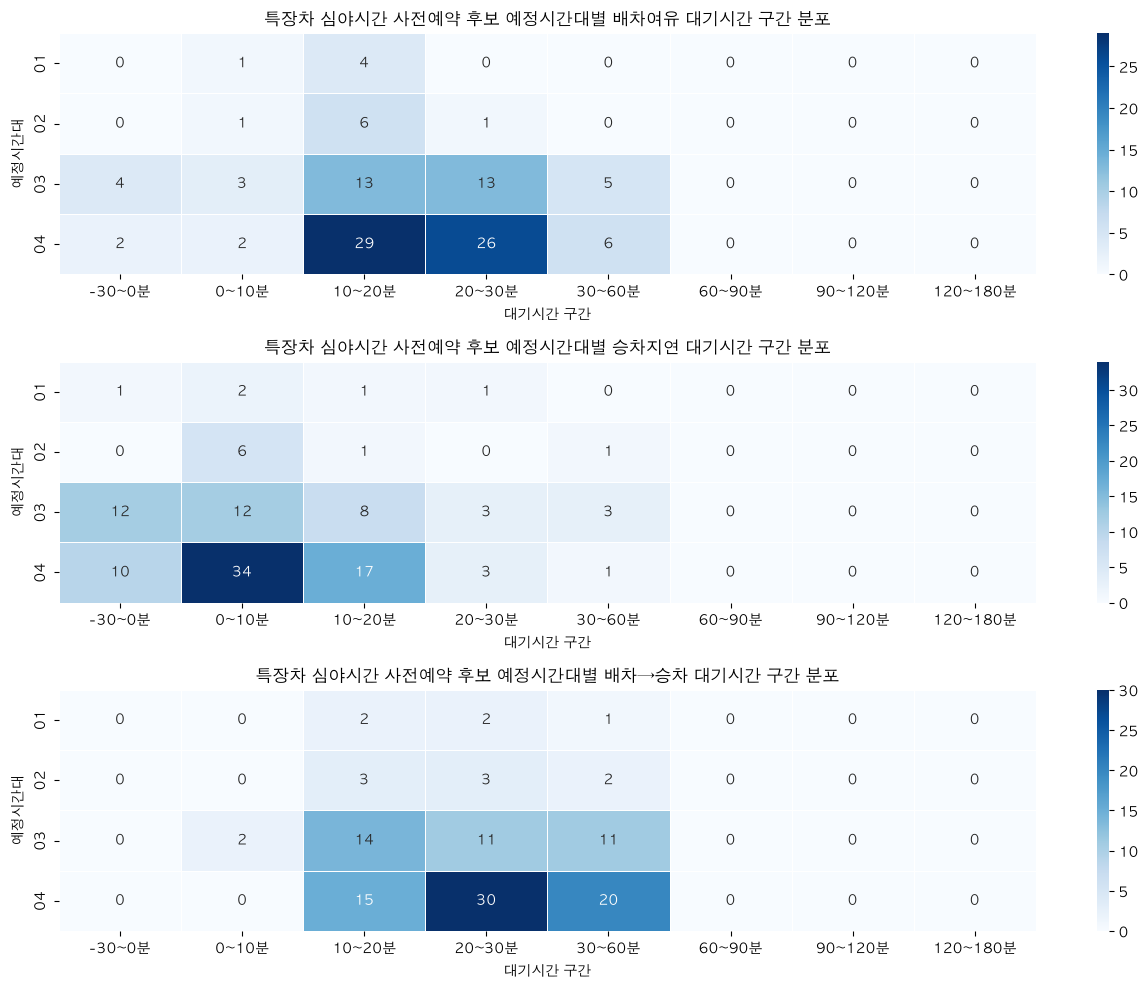

In [37]:
# 코드 셀 목적: 특장차 심야시간 사전예약 후보의 예정시간대별 배차여유·승차지연·배차후 승차시간 구간 분포를 히트맵으로 시각화한다.

night_heatmap_data = night_reservation_data.copy()

night_heatmap_data["예정일시"] = pd.to_datetime(
    night_heatmap_data["예정일시"],
    errors="coerce",
)
night_heatmap_data["예정시간대_HH"] = (
    night_heatmap_data["예정일시"].dt.strftime("%H")
)

night_heatmap_data["배차여유_분"] = pd.to_numeric(
    night_heatmap_data["배차여유_분"],
    errors="coerce",
)
night_heatmap_data["승차지연_분"] = pd.to_numeric(
    night_heatmap_data["승차지연_분"],
    errors="coerce",
)
night_heatmap_data["배차_승차_분"] = pd.to_numeric(
    night_heatmap_data["배차_승차_분"],
    errors="coerce",
)

wait_bins = [-30, 0, 10, 20, 30, 60, 90, 120, 180]
wait_labels = [
    "-30~0분",
    "0~10분",
    "10~20분",
    "20~30분",
    "30~60분",
    "60~90분",
    "90~120분",
    "120~180분",
]

heatmap_specs = [
    ("배차여유_분", "배차여유"),
    ("승차지연_분", "승차지연"),
    ("배차_승차_분", "배차→승차"),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 10))

for ax, (col, title) in zip(axes, heatmap_specs):
    plot_data = night_heatmap_data.dropna(
        subset=["예정시간대_HH", col]
    ).copy()

    plot_data["대기시간구간"] = pd.cut(
        plot_data[col],
        bins=wait_bins,
        labels=wait_labels,
        right=True,
        include_lowest=True,
    )

    heatmap_data = (
        plot_data
        .dropna(subset=["대기시간구간"])
        .pivot_table(
            index="예정시간대_HH",
            columns="대기시간구간",
            values=col,
            aggfunc="count",
            observed=False,
        )
        .reindex(columns=wait_labels)
        .fillna(0)
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        linewidths=0.5,
        ax=ax,
    )

    ax.set_title(f"특장차 심야시간 사전예약 후보 예정시간대별 {title} 대기시간 구간 분포")
    ax.set_xlabel("대기시간 구간")
    ax.set_ylabel("예정시간대")

plt.tight_layout()
plt.show()

핵심은 심야시간 사전예약 후보는 03~04시에 대부분 몰리고, 배차는 예정시각보다 10~30분 정도 미리 되는 경우가 많지만 실제 승차는 예정시각 전후 또는 10분 이내에 이루어지는 경우가 많다는 점

1. `배차여유`는 03시와 04시에 집중되어 있음
   - 첫 번째 `배차여유` 히트맵을 보면 03시와 04시에 건수가 집중됨
   - 심야시간 사전예약은 대체로 예정시각보다 `10~30분` 전에 배차되는 경우가 많음

2. `승차지연`은 예정시각 전후 또는 10분 이내에 많이 분포
   - 두 번째 `승차지연` 히트맵을 보면 04시는 `0~10분`이 34건으로 가장 많음.
   - 실제 승차는 예정시각보다 조금 빠르거나 예정시각 이후 `10분 이내`에 이루어지는 경우가 많음
   - 전일접수처럼 `20~30분` 지연이 중심인 구조와는 다른 패턴

3. `배차→승차`는 10~60분 구간에 분산되어 있음
   - 세 번째 `배차→승차` 히트맵을 보면 03시는 `10~20분`, `20~30분`, `30~60분` 구간에 분산되어 있음
   - 배차 자체는 미리 이루어지지만 배차 후 실제 승차까지는 `20~60분`까지 퍼져 있음
   - 심야시간 특성상 차량이 미리 배정되어도 실제 탑승까지 대기 또는 접근 시간이 존재한다는 의미로 볼 수 있음

## 6. 취소 접수유형 후보별 규모

취소 건은 `승차일시`가 없으므로 탑승완료 건과 같은 방식으로 대기시간을 해석하면 안 된다. 그래서 `취소_접수유형_후보`를 기준으로 바로콜, 전일접수, 심야시간 사전예약, 기타 예약성/미분류를 나누어 본다.

분석 기준은 다음과 같다.

```text
바로콜 취소 후보: 접수 후 즉시 이용 구조이므로 접수→취소를 핵심 지표로 사용
전일접수 취소 후보: 예약성 접수이므로 예정일시 대비 취소 시점을 핵심 지표로 사용
심야시간 사전예약 취소 후보: 예약성 접수이므로 예정일시 대비 취소 시점을 핵심 지표로 사용
기타 예약성/미분류 취소 후보: 위 기준으로 설명되지 않는 취소 건을 별도 확인
```

정기접수는 고객 식별자가 없어 취소 분석에서도 확정 접수유형으로 분류하지 않는다.

취소 접수유형 후보 분류 검증


,검증항목,값
0,취소 전체 건수,"228,987"
1,취소_접수유형_후보 분류 건수,"228,987"
2,취소_접수유형_후보 합계 일치 여부,True


취소 접수유형 후보별 건수


,취소_접수유형_후보,취소건수,비율(%)
0,바로콜 취소 후보,219645,95.920292
1,전일접수 취소 후보,5938,2.593160
2,심야시간 사전예약 취소 후보,39,0.017032
3,기타 예약성/미분류 취소 후보,3365,1.469516


취소 접수유형 후보별 대기시간 유효건수


,취소_접수유형_후보,취소건수,접수_취소_유효건수,배차_취소_유효건수,배차후취소건수,배차후취소비율(%)
0,바로콜 취소 후보,219645,219645,50126,50126,22.82
1,전일접수 취소 후보,5938,5938,712,712,11.99
2,심야시간 사전예약 취소 후보,39,39,5,5,12.82
3,기타 예약성/미분류 취소 후보,3365,3365,618,618,18.37


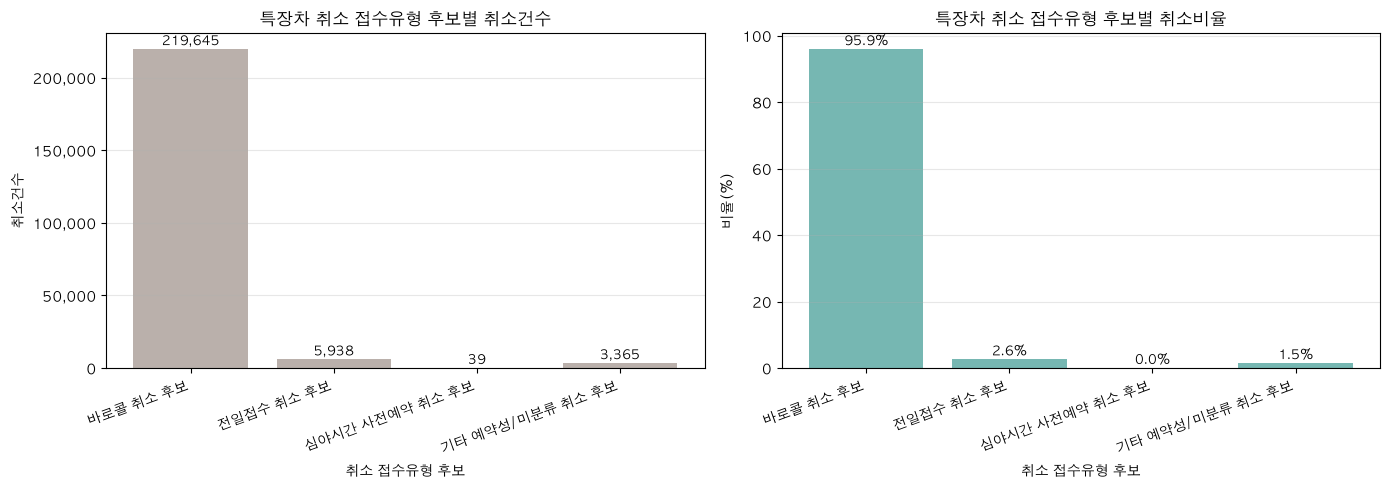

In [38]:
# 코드 셀 목적: 특장차 취소 건을 접수유형 후보별로 분리하고 규모를 확인한다.
from matplotlib.ticker import FuncFormatter

cancel_type_col = "취소_접수유형_후보"
if cancel_type_col not in df_special.columns:
    raise KeyError("취소_접수유형_후보 컬럼이 없습니다. 03번 노트북의 ## 6-1 셀과 최종 저장 셀을 먼저 실행해 주세요.")

special_cancel = df_special[df_special["취소일시"].notna()].copy()
special_cancel["접수_취소_분"] = pd.to_numeric(special_cancel["접수_취소_분"], errors="coerce")
special_cancel["배차_취소_분"] = pd.to_numeric(special_cancel["배차_취소_분"], errors="coerce")

cancel_type_order = [
    "바로콜 취소 후보",
    "전일접수 취소 후보",
    "심야시간 사전예약 취소 후보",
    "기타 예약성/미분류 취소 후보",
]

special_cancel_baro_call = special_cancel[special_cancel[cancel_type_col].eq("바로콜 취소 후보")].copy()
special_cancel_previous_day = special_cancel[special_cancel[cancel_type_col].eq("전일접수 취소 후보")].copy()
special_cancel_night_reservation = special_cancel[special_cancel[cancel_type_col].eq("심야시간 사전예약 취소 후보")].copy()
special_cancel_other = special_cancel[special_cancel[cancel_type_col].eq("기타 예약성/미분류 취소 후보")].copy()

cancel_type_summary = (
    special_cancel[cancel_type_col]
    .value_counts(dropna=False)
    .reindex(cancel_type_order, fill_value=0)
    .rename_axis("취소_접수유형_후보")
    .reset_index(name="취소건수")
)
cancel_type_summary["비율(%)"] = cancel_type_summary["취소건수"] / len(special_cancel) * 100

cancel_validation_summary = pd.DataFrame({
    "검증항목": ["취소 전체 건수", "취소_접수유형_후보 분류 건수", "취소_접수유형_후보 합계 일치 여부"],
    "값": [
        f"{len(special_cancel):,}",
        f"{special_cancel[cancel_type_col].ne('취소 아님').sum():,}",
        len(special_cancel) == special_cancel[cancel_type_col].ne("취소 아님").sum(),
    ],
})

cancel_wait_valid_summary = (
    special_cancel
    .groupby(cancel_type_col, observed=False)
    .agg(
        취소건수=("취소일시", "count"),
        접수_취소_유효건수=("접수_취소_분", lambda x: x.notna().sum()),
        배차_취소_유효건수=("배차_취소_분", lambda x: x.notna().sum()),
        배차후취소건수=("배차일시", lambda x: x.notna().sum()),
    )
    .reindex(cancel_type_order)
    .reset_index()
)
cancel_wait_valid_summary["배차후취소비율(%)"] = (
    cancel_wait_valid_summary["배차후취소건수"] / cancel_wait_valid_summary["취소건수"] * 100
).round(2)

print("취소 접수유형 후보 분류 검증")
display(cancel_validation_summary)
print("취소 접수유형 후보별 건수")
display(cancel_type_summary)
print("취소 접수유형 후보별 대기시간 유효건수")
display(cancel_wait_valid_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(cancel_type_summary))

axes[0].bar(x, cancel_type_summary["취소건수"], color="#bab0ab")
axes[0].set_title("특장차 취소 접수유형 후보별 취소건수")
axes[0].set_xlabel("취소 접수유형 후보")
axes[0].set_ylabel("취소건수")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(cancel_type_summary["취소_접수유형_후보"], rotation=20, ha="right")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[0].grid(axis="y", alpha=0.3)
for idx, value in enumerate(cancel_type_summary["취소건수"]):
    axes[0].text(idx, value, f"{value:,.0f}", ha="center", va="bottom", fontsize=9)

axes[1].bar(x, cancel_type_summary["비율(%)"], color="#76b7b2")
axes[1].set_title("특장차 취소 접수유형 후보별 취소비율")
axes[1].set_xlabel("취소 접수유형 후보")
axes[1].set_ylabel("비율(%)")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(cancel_type_summary["취소_접수유형_후보"], rotation=20, ha="right")
axes[1].grid(axis="y", alpha=0.3)
for idx, value in enumerate(cancel_type_summary["비율(%)"]):
    axes[1].text(idx, value, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 6-1. 바로콜 취소 대기시간 분석

바로콜 취소 후보는 접수 후 바로 이용하는 구조이므로 `접수_취소_분`과 `배차_취소_분`을 함께 핵심 지표로 본다.

`접수_취소_분`은 이용자가 접수 후 취소하기까지 걸린 시간으로, 이용자가 체감한 전체 대기 후 취소 시점을 보여준다.

`배차_취소_분`은 차량이 배정된 뒤 취소까지 걸린 시간으로, 배차 후 취소가 얼마나 빠르게 또는 늦게 발생했는지를 보여준다. 이 값은 차량 배정 이후의 운영 부담과 직접 연결되므로 바로콜 취소 분석에서 별도로 중요하게 확인해야 한다.

따라서 바로콜 취소는 다음 두 관점으로 해석한다.

```text
접수→취소: 이용자가 접수 후 취소하기까지의 체감 대기시간
배차→취소: 차량 배정 이후 취소까지의 운영 부담 시간

,지표,유효건수,중앙값,75분위수,90분위수,95분위수,최소값,최대값
0,접수→취소,219645,13.662217,39.583333,80.832180,116.999867,0.033333,199.943667
1,배차→취소,50126,2.513892,5.970571,14.357725,21.775013,0.009783,181.492333


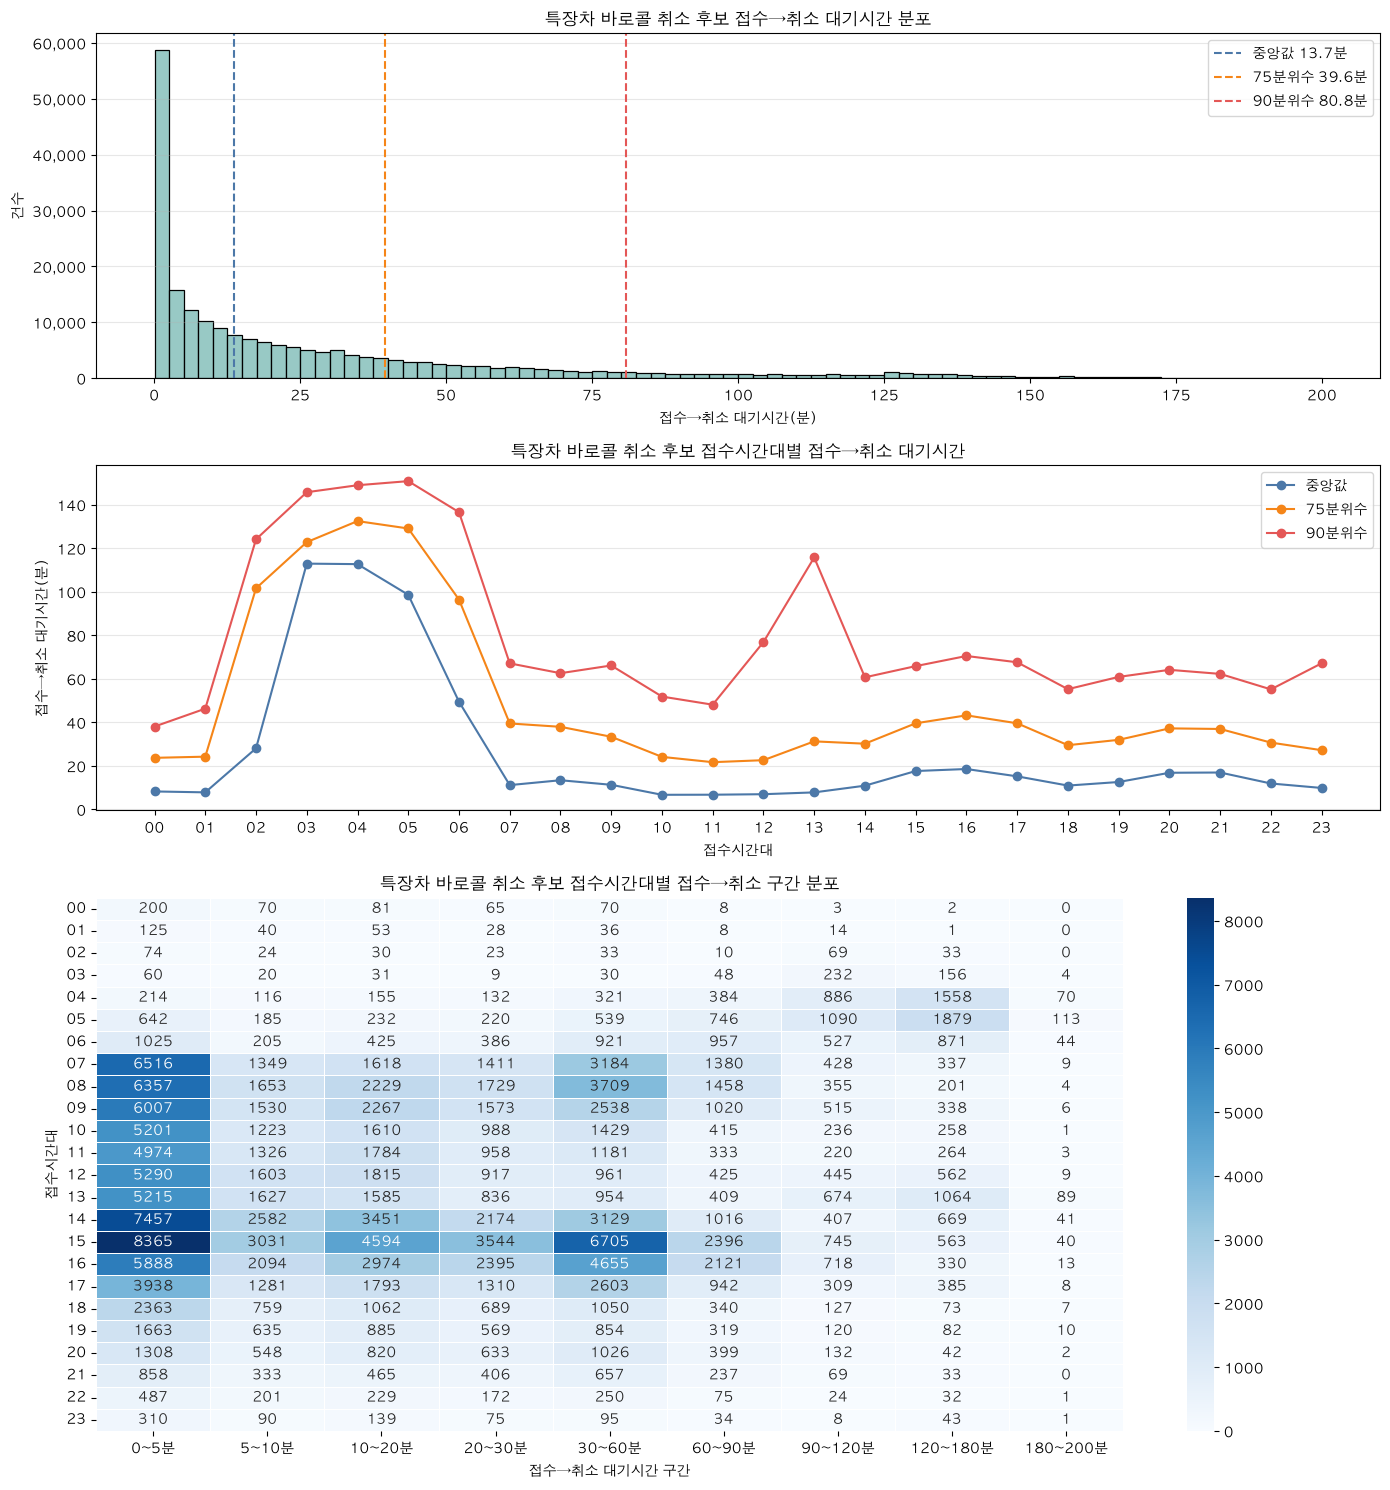

In [39]:
# 코드 셀 목적: 바로콜 취소 후보의 접수→취소 대기시간 분포를 시각화한다.
baro_cancel_data = special_cancel_baro_call.copy()
baro_cancel_data["접수시간대_HH"] = baro_cancel_data["접수일시"].dt.strftime("%H")
baro_cancel_data["접수_취소_분"] = pd.to_numeric(baro_cancel_data["접수_취소_분"], errors="coerce")
baro_cancel_data["배차_취소_분"] = pd.to_numeric(baro_cancel_data["배차_취소_분"], errors="coerce")

baro_cancel_wait = baro_cancel_data[baro_cancel_data["접수_취소_분"].between(0, 200)].copy()
baro_cancel_bins = [0, 5, 10, 20, 30, 60, 90, 120, 180, 200]
baro_cancel_labels = ["0~5분", "5~10분", "10~20분", "20~30분", "30~60분", "60~90분", "90~120분", "120~180분", "180~200분"]
baro_cancel_wait["접수_취소_구간"] = pd.cut(baro_cancel_wait["접수_취소_분"], bins=baro_cancel_bins, labels=baro_cancel_labels, right=True, include_lowest=True)

baro_cancel_summary = pd.DataFrame({
    "지표": ["접수→취소", "배차→취소"],
    "유효건수": [baro_cancel_data["접수_취소_분"].notna().sum(), baro_cancel_data["배차_취소_분"].notna().sum()],
    "중앙값": [baro_cancel_data["접수_취소_분"].median(), baro_cancel_data["배차_취소_분"].median()],
    "75분위수": [baro_cancel_data["접수_취소_분"].quantile(0.75), baro_cancel_data["배차_취소_분"].quantile(0.75)],
    "90분위수": [baro_cancel_data["접수_취소_분"].quantile(0.90), baro_cancel_data["배차_취소_분"].quantile(0.90)],
    "95분위수": [baro_cancel_data["접수_취소_분"].quantile(0.95), baro_cancel_data["배차_취소_분"].quantile(0.95)],
    "최소값": [baro_cancel_data["접수_취소_분"].min(), baro_cancel_data["배차_취소_분"].min()],
    "최대값": [baro_cancel_data["접수_취소_분"].max(), baro_cancel_data["배차_취소_분"].max()]
})
display(baro_cancel_summary)

hourly_baro_cancel = (
    baro_cancel_wait.groupby("접수시간대_HH", observed=False)
    .agg(취소건수=("접수_취소_분", "count"), 중앙값=("접수_취소_분", "median"), p75=("접수_취소_분", lambda x: x.quantile(0.75)), p90=("접수_취소_분", lambda x: x.quantile(0.90)))
    .reindex([f"{hour:02d}" for hour in range(24)])
    .reset_index()
)
baro_cancel_heatmap = (
    baro_cancel_wait.pivot_table(index="접수시간대_HH", columns="접수_취소_구간", values="접수_취소_분", aggfunc="count", observed=False)
    .reindex(index=[f"{hour:02d}" for hour in range(24)], columns=baro_cancel_labels)
    .fillna(0)
)

fig = plt.figure(figsize=(14, 15))
grid = fig.add_gridspec(3, 1, height_ratios=[1.1, 1.1, 1.7])
ax1 = fig.add_subplot(grid[0])
ax2 = fig.add_subplot(grid[1])
ax3 = fig.add_subplot(grid[2])

sns.histplot(baro_cancel_wait["접수_취소_분"], bins=80, color="#76b7b2", ax=ax1)
for q, color, label in [(0.5, "#4c78a8", "중앙값"), (0.75, "#f58518", "75분위수"), (0.90, "#e45756", "90분위수")]:
    value = baro_cancel_wait["접수_취소_분"].quantile(q)
    ax1.axvline(value, color=color, linestyle="--", linewidth=1.5, label=f"{label} {value:.1f}분")
ax1.set_title("특장차 바로콜 취소 후보 접수→취소 대기시간 분포")
ax1.set_xlabel("접수→취소 대기시간(분)")
ax1.set_ylabel("건수")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax1.grid(axis="y", alpha=0.3)
ax1.legend()

ax2.plot(hourly_baro_cancel["접수시간대_HH"], hourly_baro_cancel["중앙값"], marker="o", label="중앙값", color="#4c78a8")
ax2.plot(hourly_baro_cancel["접수시간대_HH"], hourly_baro_cancel["p75"], marker="o", label="75분위수", color="#f58518")
ax2.plot(hourly_baro_cancel["접수시간대_HH"], hourly_baro_cancel["p90"], marker="o", label="90분위수", color="#e45756")
ax2.set_title("특장차 바로콜 취소 후보 접수시간대별 접수→취소 대기시간")
ax2.set_xlabel("접수시간대")
ax2.set_ylabel("접수→취소 대기시간(분)")
ax2.grid(axis="y", alpha=0.3)
ax2.legend()

sns.heatmap(baro_cancel_heatmap, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5, ax=ax3)
ax3.set_title("특장차 바로콜 취소 후보 접수시간대별 접수→취소 구간 분포")
ax3.set_xlabel("접수→취소 대기시간 구간")
ax3.set_ylabel("접수시간대")
plt.tight_layout()
plt.show()

- 전체적으로 접수 직후 취소가 압도적으로 많음
    - 히스토그램에서 0분대 막대가 가장 크고 중앙값이 13.7분 => 바로콜 취소 후보의 절반은 접수 후 약 14분 안에 취소됨
    - 75분위수는 39.6분, 90분위수는 80.8분이라서 대부분은 1시간 내외에 취소되지만 일부 긴 꼬리가 있음
- 취소가 많이 발생하는 시간대와 오래 기다린 뒤 취소하는 시간대가 다름.
    - 히트맵을 보면 실제 취소 건수는 07~16시에 많고 0~5분 구간이 가장 진함 => 낮 시간대는 바로 접수했다가 금방 취소하는 건이 많음
    - 선그래프를 보면 02~06시는 접수→취소 시간이 매우 긺. 특히 03~05시는 중앙값도 100분 이상이고 90분위수는 140~150분 수준.
    - 그런데 히트맵상 건수는 낮 시간대보다 훨씬 적음 => 새벽 패턴은 “많이 발생한다”기보다는 발생하면 오래 기다린 뒤 취소되는 경향이 강한 듯
- 13시에도 튀는 구간 있음
    - 13시는 중앙값은 낮지만 90분위수가 크게 올라가 있음. 대부분은 빨리 취소되지만 일부 장시간 대기 후 취소가 섞인 시간대로 보임

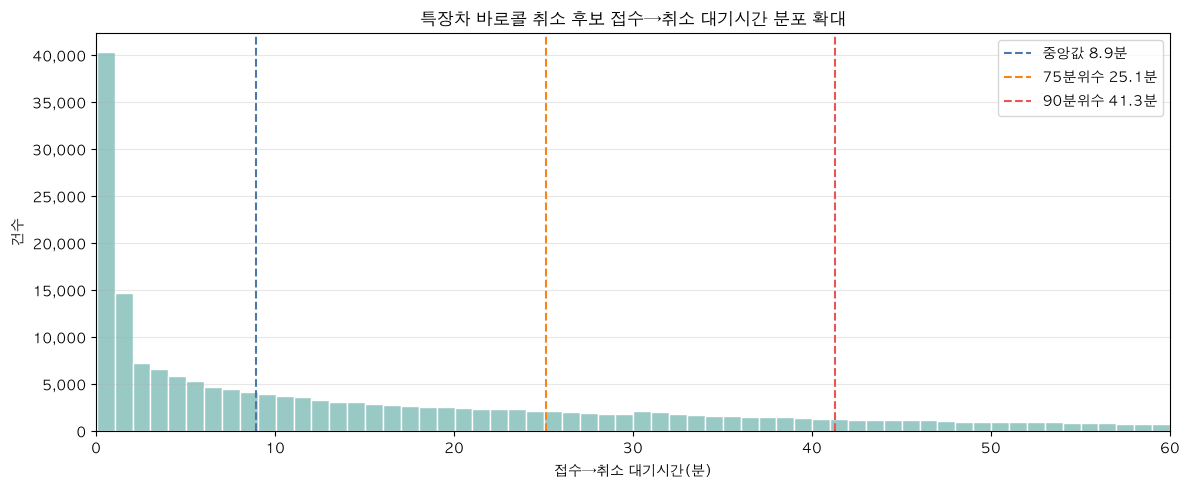

In [40]:
# 코드 셀 목적: 바로콜 취소 후보의 접수→취소 대기시간 분포를 0~60분 구간으로 확대해 확인한다.

baro_cancel_zoom = baro_cancel_data["접수_취소_분"].dropna()
baro_cancel_zoom = baro_cancel_zoom[baro_cancel_zoom.between(0, 60)]

zoom_quantiles = {
    "중앙값": baro_cancel_zoom.quantile(0.50),
    "75분위수": baro_cancel_zoom.quantile(0.75),
    "90분위수": baro_cancel_zoom.quantile(0.90),
}

fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    baro_cancel_zoom,
    bins=60,
    color="#76b7b2",
    edgecolor="white",
    ax=ax,
)

for label, value in zoom_quantiles.items():
    color = {
        "중앙값": "#4c78a8",
        "75분위수": "#f58518",
        "90분위수": "#e45756",
    }[label]
    ax.axvline(
        value,
        color=color,
        linestyle="--",
        linewidth=1.5,
        label=f"{label} {value:.1f}분",
    )

ax.set_title("특장차 바로콜 취소 후보 접수→취소 대기시간 분포 확대")
ax.set_xlabel("접수→취소 대기시간(분)")
ax.set_ylabel("건수")
ax.set_xlim(0, 60)
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

,접수→취소 구간,취소건수
0,0~5분,74537
1,5~10분,22525
2,10~30분,51569
3,30~60분,36930
4,60~120분,23833
5,120~200분,10251


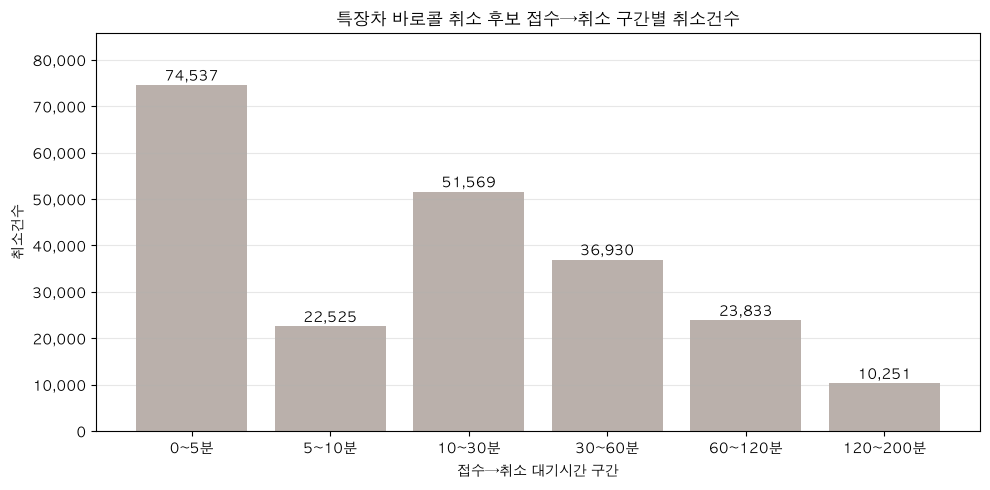

In [88]:
# 코드 셀 목적: 바로콜 취소 후보의 접수→취소 대기시간 구간별 취소건수를 확인한다.

baro_cancel_count = baro_cancel_data["접수_취소_분"].dropna()
baro_cancel_count = baro_cancel_count[baro_cancel_count.between(0, 200)]

cancel_count_bins = [0, 5, 10, 30, 60, 120, 200]
cancel_count_labels = [
    "0~5분",
    "5~10분",
    "10~30분",
    "30~60분",
    "60~120분",
    "120~200분",
]

baro_cancel_count_summary = (
    pd.cut(
        baro_cancel_count,
        bins=cancel_count_bins,
        labels=cancel_count_labels,
        right=True,
        include_lowest=True,
    )
    .value_counts(sort=False)
    .rename_axis("접수→취소 구간")
    .reset_index(name="취소건수")
)

display(baro_cancel_count_summary)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    baro_cancel_count_summary["접수→취소 구간"],
    baro_cancel_count_summary["취소건수"],
    color="#bab0ab",
)

for idx, row in baro_cancel_count_summary.iterrows():
    ax.text(
        idx,
        row["취소건수"],
        f'{row["취소건수"]:,}',
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("특장차 바로콜 취소 후보 접수→취소 구간별 취소건수")
ax.set_xlabel("접수→취소 대기시간 구간")
ax.set_ylabel("취소건수")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax.set_ylim(0, baro_cancel_count_summary["취소건수"].max() * 1.15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

,접수→취소 구간,건수,비율(%)
0,0~5분,74537,33.935214
1,5~10분,22525,10.255185
2,10~30분,51569,23.478340
3,30~60분,36930,16.813495
4,60~120분,23833,10.850691
5,120~200분,10251,4.667076


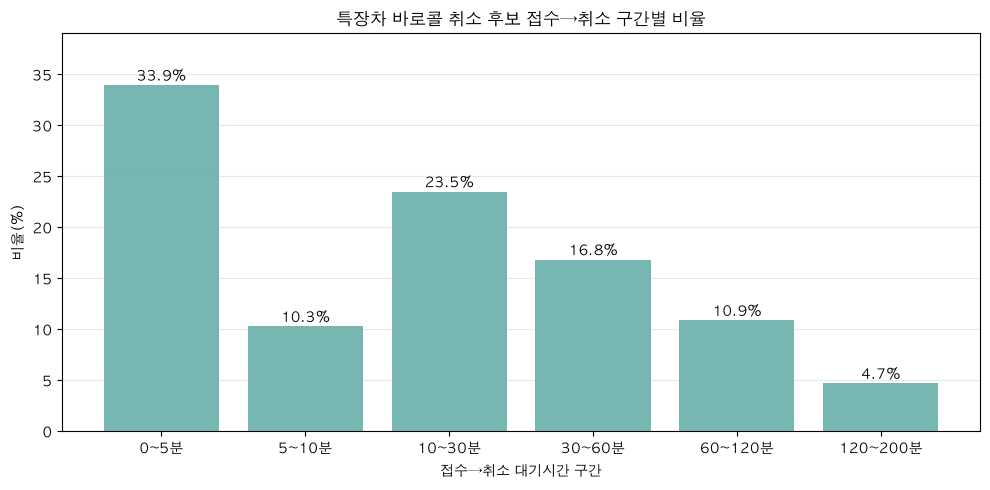

In [41]:
# 코드 셀 목적: 바로콜 취소 후보의 접수→취소 대기시간 구간별 비율을 확인한다.

baro_cancel_ratio = baro_cancel_data["접수_취소_분"].dropna()
baro_cancel_ratio = baro_cancel_ratio[baro_cancel_ratio.between(0, 200)]

cancel_ratio_bins = [0, 5, 10, 30, 60, 120, 200]
cancel_ratio_labels = [
    "0~5분",
    "5~10분",
    "10~30분",
    "30~60분",
    "60~120분",
    "120~200분",
]

baro_cancel_ratio_summary = (
    pd.cut(
        baro_cancel_ratio,
        bins=cancel_ratio_bins,
        labels=cancel_ratio_labels,
        right=True,
        include_lowest=True,
    )
    .value_counts(sort=False)
    .rename_axis("접수→취소 구간")
    .reset_index(name="건수")
)

baro_cancel_ratio_summary["비율(%)"] = (
    baro_cancel_ratio_summary["건수"]
    / baro_cancel_ratio_summary["건수"].sum()
    * 100
)

display(baro_cancel_ratio_summary)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    baro_cancel_ratio_summary["접수→취소 구간"],
    baro_cancel_ratio_summary["비율(%)"],
    color="#76b7b2",
)

for idx, row in baro_cancel_ratio_summary.iterrows():
    ax.text(
        idx,
        row["비율(%)"],
        f'{row["비율(%)"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("특장차 바로콜 취소 후보 접수→취소 구간별 비율")
ax.set_xlabel("접수→취소 대기시간 구간")
ax.set_ylabel("비율(%)")
ax.set_ylim(0, baro_cancel_ratio_summary["비율(%)"].max() * 1.15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

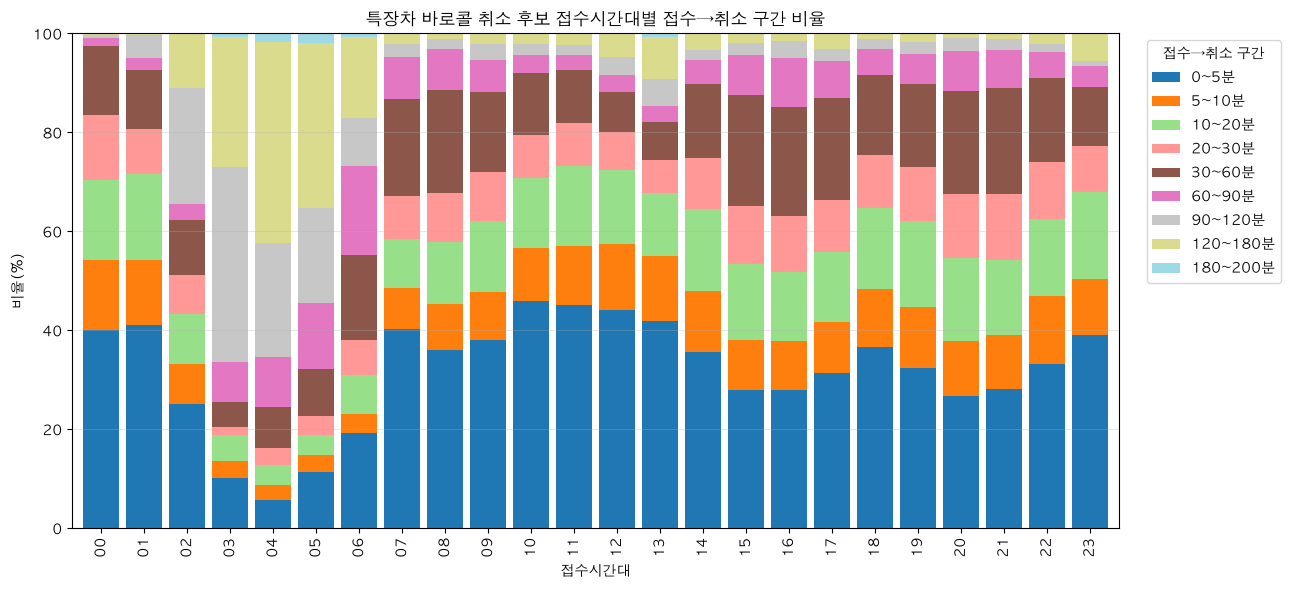

In [42]:
# 코드 셀 목적: 바로콜 취소 후보의 접수시간대별 접수→취소 구간 비율을 누적 막대그래프로 확인한다.
baro_cancel_ratio_data = baro_cancel_wait.dropna(subset=["접수시간대_HH", "접수_취소_구간"]).copy()

hourly_cancel_ratio = (
    baro_cancel_ratio_data
    .pivot_table(
        index="접수시간대_HH",
        columns="접수_취소_구간",
        values="접수_취소_분",
        aggfunc="count",
        observed=False,
    )
    .reindex(index=[f"{hour:02d}" for hour in range(24)], columns=baro_cancel_labels)
    .fillna(0)
)
hourly_cancel_ratio_pct = hourly_cancel_ratio.div(hourly_cancel_ratio.sum(axis=1).replace(0, pd.NA), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
hourly_cancel_ratio_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="tab20",
    width=0.85,
)
ax.set_title("특장차 바로콜 취소 후보 접수시간대별 접수→취소 구간 비율")
ax.set_xlabel("접수시간대")
ax.set_ylabel("비율(%)")
ax.set_ylim(0, 100)
ax.legend(title="접수→취소 구간", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

- 낮/저녁 : 접수 직후 0~5분 내 빠른 취소가 중심
- 새벽 03~05시 : 장시간 대기 후 취소 비중이 큼
- 오후 일부 시간대 : 빠른 취소와 중장기 취소가 섞임

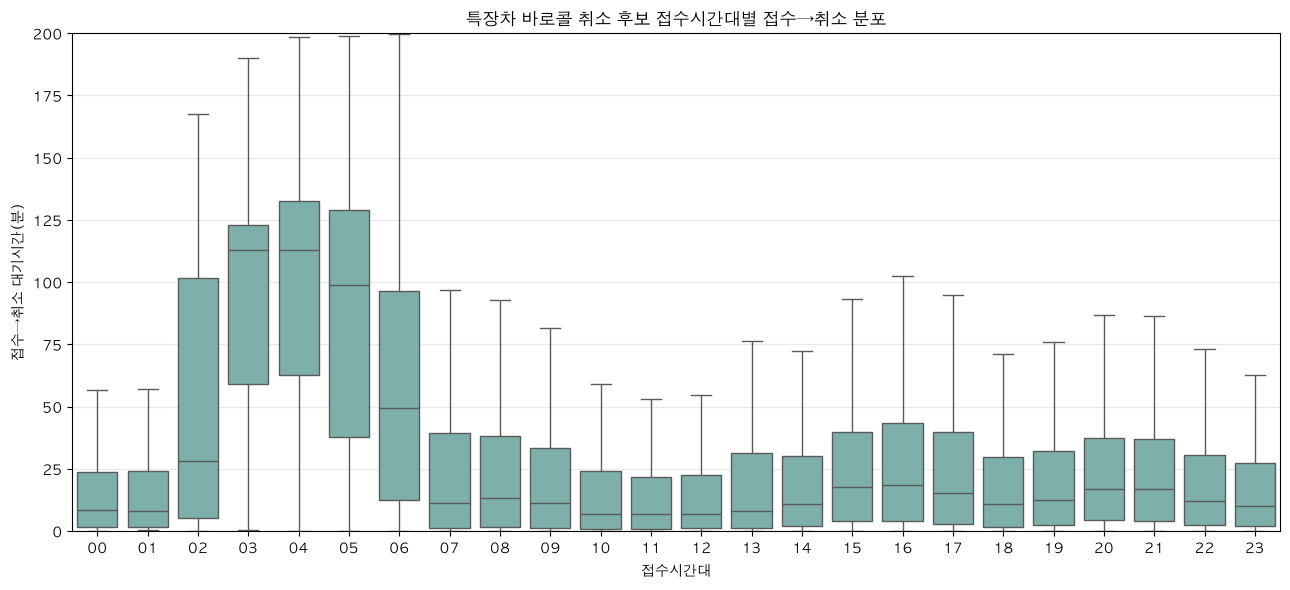

In [43]:
# 코드 셀 목적: 바로콜 취소 후보의 접수시간대별 접수→취소 분포 폭을 박스플롯으로 확인한다.
baro_cancel_box_data = baro_cancel_data[
    baro_cancel_data["접수_취소_분"].between(0, 200)
    & baro_cancel_data["접수시간대_HH"].notna()
].copy()

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=baro_cancel_box_data,
    x="접수시간대_HH",
    y="접수_취소_분",
    order=[f"{hour:02d}" for hour in range(24)],
    showfliers=False,
    color="#76b7b2",
    ax=ax,
)
ax.set_title("특장차 바로콜 취소 후보 접수시간대별 접수→취소 분포")
ax.set_xlabel("접수시간대")
ax.set_ylabel("접수→취소 대기시간(분)")
ax.set_ylim(0, 200)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

- 00~01시, 07~23시
    - 중앙값이 대체로 낮음
    - 대부분 시간대에서 중앙값이 10~20분 안팎
    - 박스도 비교적 낮은 구간 => 바로콜 취소가 접수 후 비교적 빠르게 발생하는 편

- 02시
    - 중앙값은 30분 미만이지만 박스와 위쪽 수염이 크게 늘어남
    - 02시부터 장시간 대기 후 취소가 섞이기 시작

- 03~05시
    - 중앙값이 100분 안팎으로 크게 올라감
    - 박스 자체가 60~130분 부근에 걸쳐 있어 일부 이상치 때문이 아니라 해당 시간대 취소 전반이 길게 나타남
    - 특히 03~04시는 취소까지 2시간 가까이 걸리는 건도 많아 보임

,접수시간대_HH,탑승완료건수,취소건수,중앙값,p75,p90,바로콜요청건수,취소율(%)
0,00,1685,499,8.266667,23.712917,38.084493,2184,22.847985
1,01,1024,305,7.847667,24.250000,46.305483,1329,22.949586
2,02,2546,296,28.082525,101.608371,124.134558,2842,10.415201
3,03,2583,590,112.952033,122.827433,145.766905,3173,18.594390
4,04,10542,3836,112.721583,132.496171,148.974550,14378,26.679649
5,05,12134,5646,98.634308,129.102125,150.860000,17780,31.754781
6,06,18466,5361,49.506783,96.447050,136.611717,23827,22.499685
7,07,69751,16232,11.183333,39.507375,67.120777,85983,18.878150
8,08,88382,17695,13.416450,37.966142,62.604450,106077,16.681279
9,09,75245,15794,11.325000,33.397904,66.147033,91039,17.348609


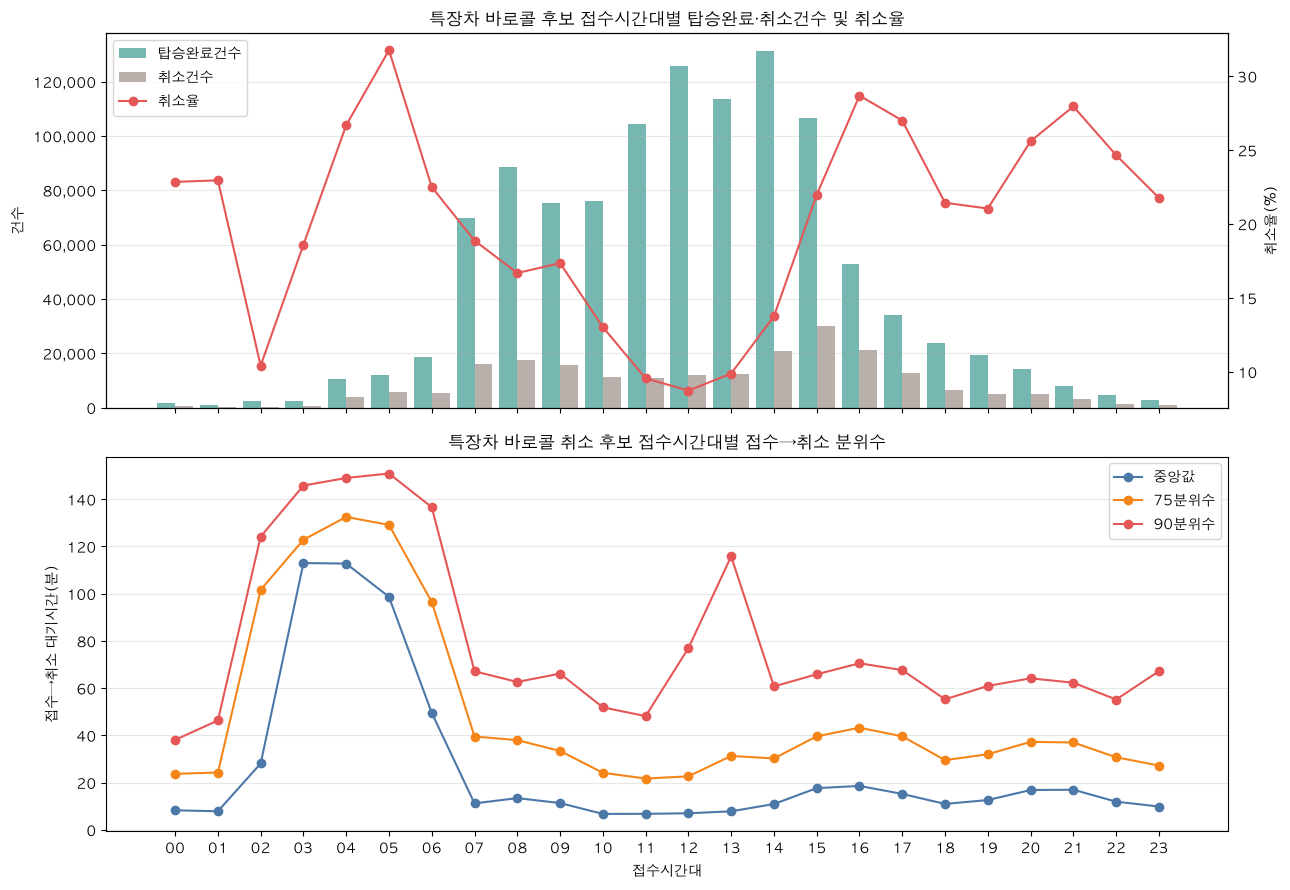

In [44]:
# 코드 셀 목적: 바로콜 후보의 접수시간대별 탑승완료건수·취소건수·취소율과 접수→취소 분위수를 확인한다.

baro_ride_hourly = special_ride_baro_call.copy()
baro_ride_hourly["접수시간대_HH"] = baro_ride_hourly["접수일시"].dt.strftime("%H")

hourly_baro_ride_count = (
    baro_ride_hourly
    .groupby("접수시간대_HH", observed=False)
    .size()
    .reindex([f"{hour:02d}" for hour in range(24)], fill_value=0)
    .rename("탑승완료건수")
    .reset_index()
)

hourly_baro_cancel_detail = (
    baro_cancel_wait
    .groupby("접수시간대_HH", observed=False)
    .agg(
        취소건수=("접수_취소_분", "count"),
        중앙값=("접수_취소_분", "median"),
        p75=("접수_취소_분", lambda x: x.quantile(0.75)),
        p90=("접수_취소_분", lambda x: x.quantile(0.90)),
    )
    .reindex([f"{hour:02d}" for hour in range(24)])
    .reset_index()
)

hourly_baro_detail = hourly_baro_ride_count.merge(
    hourly_baro_cancel_detail,
    on="접수시간대_HH",
    how="left",
)

hourly_baro_detail["취소건수"] = hourly_baro_detail["취소건수"].fillna(0)
hourly_baro_detail["바로콜요청건수"] = (
    hourly_baro_detail["탑승완료건수"]
    + hourly_baro_detail["취소건수"]
)
hourly_baro_detail["취소율(%)"] = (
    hourly_baro_detail["취소건수"]
    / hourly_baro_detail["바로콜요청건수"].replace(0, pd.NA)
    * 100
)

display(hourly_baro_detail)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

x = range(len(hourly_baro_detail))
bar_width = 0.42

axes[0].bar(
    [idx - bar_width / 2 for idx in x],
    hourly_baro_detail["탑승완료건수"],
    width=bar_width,
    color="#76b7b2",
    label="탑승완료건수",
)

axes[0].bar(
    [idx + bar_width / 2 for idx in x],
    hourly_baro_detail["취소건수"],
    width=bar_width,
    color="#bab0ab",
    label="취소건수",
)

ax0_right = axes[0].twinx()
ax0_right.plot(
    x,
    hourly_baro_detail["취소율(%)"],
    marker="o",
    color="#e45756",
    label="취소율",
)

axes[0].set_title("특장차 바로콜 후보 접수시간대별 탑승완료·취소건수 및 취소율")
axes[0].set_ylabel("건수")
ax0_right.set_ylabel("취소율(%)")

axes[0].set_xticks(list(x))
axes[0].set_xticklabels(hourly_baro_detail["접수시간대_HH"])

axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[0].grid(axis="y", alpha=0.3)

lines_0, labels_0 = axes[0].get_legend_handles_labels()
lines_1, labels_1 = ax0_right.get_legend_handles_labels()
axes[0].legend(lines_0 + lines_1, labels_0 + labels_1, loc="upper left")

axes[1].plot(
    hourly_baro_detail["접수시간대_HH"],
    hourly_baro_detail["중앙값"],
    marker="o",
    label="중앙값",
    color="#4c78a8",
)
axes[1].plot(
    hourly_baro_detail["접수시간대_HH"],
    hourly_baro_detail["p75"],
    marker="o",
    label="75분위수",
    color="#f58518",
)
axes[1].plot(
    hourly_baro_detail["접수시간대_HH"],
    hourly_baro_detail["p90"],
    marker="o",
    label="90분위수",
    color="#e45756",
)

axes[1].set_title("특장차 바로콜 취소 후보 접수시간대별 접수→취소 분위수")
axes[1].set_xlabel("접수시간대")
axes[1].set_ylabel("접수→취소 대기시간(분)")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

첫 번째 그래프는 **취소건수가 많은 시간대가 실제로 취소 문제가 큰 시간대인지, 아니면 바로콜 요청 자체가 많은 시간대라 취소도 함께 많은 것인지**를 확인하기 위한 그래프
1. 바로콜 요청량은 낮 시간대에 집중됨
- 탑승완료건수를 보면 07~15시에 크게 증가하고 특히 11~15시가 가장 많음 => 특장차 바로콜 이용 자체가 낮 시간대에 집중되어 있음

2. 취소건수도 요청량이 많은 시간대에 함께 증가
- 취소건수는 07~17시에 많고 특히 14~16시 부근에서 높게 나타남 => 해당 시간대의 취소 문제가 크다기보다 그 시간대에 접수 자체가 많기 때문에 취소도 함께 많이 발생한 영향이 커 보임

3. 취소율은 건수와 다른 패턴을 보임
- 빨간선인 취소율을 보면 탑승완료건수와 취소건수가 많은 11~14시는 오히려 취소율이 낮은 편 => 특히 11~13시는 취소율이 10~12% 근처로 낮게 나타난다.
- 이 시간대는 취소가 많다기보다 **이용량이 많아서 취소건수도 함께 많아진 시간대**에 가까워 보임

4. 취소율이 높은 시간대는 새벽과 저녁 일부 시간대
- 03~05시는 취소율이 25~30% 이상으로 높고 16~17시, 20~22시도 취소율이 다시 올라감
- 특히 03~05시는 탑승완료건수는 많지 않은데 취소율이 높음 => **요청 대비 취소가 자주 발생하는 시간대**


```text
건수 기준 취소 집중 시간 : 14~16시
요청량 대비 취소율이 높은 시간 : 03~05시, 16~17시, 20~22시

=> 낮 시간대 취소건수 증가는 이용량 증가의 영향이 크고 새벽·저녁 일부 시간대는 실제 취소 위험이 상대적으로 높다.

,구분,건수,비율(%),중앙값,75분위수,90분위수
0,0~30분,148631,67.668738,4.965617,14.200000,22.713500
1,30~200분,71020,32.333993,58.153917,92.703075,129.303595


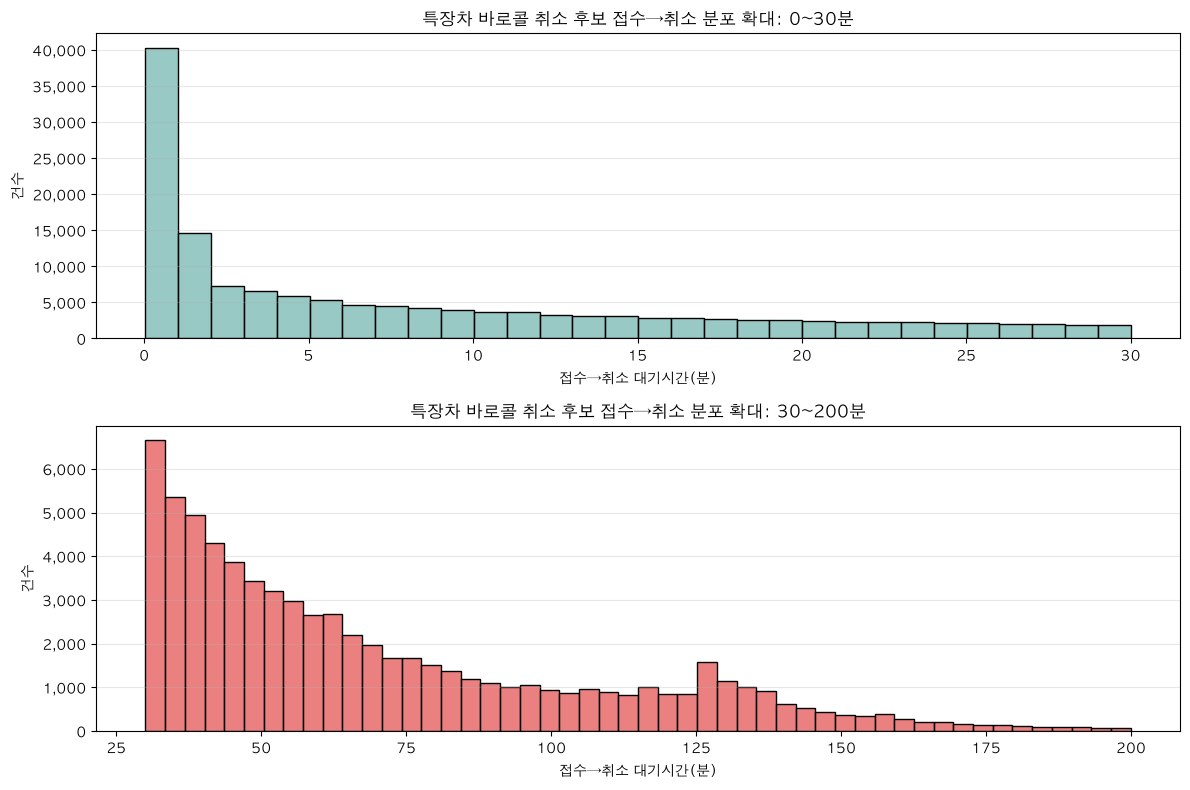

In [45]:
# 코드 셀 목적: 바로콜 취소 후보의 접수→취소 분포를 0~30분과 30~200분으로 나누어 확인한다.
short_cancel = baro_cancel_data[baro_cancel_data["접수_취소_분"].between(0, 30)]["접수_취소_분"].dropna()
long_cancel = baro_cancel_data[baro_cancel_data["접수_취소_분"].between(30, 200)]["접수_취소_분"].dropna()

split_distribution_summary = pd.DataFrame({
    "구분": ["0~30분", "30~200분"],
    "건수": [len(short_cancel), len(long_cancel)],
    "비율(%)": [len(short_cancel) / len(baro_cancel_wait) * 100, len(long_cancel) / len(baro_cancel_wait) * 100],
    "중앙값": [short_cancel.median(), long_cancel.median()],
    "75분위수": [short_cancel.quantile(0.75), long_cancel.quantile(0.75)],
    "90분위수": [short_cancel.quantile(0.90), long_cancel.quantile(0.90)],
})
display(split_distribution_summary)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

sns.histplot(short_cancel, bins=30, color="#76b7b2", ax=axes[0])
axes[0].set_title("특장차 바로콜 취소 후보 접수→취소 분포 확대: 0~30분")
axes[0].set_xlabel("접수→취소 대기시간(분)")
axes[0].set_ylabel("건수")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[0].grid(axis="y", alpha=0.3)

sns.histplot(long_cancel, bins=50, color="#e45756", ax=axes[1])
axes[1].set_title("특장차 바로콜 취소 후보 접수→취소 분포 확대: 30~200분")
axes[1].set_xlabel("접수→취소 대기시간(분)")
axes[1].set_ylabel("건수")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 6-2. 전일접수 취소 예정시각 기준 분석

전일접수 취소 후보는 전날 접수되는 예약성 건이므로 `접수→취소`가 길다고 해서 실제 대기 중 취소로 해석하기 어렵다. 핵심 지표는 `예정대비_취소_분 = 취소일시 - 예정일시`로 둔다.

`예정대비_취소_분`이 음수이면 예정시각보다 전에 취소된 건이고, 양수이면 예정시각 이후에 취소된 건이다.
```text
음수: 예정시각보다 전에 취소
0 근처: 예정시각 직전/직후 취소
양수: 예정시각 이후 취소

,지표,유효건수,중앙값,75분위수,90분위수
0,예정대비 취소,5938,-112.050000,-18.266667,5.093333
1,접수→취소,5938,1306.227750,1414.912500,1441.138515
2,배차→취소,712,3.332133,10.899775,18.133467


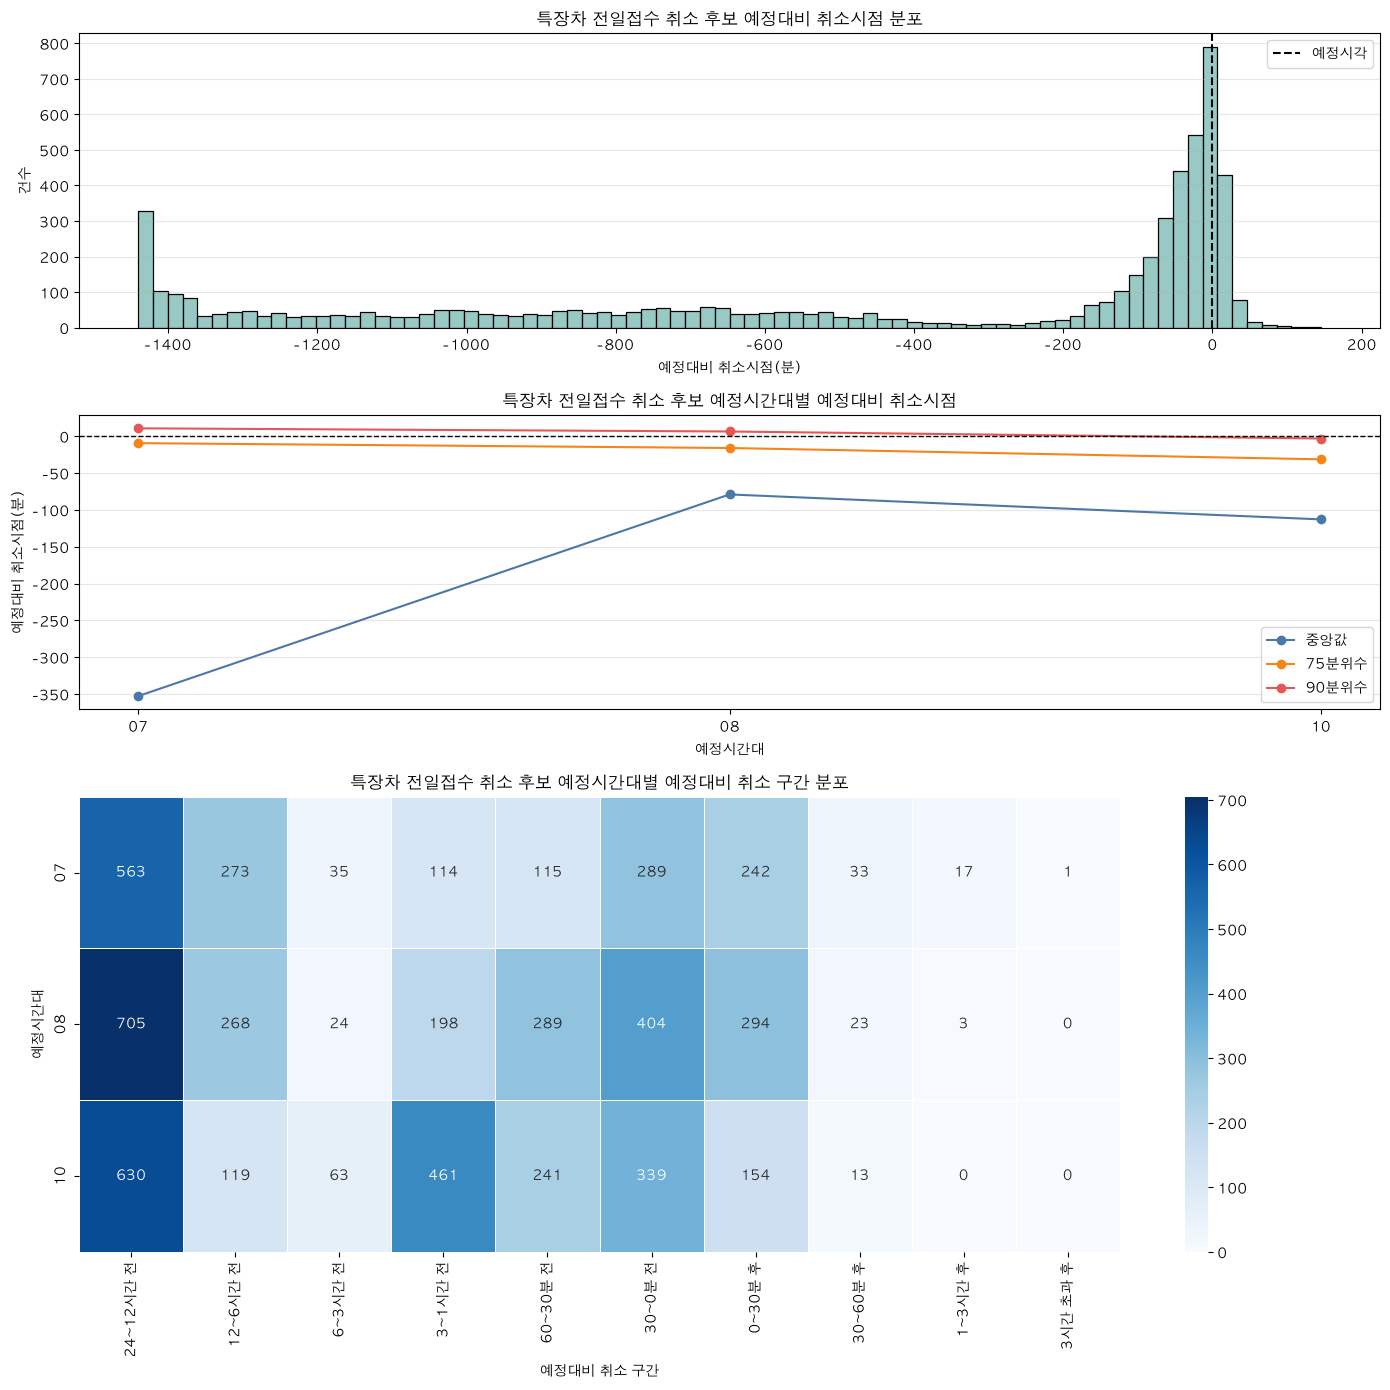

In [46]:
# 코드 셀 목적: 전일접수 취소 후보의 예정시각 대비 취소시점 분포를 시각화한다.
previous_day_cancel_data = special_cancel_previous_day.copy()
previous_day_cancel_data["예정일시"] = pd.to_datetime(previous_day_cancel_data["예정일시"], errors="coerce")
previous_day_cancel_data["취소일시"] = pd.to_datetime(previous_day_cancel_data["취소일시"], errors="coerce")
previous_day_cancel_data["예정대비_취소_분"] = (previous_day_cancel_data["취소일시"] - previous_day_cancel_data["예정일시"]).dt.total_seconds() / 60
previous_day_cancel_data["예정시간대_HH"] = previous_day_cancel_data["예정일시"].dt.strftime("%H")

reservation_cancel_bins = [-1440, -720, -360, -180, -60, -30, 0, 30, 60, 180, float("inf")]
reservation_cancel_labels = ["24~12시간 전", "12~6시간 전", "6~3시간 전", "3~1시간 전", "60~30분 전", "30~0분 전", "0~30분 후", "30~60분 후", "1~3시간 후", "3시간 초과 후"]
previous_day_cancel_data["예정대비_취소_구간"] = pd.cut(previous_day_cancel_data["예정대비_취소_분"], bins=reservation_cancel_bins, labels=reservation_cancel_labels, right=True, include_lowest=True)

previous_day_cancel_summary = pd.DataFrame({
    "지표": ["예정대비 취소", "접수→취소", "배차→취소"],
    "유효건수": [previous_day_cancel_data["예정대비_취소_분"].notna().sum(), previous_day_cancel_data["접수_취소_분"].notna().sum(), previous_day_cancel_data["배차_취소_분"].notna().sum()],
    "중앙값": [previous_day_cancel_data["예정대비_취소_분"].median(), previous_day_cancel_data["접수_취소_분"].median(), previous_day_cancel_data["배차_취소_분"].median()],
    "75분위수": [previous_day_cancel_data["예정대비_취소_분"].quantile(0.75), previous_day_cancel_data["접수_취소_분"].quantile(0.75), previous_day_cancel_data["배차_취소_분"].quantile(0.75)],
    "90분위수": [previous_day_cancel_data["예정대비_취소_분"].quantile(0.90), previous_day_cancel_data["접수_취소_분"].quantile(0.90), previous_day_cancel_data["배차_취소_분"].quantile(0.90)],
})
display(previous_day_cancel_summary)

previous_day_hourly_cancel = previous_day_cancel_data.dropna(subset=["예정시간대_HH", "예정대비_취소_분"]).groupby("예정시간대_HH", observed=False).agg(취소건수=("예정대비_취소_분", "count"), 중앙값=("예정대비_취소_분", "median"), p75=("예정대비_취소_분", lambda x: x.quantile(0.75)), p90=("예정대비_취소_분", lambda x: x.quantile(0.90))).reset_index()
previous_day_cancel_heatmap = previous_day_cancel_data.dropna(subset=["예정시간대_HH", "예정대비_취소_구간"]).pivot_table(index="예정시간대_HH", columns="예정대비_취소_구간", values="예정대비_취소_분", aggfunc="count", observed=False).reindex(columns=reservation_cancel_labels).fillna(0)

fig = plt.figure(figsize=(14, 14))
grid = fig.add_gridspec(3, 1, height_ratios=[1.1, 1.1, 1.7])
ax1 = fig.add_subplot(grid[0])
ax2 = fig.add_subplot(grid[1])
ax3 = fig.add_subplot(grid[2])

plot_values = previous_day_cancel_data["예정대비_취소_분"].dropna()
plot_values = plot_values[plot_values.between(-1440, 180)]
sns.histplot(plot_values, bins=80, color="#76b7b2", ax=ax1)
ax1.axvline(0, color="black", linestyle="--", linewidth=1.5, label="예정시각")
ax1.set_title("특장차 전일접수 취소 후보 예정대비 취소시점 분포")
ax1.set_xlabel("예정대비 취소시점(분)")
ax1.set_ylabel("건수")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax1.grid(axis="y", alpha=0.3)
ax1.legend()

ax2.plot(previous_day_hourly_cancel["예정시간대_HH"], previous_day_hourly_cancel["중앙값"], marker="o", label="중앙값", color="#4c78a8")
ax2.plot(previous_day_hourly_cancel["예정시간대_HH"], previous_day_hourly_cancel["p75"], marker="o", label="75분위수", color="#f58518")
ax2.plot(previous_day_hourly_cancel["예정시간대_HH"], previous_day_hourly_cancel["p90"], marker="o", label="90분위수", color="#e45756")
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("특장차 전일접수 취소 후보 예정시간대별 예정대비 취소시점")
ax2.set_xlabel("예정시간대")
ax2.set_ylabel("예정대비 취소시점(분)")
ax2.grid(axis="y", alpha=0.3)
ax2.legend()

sns.heatmap(previous_day_cancel_heatmap, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5, ax=ax3)
ax3.set_title("특장차 전일접수 취소 후보 예정시간대별 예정대비 취소 구간 분포")
ax3.set_xlabel("예정대비 취소 구간")
ax3.set_ylabel("예정시간대")
plt.tight_layout()
plt.show()

전일접수 취소가 **대부분 예정시각 이전에 발생, 특히 예정 직전 취소와 전날 조기 취소가 함께 존재**는 것을 보여줌

1. 히스토그램: 예정 직전 취소가 가장 많이 몰림
- 첫 번째 그래프는 `예정대비_취소_분 = 취소일시 - 예정일시`의 분포다

2. 분위수 선그래프: 예정시간대별 취소 시점이 다름
- 07시 예정 건은 중앙값이 약 -350분 수준 => 07시 예정 취소 건의 절반은 예정시각보다 약 5~6시간 전에 취소됨
- 08시, 10시 예정 건은 중앙값이 -80~-110분 정도로 07시보다 예정시각에 더 가까운 시점에 취소되는 편
- 많은 취소는 예정 전에 발생, 상위 일부는 예정시각 직전 또는 이후에 취소

3. 히트맵: 취소 시점이 여러 패턴으로 나뉨
- 모든 예정시간대에서 24~12시간 전 취소가 많음
- 08시 예정 건은 705건, 10시 예정 건은 630건, 07시 예정 건은 563건으로 전날 조기 취소가 큰 축을 이룸. 그리고 30~0분 전, 0~30분 후 구간도 많음

=> *전일접수 취소는 대부분 예약 시간 전에 발생하지만 일부는 차량 운영에 영향을 줄 수 있는 시점에 가까워져서 발생*

## 6-3. 심야시간 사전예약 취소 예정시각 기준 분석

심야시간 사전예약 취소 후보도 예약성 접수이므로 `예정대비_취소_분`을 핵심 지표로 본다. 다만 심야시간 사전예약 후보는 표본 수가 작을 수 있으므로, 분포 해석은 일반화보다 패턴 점검에 가깝게 본다.

예정시간대별 취소 건수를 함께 확인해 01~05시 운영시간대 중 어느 시간대에서 취소가 집중되는지도 본다.

,지표,유효건수,중앙값,75분위수,90분위수
0,예정대비 취소,39,-331.250000,-61.175000,-14.430000
1,접수→취소,39,367.866667,684.433333,824.733333
2,배차→취소,5,2.706167,9.541117,27.958977


심야시간 사전예약 취소 후보 예정시간대별 취소건수


,예정시간대_HH,취소건수
0,01,5
1,02,4
2,03,13
3,04,16
4,05,1


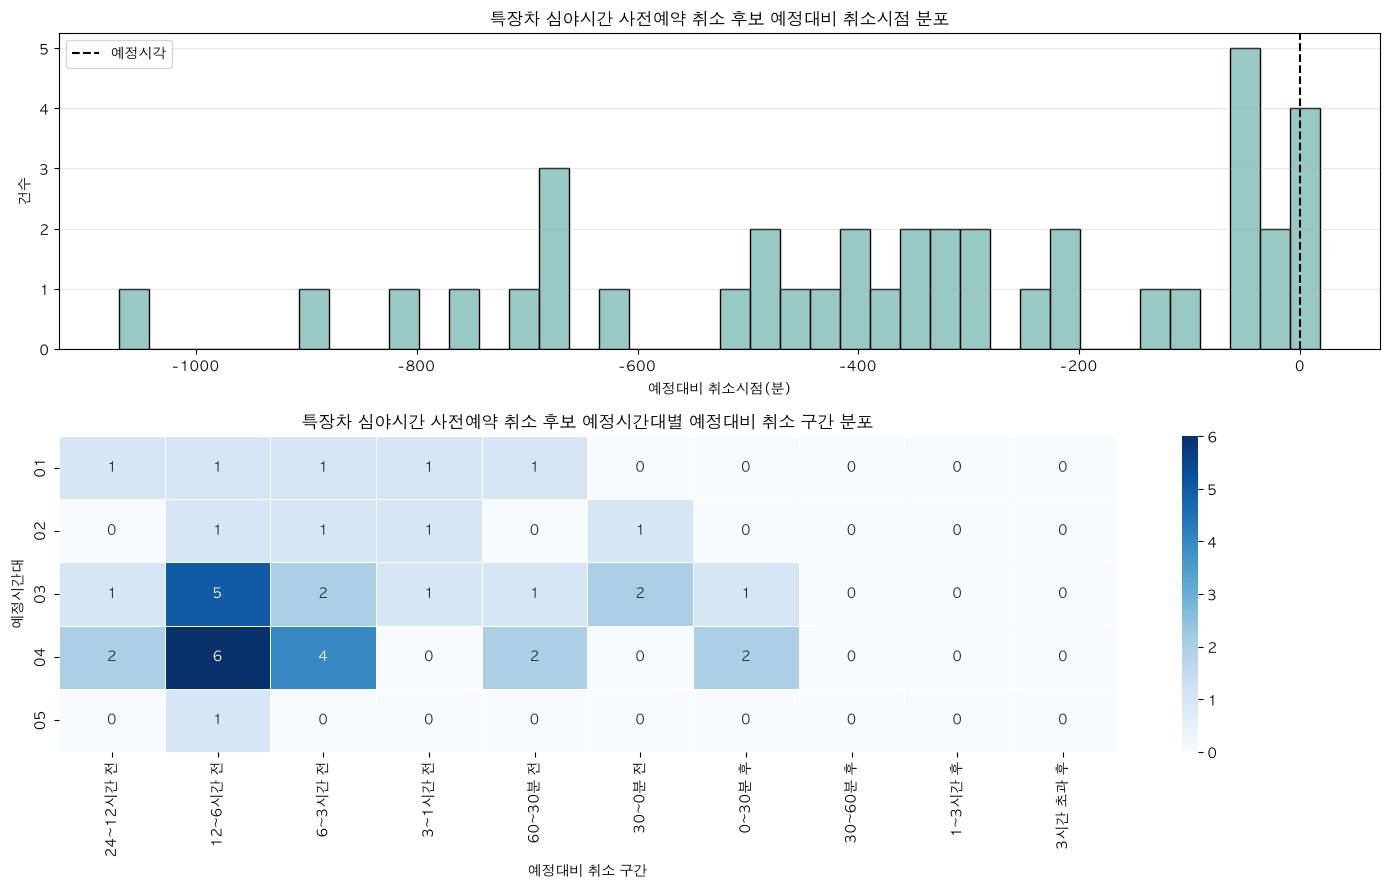

In [47]:
# 코드 셀 목적: 심야시간 사전예약 취소 후보의 예정시각 대비 취소시점 분포를 시각화한다.
night_cancel_data = special_cancel_night_reservation.copy()
night_cancel_data["예정일시"] = pd.to_datetime(night_cancel_data["예정일시"], errors="coerce")
night_cancel_data["취소일시"] = pd.to_datetime(night_cancel_data["취소일시"], errors="coerce")
night_cancel_data["예정대비_취소_분"] = (night_cancel_data["취소일시"] - night_cancel_data["예정일시"]).dt.total_seconds() / 60
night_cancel_data["예정시간대_HH"] = night_cancel_data["예정일시"].dt.strftime("%H")
night_cancel_data["예정대비_취소_구간"] = pd.cut(night_cancel_data["예정대비_취소_분"], bins=reservation_cancel_bins, labels=reservation_cancel_labels, right=True, include_lowest=True)

night_cancel_summary = pd.DataFrame({
    "지표": ["예정대비 취소", "접수→취소", "배차→취소"],
    "유효건수": [night_cancel_data["예정대비_취소_분"].notna().sum(), night_cancel_data["접수_취소_분"].notna().sum(), night_cancel_data["배차_취소_분"].notna().sum()],
    "중앙값": [night_cancel_data["예정대비_취소_분"].median(), night_cancel_data["접수_취소_분"].median(), night_cancel_data["배차_취소_분"].median()],
    "75분위수": [night_cancel_data["예정대비_취소_분"].quantile(0.75), night_cancel_data["접수_취소_분"].quantile(0.75), night_cancel_data["배차_취소_분"].quantile(0.75)],
    "90분위수": [night_cancel_data["예정대비_취소_분"].quantile(0.90), night_cancel_data["접수_취소_분"].quantile(0.90), night_cancel_data["배차_취소_분"].quantile(0.90)],
})
night_cancel_hour_summary = night_cancel_data.groupby("예정시간대_HH", observed=False).agg(취소건수=("취소일시", "count")).reset_index()
display(night_cancel_summary)
print("심야시간 사전예약 취소 후보 예정시간대별 취소건수")
display(night_cancel_hour_summary)

night_cancel_heatmap = night_cancel_data.dropna(subset=["예정시간대_HH", "예정대비_취소_구간"]).pivot_table(index="예정시간대_HH", columns="예정대비_취소_구간", values="예정대비_취소_분", aggfunc="count", observed=False).reindex(columns=reservation_cancel_labels).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
night_plot_values = night_cancel_data["예정대비_취소_분"].dropna()
night_plot_values = night_plot_values[night_plot_values.between(-1440, 180)]
sns.histplot(night_plot_values, bins=40, color="#76b7b2", ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.5, label="예정시각")
axes[0].set_title("특장차 심야시간 사전예약 취소 후보 예정대비 취소시점 분포")
axes[0].set_xlabel("예정대비 취소시점(분)")
axes[0].set_ylabel("건수")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

sns.heatmap(night_cancel_heatmap, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5, ax=axes[1])
axes[1].set_title("특장차 심야시간 사전예약 취소 후보 예정시간대별 예정대비 취소 구간 분포")
axes[1].set_xlabel("예정대비 취소 구간")
axes[1].set_ylabel("예정시간대")
plt.tight_layout()
plt.show()

심야시간 사전예약 취소 후보는 건수가 적기 때문에 전일접수처럼 일반적인 경향으로 단정하기보다는 **후보군의 취소 시점 패턴을 확인하는 참고 지표** 로 해석하는 것이 적절함

1. 히스토그램 : 취소 시점은 대부분 예정시각 이전에 분포
- 심야시간 사전예약도 예약성 접수이므로 예정시각 전에 취소되는 것은 자연스러운 패턴
- 0분 근처에도 일부 건수가 보임 => 예정시각 직전 또는 예정시각 직후에 취소된 건으로, 건수는 많지 않지만 실제 차량 운영에는 영향을 줄 수 있는 취소로 볼 수 있음

2. 히트맵 : 취소는 주로 03시와 04시 예정 건에서 많이 나타남
- 03시와 04시는 `12~6시간 전`, `6~3시간 전` 구간의 취소가 상대적으로 많음 => 심야시간 사전예약 취소가 대부분 이용 직전보다는 몇 시간 전 또는 전날에 발생하는 경향이 있음

=> 심야시간 사전예약 취소는 표본 수가 작아 일반화는 조심해야 하지만 대체로 예정시각보다 몇 시간 전에 취소되는 경향이 있고 일부 예정시각 임박 취소는 운영 부담 가능성이 있음

## 6-4. 배차 후 취소 분석

배차 후 취소는 차량이 이미 배정된 뒤 취소가 발생한 건이므로 운영 부담과 직접 연결될 수 있다. 여기서는 접수유형 후보별 배차 후 취소 건수와 비율을 확인하고, `배차_취소_분`이 어느 구간에 몰리는지 본다.

`배차_취소_분`은 배차일시부터 취소일시까지의 시간이며, 음수나 결측은 배차 후 취소 분석 대상에서 제외한다.

,취소_접수유형_후보,취소건수,배차후취소건수,배차_취소_중앙값,배차_취소_75분위수,배차_취소_90분위수,배차후취소비율(%)
0,바로콜 취소 후보,219645,50126,2.513892,5.970571,14.357725,22.82
1,전일접수 취소 후보,5938,712,3.332133,10.899775,18.133467,11.99
2,심야시간 사전예약 취소 후보,39,5,2.706167,9.541117,27.958977,12.82
3,기타 예약성/미분류 취소 후보,3365,618,4.193775,12.609462,23.628633,18.37


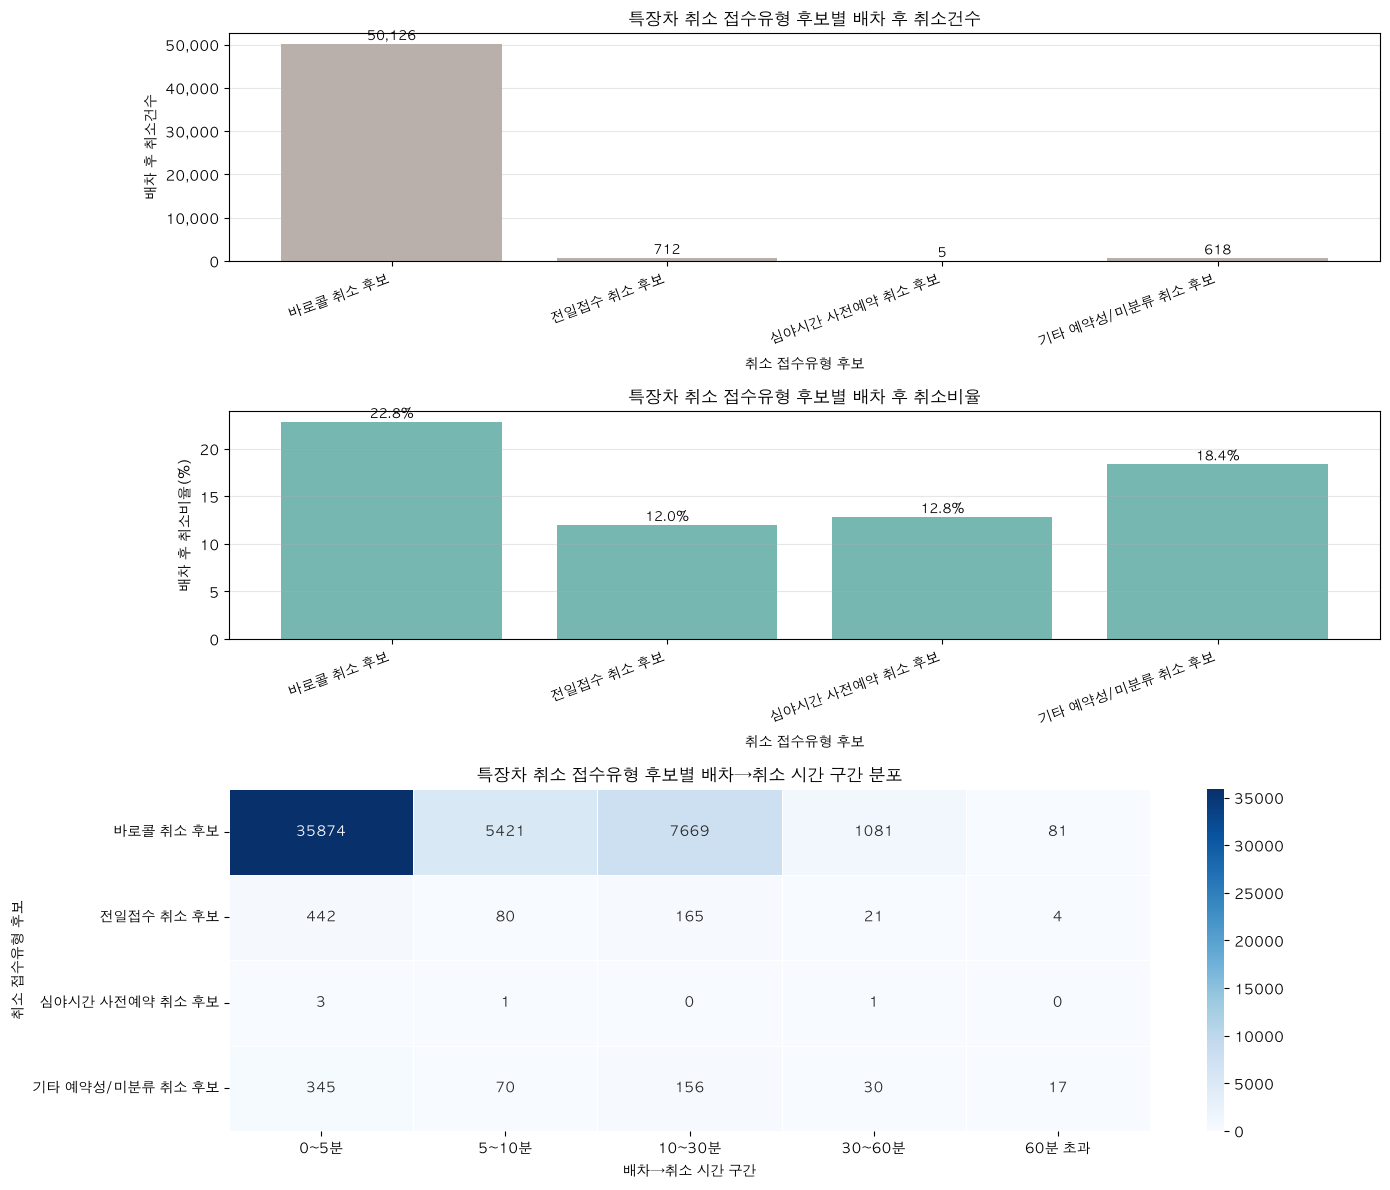

In [48]:
# 코드 셀 목적: 접수유형 후보별 배차 후 취소 규모와 배차→취소 시간 구간을 확인한다.
post_dispatch_cancel = special_cancel.copy()
post_dispatch_cancel["배차_취소_분"] = pd.to_numeric(post_dispatch_cancel["배차_취소_분"], errors="coerce")
post_dispatch_cancel = post_dispatch_cancel[post_dispatch_cancel["배차일시"].notna() & post_dispatch_cancel["배차_취소_분"].notna() & post_dispatch_cancel["배차_취소_분"].ge(0)].copy()

post_dispatch_bins = [0, 5, 10, 30, 60, float("inf")]
post_dispatch_labels = ["0~5분", "5~10분", "10~30분", "30~60분", "60분 초과"]
post_dispatch_cancel["배차_취소_구간"] = pd.cut(post_dispatch_cancel["배차_취소_분"], bins=post_dispatch_bins, labels=post_dispatch_labels, right=True, include_lowest=True)

post_dispatch_summary = special_cancel.groupby(cancel_type_col, observed=False).agg(취소건수=("취소일시", "count")).reindex(cancel_type_order).reset_index()
post_dispatch_counts = post_dispatch_cancel.groupby(cancel_type_col, observed=False).agg(배차후취소건수=("취소일시", "count"), 배차_취소_중앙값=("배차_취소_분", "median"), 배차_취소_75분위수=("배차_취소_분", lambda x: x.quantile(0.75)), 배차_취소_90분위수=("배차_취소_분", lambda x: x.quantile(0.90))).reindex(cancel_type_order).reset_index()
post_dispatch_summary = post_dispatch_summary.merge(post_dispatch_counts, on=cancel_type_col, how="left")
post_dispatch_summary["배차후취소건수"] = post_dispatch_summary["배차후취소건수"].fillna(0).astype(int)
post_dispatch_summary["배차후취소비율(%)"] = (post_dispatch_summary["배차후취소건수"] / post_dispatch_summary["취소건수"] * 100).round(2)
display(post_dispatch_summary)

post_dispatch_heatmap = post_dispatch_cancel.pivot_table(index=cancel_type_col, columns="배차_취소_구간", values="배차_취소_분", aggfunc="count", observed=False).reindex(index=cancel_type_order, columns=post_dispatch_labels).fillna(0)

fig = plt.figure(figsize=(14, 12))
grid = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1.5])
ax1 = fig.add_subplot(grid[0])
ax2 = fig.add_subplot(grid[1])
ax3 = fig.add_subplot(grid[2])
x = range(len(post_dispatch_summary))

ax1.bar(x, post_dispatch_summary["배차후취소건수"], color="#bab0ab")
ax1.set_title("특장차 취소 접수유형 후보별 배차 후 취소건수")
ax1.set_xlabel("취소 접수유형 후보")
ax1.set_ylabel("배차 후 취소건수")
ax1.set_xticks(list(x))
ax1.set_xticklabels(post_dispatch_summary[cancel_type_col], rotation=20, ha="right")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax1.grid(axis="y", alpha=0.3)
for idx, value in enumerate(post_dispatch_summary["배차후취소건수"]):
    ax1.text(idx, value, f"{value:,.0f}", ha="center", va="bottom", fontsize=9)

ax2.bar(x, post_dispatch_summary["배차후취소비율(%)"], color="#76b7b2")
ax2.set_title("특장차 취소 접수유형 후보별 배차 후 취소비율")
ax2.set_xlabel("취소 접수유형 후보")
ax2.set_ylabel("배차 후 취소비율(%)")
ax2.set_xticks(list(x))
ax2.set_xticklabels(post_dispatch_summary[cancel_type_col], rotation=20, ha="right")
ax2.grid(axis="y", alpha=0.3)
for idx, value in enumerate(post_dispatch_summary["배차후취소비율(%)"]):
    ax2.text(idx, value, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)

sns.heatmap(post_dispatch_heatmap, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5, ax=ax3)
ax3.set_title("특장차 취소 접수유형 후보별 배차→취소 시간 구간 분포")
ax3.set_xlabel("배차→취소 시간 구간")
ax3.set_ylabel("취소 접수유형 후보")
plt.tight_layout()
plt.show()

## 6-5. 바로콜 배차 후 취소 분석

바로콜 배차 후 취소는 차량이 배정된 이후 취소가 발생한 건이다.  
바로콜은 즉시 이용 구조이므로, 배차 후 취소를 볼 때는 `배차→취소`뿐 아니라 `접수→배차`까지 함께 봐야 한다.

특히 `배차→취소`가 짧은 건은 배차 직후 취소로 볼 수 있다.  
이 경우 이용자가 오래 기다리다가 배차 알림을 받은 뒤 취소했는지, 또는 배차 정보 확인 후 바로 취소했는지를 확인할 필요가 있다.

분석 관점은 다음과 같다.

```text
- 접수→배차: 배차되기 전까지 이용자가 기다린 시간
- 배차→취소: 차량이 배정된 뒤 취소까지 걸린 시간
- 접수→취소: 접수 후 최종적으로 취소하기까지 걸린 전체 시간
- 배차 직후 0~5분 취소: 차량 배정 직후 취소된 운영 부담 가능성이 큰 건

In [49]:
# 코드 셀 목적: 바로콜 배차 후 취소 분석용 데이터셋을 생성한다.

baro_dispatch_cancel = special_cancel_baro_call.copy()

for col in ["접수일시", "배차일시", "취소일시"]:
    baro_dispatch_cancel[col] = pd.to_datetime(baro_dispatch_cancel[col], errors="coerce")

for col in ["접수_배차_분", "배차_취소_분", "접수_취소_분"]:
    baro_dispatch_cancel[col] = pd.to_numeric(baro_dispatch_cancel[col], errors="coerce")

baro_dispatch_cancel = baro_dispatch_cancel[
    baro_dispatch_cancel["배차일시"].notna()
    & baro_dispatch_cancel["취소일시"].notna()
    & baro_dispatch_cancel["배차_취소_분"].ge(0)
].copy()

baro_dispatch_cancel["배차직후_0_5분_취소여부"] = (
    baro_dispatch_cancel["배차_취소_분"].between(0, 5, inclusive="both")
)

baro_dispatch_cancel["접수시간대_HH"] = baro_dispatch_cancel["접수일시"].dt.strftime("%H")
baro_dispatch_cancel["배차시간대_HH"] = baro_dispatch_cancel["배차일시"].dt.strftime("%H")

baro_dispatch_cancel_bins = [0, 5, 10, 30, 60, float("inf")]
baro_dispatch_cancel_labels = ["0~5분", "5~10분", "10~30분", "30~60분", "60분 초과"]

baro_dispatch_cancel["배차_취소_구간"] = pd.cut(
    baro_dispatch_cancel["배차_취소_분"],
    bins=baro_dispatch_cancel_bins,
    labels=baro_dispatch_cancel_labels,
    right=True,
    include_lowest=True,
)

print(f"바로콜 배차 후 취소 건수: {len(baro_dispatch_cancel):,}건")
display(baro_dispatch_cancel.head())

바로콜 배차 후 취소 건수: 50,126건


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,...,특장차_접수유형_후보_보완,정기접수_목적후보여부,정기접수_가능패턴여부,동일패턴건수_보완,예정_배차_분,예정_승차_분,특장차_접수유형_후보_최종,배차직후_0_5분_취소여부,배차시간대_HH,배차_취소_구간
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaT,NaT,2025-01-01 00:21:15,영등포구,여의동,강서구,화곡제6동,...,NaN,NaN,NaN,NaN,NaN,NaN,승차완료 외/분류대상 아님,False,00,5~10분
21,2025-01-01 00:34:44.870,2025-01-01 00:34:44.870,2025-01-01 01:12:18.430,NaT,NaT,2025-01-01 01:14:22,서초구,서초3동,노원구,중계2.3동,...,NaN,NaN,NaN,NaN,NaN,NaN,승차완료 외/분류대상 아님,True,01,0~5분
25,2025-01-01 00:38:17.000,2025-01-01 00:39:00.000,2025-01-01 01:19:08.310,NaT,NaT,2025-01-01 01:21:33,광진구,중곡제3동,동대문구,전농제3동,...,NaN,NaN,NaN,NaN,NaN,NaN,승차완료 외/분류대상 아님,True,01,0~5분
31,2025-01-01 00:52:22.000,2025-01-01 00:53:00.000,2025-01-01 01:17:30.120,NaT,NaT,2025-01-01 01:19:09,광진구,화양동,노원구,중계4동,...,NaN,NaN,NaN,NaN,NaN,NaN,승차완료 외/분류대상 아님,True,01,0~5분
34,2025-01-01 01:09:45.050,2025-01-01 01:10:00.000,2025-01-01 02:46:12.977,NaT,NaT,2025-01-01 02:57:01,종로구,이화동,종로구,혜화동,...,NaN,NaN,NaN,NaN,NaN,NaN,승차완료 외/분류대상 아님,False,02,10~30분


In [50]:
# 코드 셀 목적: 바로콜 배차 후 취소 건의 핵심 대기시간 요약표를 확인한다.

baro_dispatch_wait_summary = []

for col, label in [
    ("접수_배차_분", "접수→배차"),
    ("배차_취소_분", "배차→취소"),
    ("접수_취소_분", "접수→취소"),
]:
    values = baro_dispatch_cancel[col].dropna()
    baro_dispatch_wait_summary.append({
        "지표": label,
        "건수": values.count(),
        "평균": values.mean(),
        "중앙값": values.median(),
        "75분위수": values.quantile(0.75),
        "90분위수": values.quantile(0.90),
        "95분위수": values.quantile(0.95),
        "최소값": values.min(),
        "최대값": values.max(),
    })

baro_dispatch_wait_summary = pd.DataFrame(baro_dispatch_wait_summary)

baro_dispatch_0_5_summary = pd.DataFrame({
    "구분": [
        "바로콜 배차 후 취소 전체",
        "배차 직후 0~5분 취소",
        "배차 후 5분 초과 취소",
    ],
    "건수": [
        len(baro_dispatch_cancel),
        baro_dispatch_cancel["배차직후_0_5분_취소여부"].sum(),
        (~baro_dispatch_cancel["배차직후_0_5분_취소여부"]).sum(),
    ],
})
baro_dispatch_0_5_summary["비율(%)"] = (
    baro_dispatch_0_5_summary["건수"] / len(baro_dispatch_cancel) * 100
)

display(baro_dispatch_wait_summary)
display(baro_dispatch_0_5_summary)

,지표,건수,평균,중앙값,75분위수,90분위수,95분위수,최소값,최대값
0,접수→배차,50126,31.899041,12.980558,42.484417,95.051800,131.311083,0.293000,197.105900
1,배차→취소,50126,5.688053,2.513892,5.970571,14.357725,21.775013,0.009783,181.492333
2,접수→취소,50126,37.587094,20.566525,50.214875,103.625000,135.647537,0.507333,199.742383


,구분,건수,비율(%)
0,바로콜 배차 후 취소 전체,50126,100.00000
1,배차 직후 0~5분 취소,35874,71.56765
2,배차 후 5분 초과 취소,14252,28.43235


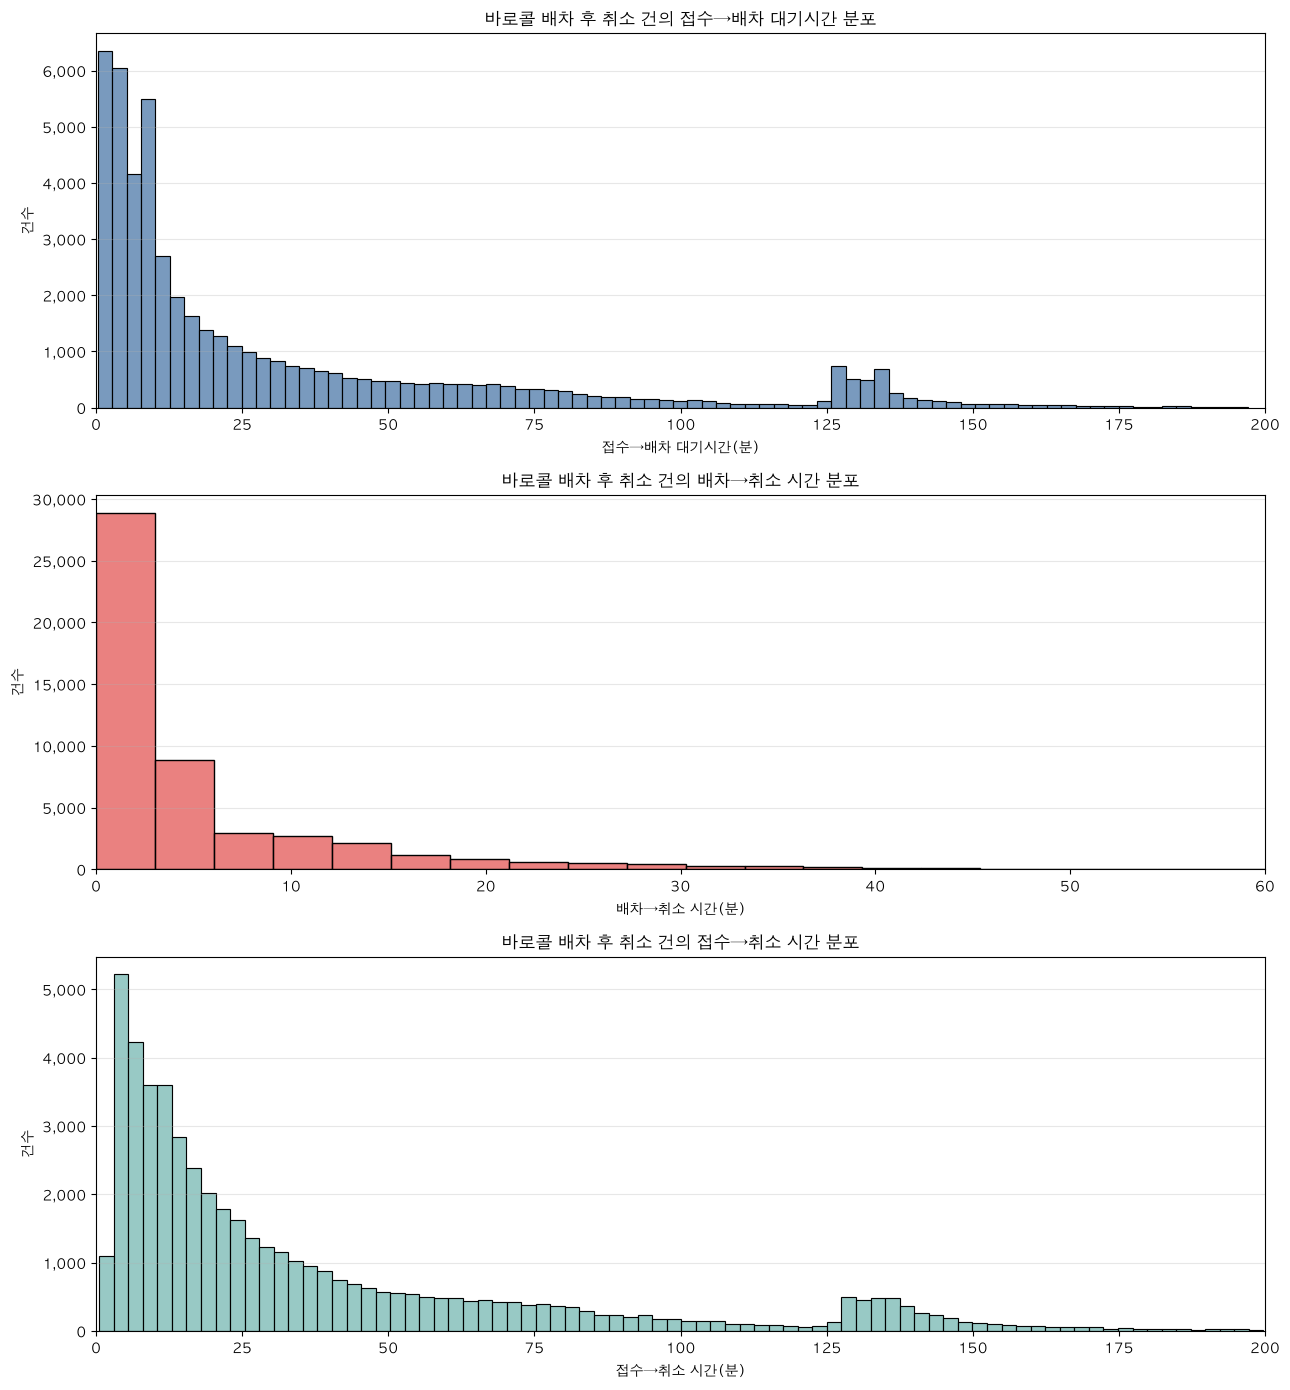

In [51]:
# 코드 셀 목적: 바로콜 배차 후 취소 건의 접수→배차, 배차→취소, 접수→취소 분포를 각각 확인한다.

fig, axes = plt.subplots(3, 1, figsize=(13, 14))

plot_specs = [
    ("접수_배차_분", "바로콜 배차 후 취소 건의 접수→배차 대기시간 분포", "접수→배차 대기시간(분)", "#4c78a8", 200, 80),
    ("배차_취소_분", "바로콜 배차 후 취소 건의 배차→취소 시간 분포", "배차→취소 시간(분)", "#e45756", 60, 60),
    ("접수_취소_분", "바로콜 배차 후 취소 건의 접수→취소 시간 분포", "접수→취소 시간(분)", "#76b7b2", 200, 80),
]

for ax, (col, title, xlabel, color, xlim_max, bins) in zip(axes, plot_specs):
    sns.histplot(
        data=baro_dispatch_cancel,
        x=col,
        bins=bins,
        color=color,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("건수")
    ax.set_xlim(0, xlim_max)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

,배차시간대_HH,배차후취소건수,배차직후_0_5분_취소건수,접수_배차_중앙값,배차_취소_중앙값,접수_취소_중앙값,배차직후_0_5분_취소비율(%)
0,00,138,86,13.203058,3.195583,25.370058,62.318841
1,01,96,45,13.800167,5.690250,26.416642,46.875000
2,02,72,33,11.306142,6.414917,22.791142,45.833333
3,03,60,33,8.935475,3.579275,19.541667,55.000000
4,04,166,111,84.738667,2.701975,91.034033,66.867470
5,05,236,165,8.506800,2.476692,16.271667,69.915254
6,06,23,15,9.567617,2.051717,16.450000,65.217391
7,07,3388,2650,23.488583,2.229867,30.353500,78.217237
8,08,4645,3569,26.096117,2.343883,31.560167,76.835307
9,09,4035,2866,23.486117,2.561050,30.389333,71.028501


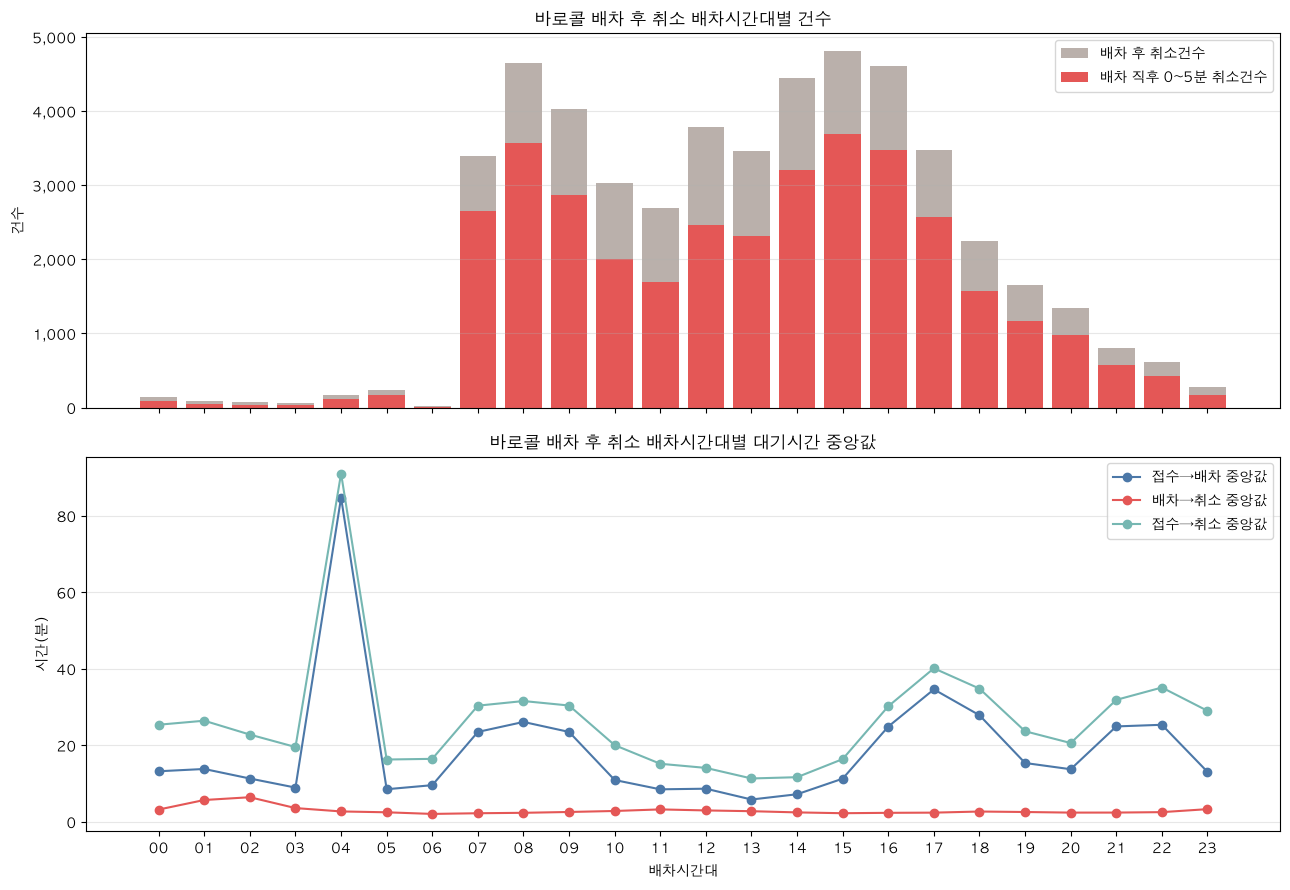

In [52]:
# 코드 셀 목적: 바로콜 배차 후 취소의 배차시간대별 건수와 대기시간 중앙값을 확인한다.

hour_order = [f"{hour:02d}" for hour in range(24)]

baro_dispatch_hour_summary = (
    baro_dispatch_cancel
    .groupby("배차시간대_HH", observed=False)
    .agg(
        배차후취소건수=("취소일시", "count"),
        배차직후_0_5분_취소건수=("배차직후_0_5분_취소여부", "sum"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        배차_취소_중앙값=("배차_취소_분", "median"),
        접수_취소_중앙값=("접수_취소_분", "median"),
    )
    .reindex(hour_order)
    .reset_index()
)

baro_dispatch_hour_summary["배차직후_0_5분_취소비율(%)"] = (
    baro_dispatch_hour_summary["배차직후_0_5분_취소건수"]
    / baro_dispatch_hour_summary["배차후취소건수"].replace(0, pd.NA)
    * 100
)

display(baro_dispatch_hour_summary)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

axes[0].bar(
    baro_dispatch_hour_summary["배차시간대_HH"],
    baro_dispatch_hour_summary["배차후취소건수"],
    color="#bab0ab",
    label="배차 후 취소건수",
)
axes[0].bar(
    baro_dispatch_hour_summary["배차시간대_HH"],
    baro_dispatch_hour_summary["배차직후_0_5분_취소건수"],
    color="#e45756",
    label="배차 직후 0~5분 취소건수",
)
axes[0].set_title("바로콜 배차 후 취소 배차시간대별 건수")
axes[0].set_ylabel("건수")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

axes[1].plot(
    baro_dispatch_hour_summary["배차시간대_HH"],
    baro_dispatch_hour_summary["접수_배차_중앙값"],
    marker="o",
    label="접수→배차 중앙값",
    color="#4c78a8",
)
axes[1].plot(
    baro_dispatch_hour_summary["배차시간대_HH"],
    baro_dispatch_hour_summary["배차_취소_중앙값"],
    marker="o",
    label="배차→취소 중앙값",
    color="#e45756",
)
axes[1].plot(
    baro_dispatch_hour_summary["배차시간대_HH"],
    baro_dispatch_hour_summary["접수_취소_중앙값"],
    marker="o",
    label="접수→취소 중앙값",
    color="#76b7b2",
)

axes[1].set_title("바로콜 배차 후 취소 배차시간대별 대기시간 중앙값")
axes[1].set_xlabel("배차시간대")
axes[1].set_ylabel("시간(분)")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

- 배차→취소가 짧기 때문에 접수→취소는 사실상 접수→배차에 의해 결정됨
- 취소까지 오래 걸린 건은 배차 후 오래 기다려서가 아니라 배차되기 전까지 이미 오래 기다린 건일 가능성이 큼

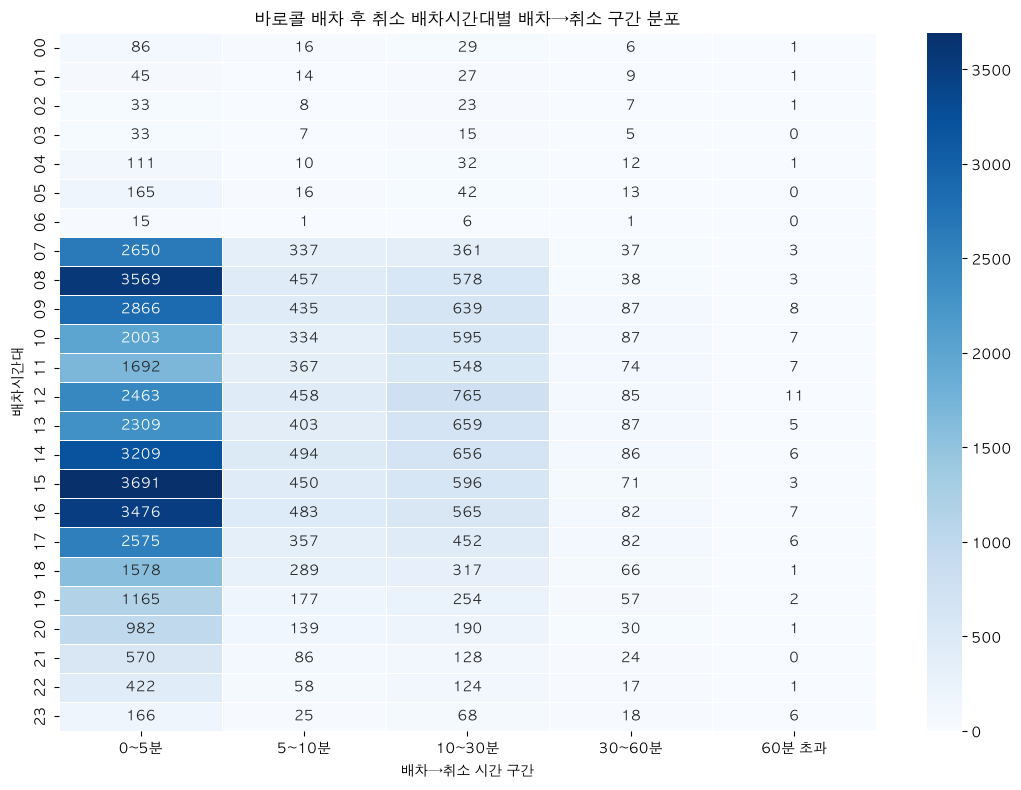

In [53]:
# 코드 셀 목적: 바로콜 배차 후 취소의 배차시간대별 배차→취소 구간 분포를 히트맵으로 확인한다.

baro_dispatch_heatmap = (
    baro_dispatch_cancel
    .pivot_table(
        index="배차시간대_HH",
        columns="배차_취소_구간",
        values="배차_취소_분",
        aggfunc="count",
        observed=False,
    )
    .reindex(index=hour_order, columns=baro_dispatch_cancel_labels)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(
    baro_dispatch_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax,
)

ax.set_title("바로콜 배차 후 취소 배차시간대별 배차→취소 구간 분포")
ax.set_xlabel("배차→취소 시간 구간")
ax.set_ylabel("배차시간대")

plt.tight_layout()
plt.show()

- 바로콜 배차 후 취소는 배차 후 장시간 대기하다 취소되는 구조는 아님

아래 코드는 그래프를 그리기 위한 셀이 아니라 배차 직후 취소가 특정 지역·이동유형에 집중되는지 확인하고, 접수→배차가 긴 뒤 배차 직후 취소된 실제 원자료를 확인하기 위한 진단용 표다.
- 접수→배차는 오래 걸렸는데 배차→취소는 매우 짧은 건

In [54]:
# 코드 셀 목적: 바로콜 배차 후 취소의 출발구·세부이동유형 상위와 원자료 예시를 확인한다.

region_cols = ["출발구", "세부이동유형"]
available_region_cols = [col for col in region_cols if col in baro_dispatch_cancel.columns]

if available_region_cols:
    baro_dispatch_region_summary = (
        baro_dispatch_cancel
        .groupby(available_region_cols, dropna=False, observed=False)
        .agg(
            배차후취소건수=("취소일시", "count"),
            배차직후_0_5분_취소건수=("배차직후_0_5분_취소여부", "sum"),
            접수_배차_중앙값=("접수_배차_분", "median"),
            배차_취소_중앙값=("배차_취소_분", "median"),
        )
        .reset_index()
    )
    baro_dispatch_region_summary["배차직후_0_5분_취소비율(%)"] = (
        baro_dispatch_region_summary["배차직후_0_5분_취소건수"]
        / baro_dispatch_region_summary["배차후취소건수"]
        * 100
    )
    baro_dispatch_region_summary = baro_dispatch_region_summary.sort_values(
        "배차후취소건수",
        ascending=False,
    )

    print("바로콜 배차 후 취소 출발구·세부이동유형 상위")
    display(baro_dispatch_region_summary.head(20))

review_cols = [
    "취소_접수유형_후보",
    "접수일시",
    "배차일시",
    "취소일시",
    "출발구",
    "출발동",
    "목적구",
    "목적동",
    "세부이동유형",
    "이용목적",
    "접수_배차_분",
    "배차_취소_분",
    "접수_취소_분",
]
review_cols = [col for col in review_cols if col in baro_dispatch_cancel.columns]

print("바로콜 배차 직후 0~5분 취소 원자료 예시")
display(
    baro_dispatch_cancel[baro_dispatch_cancel["배차직후_0_5분_취소여부"]]
    .sort_values(["접수_배차_분", "배차_취소_분"], ascending=[False, True])
    [review_cols]
    .head()
)

바로콜 배차 후 취소 출발구·세부이동유형 상위


,출발구,세부이동유형,배차후취소건수,배차직후_0_5분_취소건수,접수_배차_중앙값,배차_취소_중앙값,배차직후_0_5분_취소비율(%)
48,서대문구,구 간 이동,1750,1273,10.856442,2.449000,72.742857
33,노원구,구 내 이동,1733,1214,9.723833,2.647833,70.051933
44,마포구,구 간 이동,1696,1303,15.789800,2.227500,76.827830
0,강남구,구 간 이동,1584,1120,14.873583,2.491833,70.707071
82,종로구,구 간 이동,1574,1084,14.525833,2.705558,68.869123
78,은평구,구 내 이동,1551,1194,10.415267,2.147833,76.982592
71,영등포구,구 간 이동,1469,1058,11.977000,2.534167,72.021784
10,강서구,구 내 이동,1451,1002,10.652117,2.624550,69.055824
9,강서구,구 간 이동,1374,984,11.060025,2.565142,71.615721
77,은평구,구 간 이동,1316,970,12.966442,2.381833,73.708207


바로콜 배차 직후 0~5분 취소 원자료 예시


,취소_접수유형_후보,접수일시,배차일시,취소일시,출발구,출발동,목적구,목적동,세부이동유형,이용목적,접수_배차_분,배차_취소_분,접수_취소_분
742812,바로콜 취소 후보,2025-07-16 15:25:00.773,2025-07-16 18:42:07.127,2025-07-16 18:44:13,영등포구,여의동,강동구,암사제1동,구 간 이동,귀가,197.105900,2.097883,199.203783
329398,바로콜 취소 후보,2025-04-01 13:35:00.667,2025-04-01 16:51:41.570,2025-04-01 16:54:31,서초구,서초4동,강남구,논현1동,구 간 이동,귀가,196.681717,2.823833,199.505550
580227,바로콜 취소 후보,2025-06-05 06:15:00.457,2025-06-05 09:31:34.670,2025-06-05 09:34:45,구로구,개봉제3동,구로구,개봉제1동,구 내 이동,재활,196.570217,3.172167,199.742383
607876,바로콜 취소 후보,2025-06-12 13:35:00.307,2025-06-12 16:51:32.730,2025-06-12 16:53:30,서초구,서초4동,강남구,논현1동,구 간 이동,귀가,196.540383,1.954500,198.494883
598575,바로콜 취소 후보,2025-06-10 13:35:00.050,2025-06-10 16:51:23.937,2025-06-10 16:53:27,동대문구,제기제1동,강북구,번제2동,구 간 이동,재활,196.398117,2.051050,198.449167


## 6-6. 바로콜 배차 후 취소: 접수→배차 대기시간과 배차 직후 취소 관계

바로콜 배차 후 취소는 단순히 배차 이후에 취소됐다는 사실만으로는 원인을 해석하기 어렵다.  
특히 앞선 분석에서 `배차→취소` 시간이 대부분 0~5분에 몰려 있었기 때문에, 배차 후 오래 기다리다가 취소했다기보다는 **배차 직후 취소** 패턴이 강하게 나타났다.

따라서 여기서는 `접수→배차` 대기시간과 `배차→취소` 시간을 함께 묶어서 확인한다.

분석 목적은 다음 질문을 확인하는 것이다.

```text
배차 직후 취소가 단순히 배차 정보 확인 후 취소인지,
아니면 접수→배차가 오래 걸린 뒤 배차되자마자 취소된 것인지

특히 다음 구간을 중점적으로 확인한다.
- 접수→배차 30분 이상 + 배차→취소 0~5분
- 접수→배차 60분 이상 + 배차→취소 0~5분
- 접수→배차 90분 이상 + 배차→취소 0~5분

,조건,대상건수,배차직후_0~5분_취소건수,배차직후_0~5분_취소비율(%)
0,접수→배차 30분 이상,16104,11245,69.827372
1,접수→배차 60분 이상,9275,6472,69.778976
2,접수→배차 90분 이상,5343,3815,71.401834


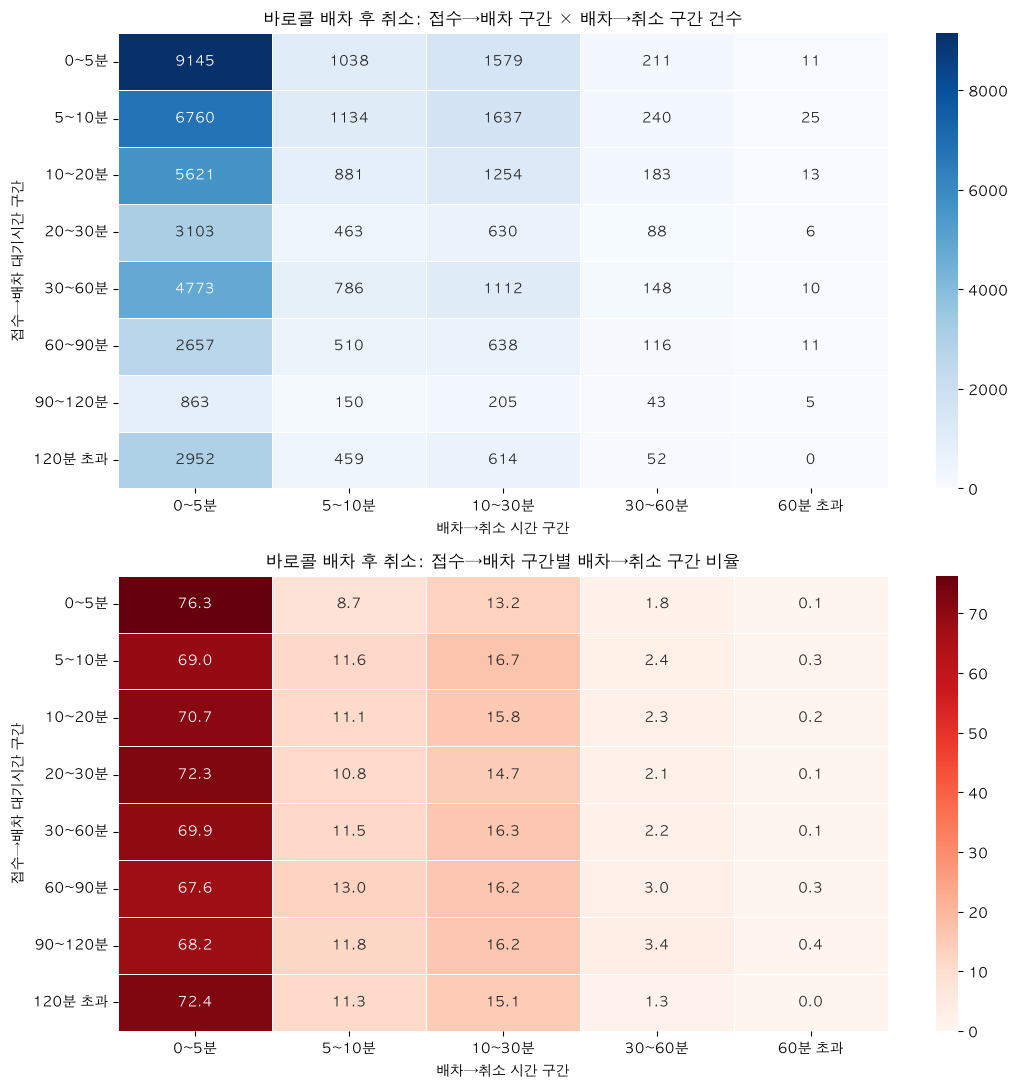

In [55]:
# 코드 셀 목적: 바로콜 배차 후 취소에서 접수→배차 대기시간과 배차→취소 시간의 관계를 확인한다.

baro_dispatch_cancel_relation = baro_dispatch_cancel.copy()

baro_dispatch_cancel_relation["접수_배차_분"] = pd.to_numeric(
    baro_dispatch_cancel_relation["접수_배차_분"],
    errors="coerce",
)
baro_dispatch_cancel_relation["배차_취소_분"] = pd.to_numeric(
    baro_dispatch_cancel_relation["배차_취소_분"],
    errors="coerce",
)

baro_dispatch_cancel_relation = baro_dispatch_cancel_relation[
    baro_dispatch_cancel_relation["접수_배차_분"].notna()
    & baro_dispatch_cancel_relation["배차_취소_분"].notna()
    & baro_dispatch_cancel_relation["접수_배차_분"].ge(0)
    & baro_dispatch_cancel_relation["배차_취소_분"].ge(0)
].copy()

request_dispatch_bins = [0, 5, 10, 20, 30, 60, 90, 120, float("inf")]
request_dispatch_labels = [
    "0~5분",
    "5~10분",
    "10~20분",
    "20~30분",
    "30~60분",
    "60~90분",
    "90~120분",
    "120분 초과",
]

dispatch_cancel_bins = [0, 5, 10, 30, 60, float("inf")]
dispatch_cancel_labels = [
    "0~5분",
    "5~10분",
    "10~30분",
    "30~60분",
    "60분 초과",
]

baro_dispatch_cancel_relation["접수_배차_구간"] = pd.cut(
    baro_dispatch_cancel_relation["접수_배차_분"],
    bins=request_dispatch_bins,
    labels=request_dispatch_labels,
    right=True,
    include_lowest=True,
)

baro_dispatch_cancel_relation["배차_취소_구간"] = pd.cut(
    baro_dispatch_cancel_relation["배차_취소_분"],
    bins=dispatch_cancel_bins,
    labels=dispatch_cancel_labels,
    right=True,
    include_lowest=True,
)

relation_heatmap_count = (
    baro_dispatch_cancel_relation
    .pivot_table(
        index="접수_배차_구간",
        columns="배차_취소_구간",
        values="취소일시",
        aggfunc="count",
        observed=False,
    )
    .reindex(index=request_dispatch_labels, columns=dispatch_cancel_labels)
    .fillna(0)
)

relation_heatmap_ratio = (
    relation_heatmap_count
    .div(relation_heatmap_count.sum(axis=1).replace(0, pd.NA), axis=0)
    * 100
)

long_wait_cutoffs = [30, 60, 90]
long_wait_0_5_summary = []

for cutoff in long_wait_cutoffs:
    base_mask = baro_dispatch_cancel_relation["접수_배차_분"].ge(cutoff)
    quick_cancel_mask = base_mask & baro_dispatch_cancel_relation["배차_취소_분"].between(
        0,
        5,
        inclusive="both",
    )
    long_wait_0_5_summary.append({
        "조건": f"접수→배차 {cutoff}분 이상",
        "대상건수": base_mask.sum(),
        "배차직후_0~5분_취소건수": quick_cancel_mask.sum(),
        "배차직후_0~5분_취소비율(%)": (
            quick_cancel_mask.sum() / base_mask.sum() * 100
            if base_mask.sum() > 0
            else pd.NA
        ),
    })

long_wait_0_5_summary = pd.DataFrame(long_wait_0_5_summary)

display(long_wait_0_5_summary)

fig, axes = plt.subplots(2, 1, figsize=(11, 11))

sns.heatmap(
    relation_heatmap_count,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title("바로콜 배차 후 취소: 접수→배차 구간 × 배차→취소 구간 건수")
axes[0].set_xlabel("배차→취소 시간 구간")
axes[0].set_ylabel("접수→배차 대기시간 구간")

sns.heatmap(
    relation_heatmap_ratio,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("바로콜 배차 후 취소: 접수→배차 구간별 배차→취소 구간 비율")
axes[1].set_xlabel("배차→취소 시간 구간")
axes[1].set_ylabel("접수→배차 대기시간 구간")

plt.tight_layout()
plt.show()

#### 1. 건수 히트맵 — 주요 구간

| 접수→배차 구간 | 배차→취소 구간 | 건수 |
|---|---|---|
| 0~5분 | 0~5분 | 9,145건 |
| 5~10분 | 0~5분 | 6,760건 |
| 10~20분 | 0~5분 | 5,621건 |
| 30~60분 | 0~5분 | 4,773건 |
| 120분 초과 | 0~5분 | 2,952건 |

> 배차가 빠르게 된 건에서도, 오래 걸린 건에서도 배차 직후(0~5분) 취소가 공통적으로 많이 발생함


#### 2. 비율 히트맵 — 접수→배차 구간별 "배차→취소 0~5분" 비율

| 접수→배차 구간 | 배차→취소 0~5분 비율 |
|---|---|
| 0~5분 | 76.3% |
| 20~30분 | 72.3% |
| 60~90분 | 67.6% |
| 120분 초과 | 72.4% |

> 접수→배차 구간과 무관하게 대부분 67~76% 수준에서 배차 직후 취소가 발생함

```text
=> 배차 직후 취소는 장시간 대기자에게만 나타나는 현상이 아님, 바로콜 배차 후 취소 전반의 공통 패턴임
장시간 접수→배차 후에도 배차 직후 취소가 상당히 존재하므로 “오래 기다리다가 배차되자마자 취소” 패턴도 운영상 중요하게 볼 필요가 있음

## 6-7. 전일접수 배차 후 취소 분석

전일접수 배차 후 취소는 예약성 접수이므로 바로콜처럼 `접수→배차`를 핵심으로 보기 어렵다. 전일접수는 전날 접수되고 실제 이용은 `예정일시`를 기준으로 발생하므로, 배차 후 취소도 **예정시각 대비 배차·취소 시점**을 함께 확인해야 한다.

분석 관점은 다음과 같다.

```text
예정대비 배차 : 배차가 예정시각보다 얼마나 먼저 또는 늦게 이루어졌는지
배차→취소 : 차량이 배정된 뒤 취소까지 걸린 시간
예정대비 취소 : 취소가 예정시각보다 얼마나 전에 또는 후에 발생했는지
배차 직후 0~5분 취소 : 차량 배정 직후 취소된 운영 부담 가능성이 큰 건

음수: 예정시각보다 먼저 배차
0: 예정시각에 배차
양수: 예정시각보다 늦게 배차
```

따라서 전일접수 배차 후 취소는 **배차 후 취소 여부만이 아니라 예정시각 임박 배차인지, 그리고 배차 직후 취소인지**를 같이 봐야 한다.

전일접수 배차 후 취소 건수: 712건


,지표,건수,평균,중앙값,75분위수,90분위수,95분위수,최소값,최대값
0,예정대비 배차,712,1.436750,5.349642,9.297329,13.536057,27.738267,-1435.208950,127.158167
1,배차→취소,712,9.976054,3.332133,10.899775,18.133467,26.096387,0.191550,1245.082167
2,예정대비 취소,712,11.412804,11.041667,18.687500,32.030000,41.521667,-1431.616667,230.033333


,구분,건수,비율(%)
0,전일접수 배차 후 취소 전체,712,100.000000
1,배차 직후 0~5분 취소,442,62.078652
2,배차 후 5분 초과 취소,270,37.921348


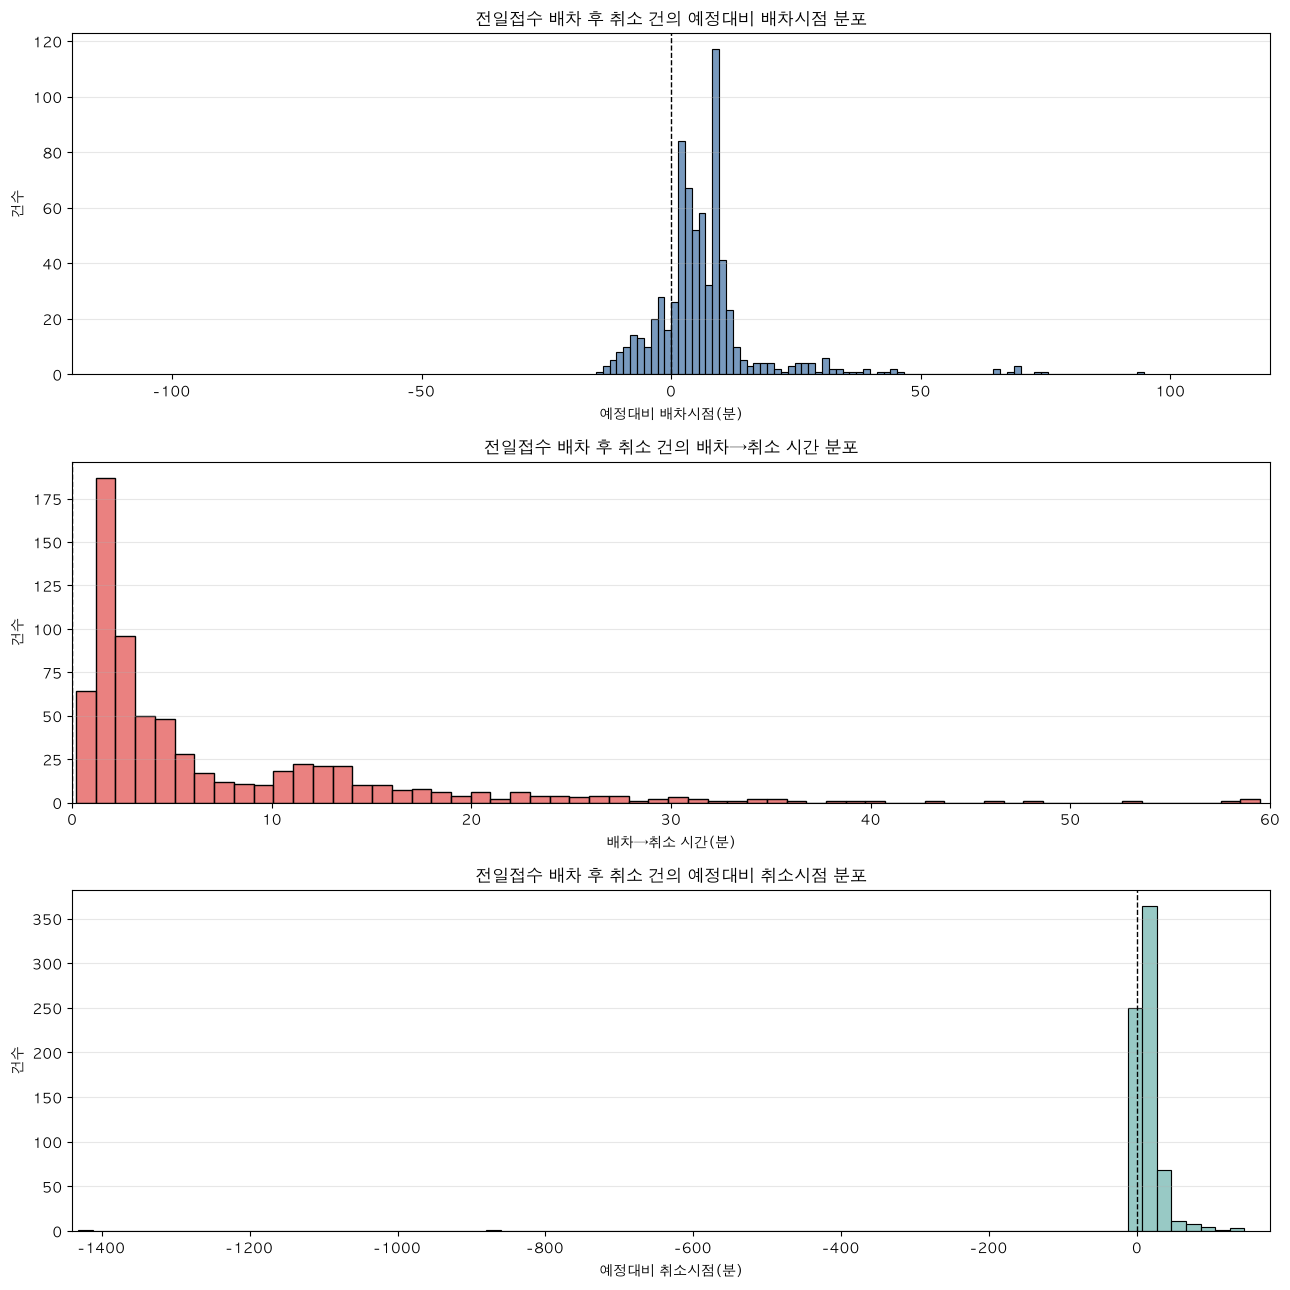

In [56]:
# 코드 셀 목적: 전일접수 배차 후 취소 분석용 데이터셋과 핵심 요약을 생성한다.
previous_day_dispatch_cancel = special_cancel_previous_day.copy()

for col in ["예정일시", "배차일시", "취소일시"]:
    previous_day_dispatch_cancel[col] = pd.to_datetime(previous_day_dispatch_cancel[col], errors="coerce")

for col in ["접수_취소_분", "배차_취소_분"]:
    previous_day_dispatch_cancel[col] = pd.to_numeric(previous_day_dispatch_cancel[col], errors="coerce")

previous_day_dispatch_cancel = previous_day_dispatch_cancel[
    previous_day_dispatch_cancel["예정일시"].notna()
    & previous_day_dispatch_cancel["배차일시"].notna()
    & previous_day_dispatch_cancel["취소일시"].notna()
    & previous_day_dispatch_cancel["배차_취소_분"].ge(0)
].copy()

previous_day_dispatch_cancel["예정대비_배차_분"] = (
    previous_day_dispatch_cancel["배차일시"] - previous_day_dispatch_cancel["예정일시"]
).dt.total_seconds() / 60
previous_day_dispatch_cancel["예정대비_취소_분"] = (
    previous_day_dispatch_cancel["취소일시"] - previous_day_dispatch_cancel["예정일시"]
).dt.total_seconds() / 60
previous_day_dispatch_cancel["배차직후_0_5분_취소여부"] = previous_day_dispatch_cancel["배차_취소_분"].between(0, 5, inclusive="both")
previous_day_dispatch_cancel["예정시간대_HH"] = previous_day_dispatch_cancel["예정일시"].dt.strftime("%H")
previous_day_dispatch_cancel["배차시간대_HH"] = previous_day_dispatch_cancel["배차일시"].dt.strftime("%H")

previous_day_dispatch_wait_summary = []
for col, label in [
    ("예정대비_배차_분", "예정대비 배차"),
    ("배차_취소_분", "배차→취소"),
    ("예정대비_취소_분", "예정대비 취소"),
]:
    values = previous_day_dispatch_cancel[col].dropna()
    previous_day_dispatch_wait_summary.append({
        "지표": label,
        "건수": values.count(),
        "평균": values.mean(),
        "중앙값": values.median(),
        "75분위수": values.quantile(0.75),
        "90분위수": values.quantile(0.90),
        "95분위수": values.quantile(0.95),
        "최소값": values.min(),
        "최대값": values.max(),
    })
previous_day_dispatch_wait_summary = pd.DataFrame(previous_day_dispatch_wait_summary)

previous_day_dispatch_0_5_summary = pd.DataFrame({
    "구분": ["전일접수 배차 후 취소 전체", "배차 직후 0~5분 취소", "배차 후 5분 초과 취소"],
    "건수": [
        len(previous_day_dispatch_cancel),
        previous_day_dispatch_cancel["배차직후_0_5분_취소여부"].sum(),
        (~previous_day_dispatch_cancel["배차직후_0_5분_취소여부"]).sum(),
    ],
})
previous_day_dispatch_0_5_summary["비율(%)"] = (
    previous_day_dispatch_0_5_summary["건수"] / len(previous_day_dispatch_cancel) * 100
)

print(f"전일접수 배차 후 취소 건수: {len(previous_day_dispatch_cancel):,}건")
display(previous_day_dispatch_wait_summary)
display(previous_day_dispatch_0_5_summary)

fig, axes = plt.subplots(3, 1, figsize=(13, 13))
plot_specs = [
    ("예정대비_배차_분", "전일접수 배차 후 취소 건의 예정대비 배차시점 분포", "예정대비 배차시점(분)", "#4c78a8", -120, 120, 80),
    ("배차_취소_분", "전일접수 배차 후 취소 건의 배차→취소 시간 분포", "배차→취소 시간(분)", "#e45756", 0, 60, 60),
    ("예정대비_취소_분", "전일접수 배차 후 취소 건의 예정대비 취소시점 분포", "예정대비 취소시점(분)", "#76b7b2", -1440, 180, 80),
]

for ax, (col, title, xlabel, color, xlim_min, xlim_max, bins) in zip(axes, plot_specs):
    plot_data = previous_day_dispatch_cancel[col].dropna()
    plot_data = plot_data[plot_data.between(xlim_min, xlim_max)]
    sns.histplot(plot_data, bins=bins, color=color, ax=ax)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("건수")
    ax.set_xlim(xlim_min, xlim_max)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

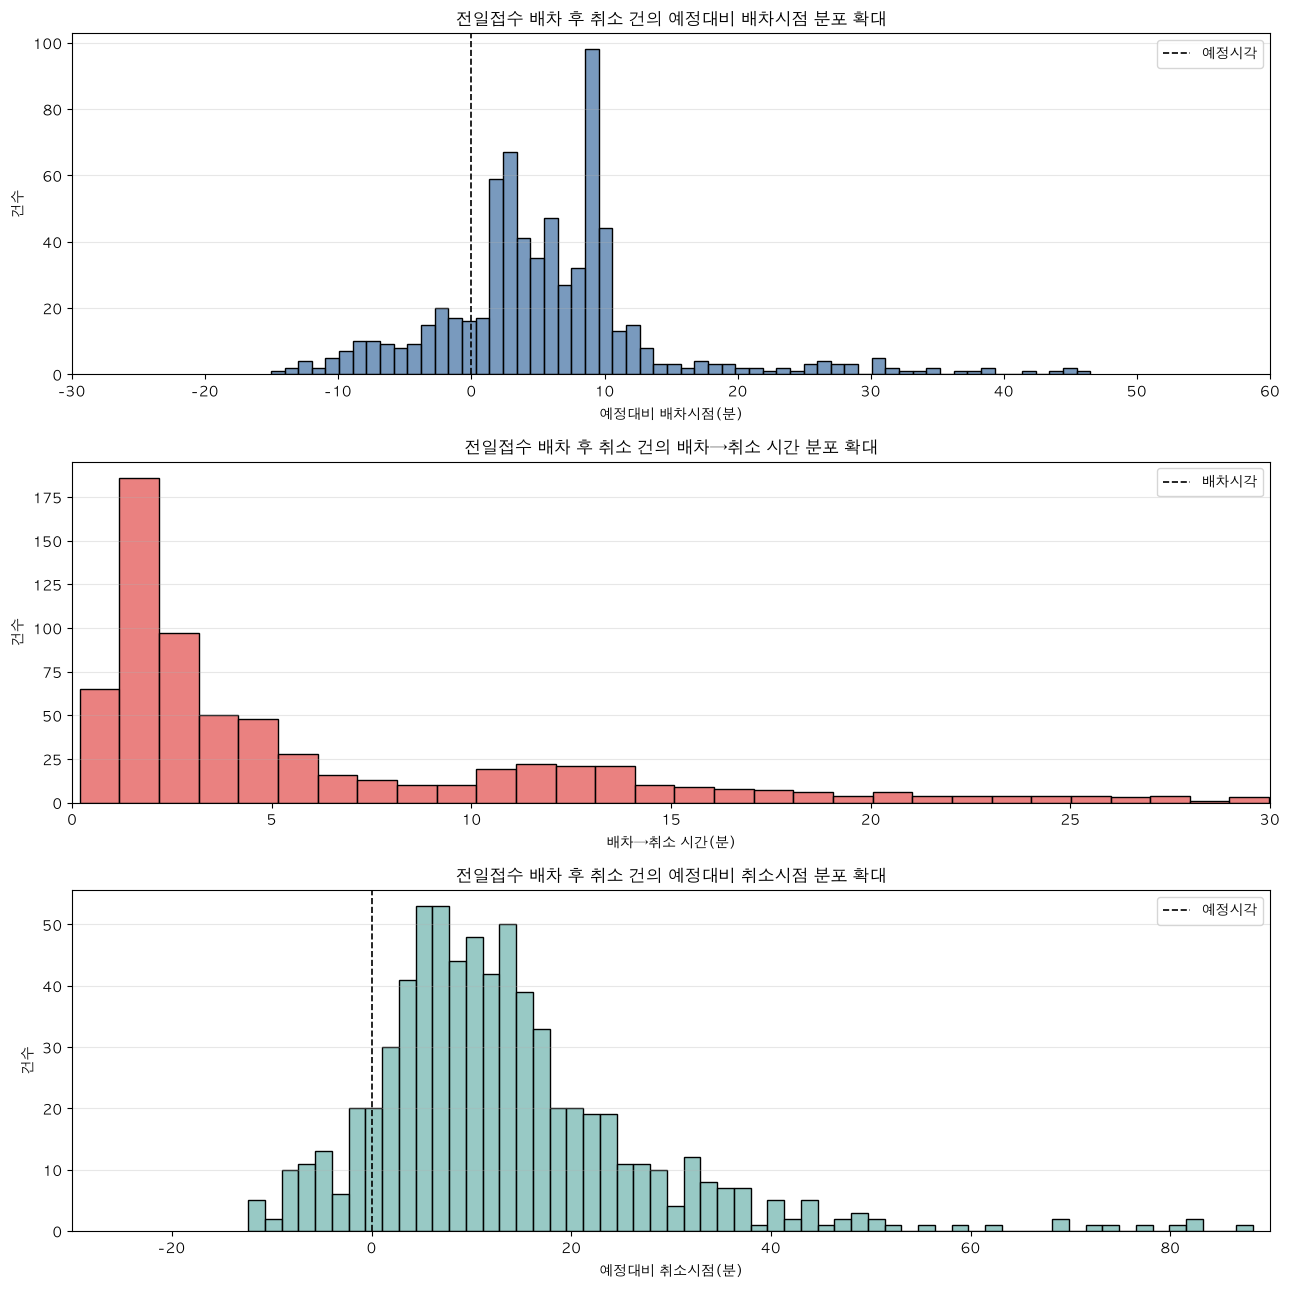

In [57]:
# 코드 셀 목적: 전일접수 배차 후 취소 건의 주요 시간 분포를 각 지표 분포에 맞게 확대해 확인한다.

fig, axes = plt.subplots(3, 1, figsize=(13, 13))

plot_specs = [
    {
        "col": "예정대비_배차_분",
        "title": "전일접수 배차 후 취소 건의 예정대비 배차시점 분포 확대",
        "xlabel": "예정대비 배차시점(분)",
        "color": "#4c78a8",
        "xlim": (-30, 60),
        "bins": 60,
        "zero_label": "예정시각",
    },
    {
        "col": "배차_취소_분",
        "title": "전일접수 배차 후 취소 건의 배차→취소 시간 분포 확대",
        "xlabel": "배차→취소 시간(분)",
        "color": "#e45756",
        "xlim": (0, 30),
        "bins": 30,
        "zero_label": "배차시각",
    },
    {
        "col": "예정대비_취소_분",
        "title": "전일접수 배차 후 취소 건의 예정대비 취소시점 분포 확대",
        "xlabel": "예정대비 취소시점(분)",
        "color": "#76b7b2",
        "xlim": (-30, 90),
        "bins": 60,
        "zero_label": "예정시각",
    },
]

for ax, spec in zip(axes, plot_specs):
    values = previous_day_dispatch_cancel[spec["col"]].dropna()
    values = values[values.between(spec["xlim"][0], spec["xlim"][1])]

    sns.histplot(
        values,
        bins=spec["bins"],
        color=spec["color"],
        ax=ax,
    )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=spec["zero_label"],
    )

    ax.set_title(spec["title"])
    ax.set_xlabel(spec["xlabel"])
    ax.set_ylabel("건수")
    ax.set_xlim(spec["xlim"])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

- 전일접수 배차 후 취소 건은 대부분 예정시각 이후에 배차
- 전일접수 배차 후 취소가 배차 후 오래 기다리다가 취소된 것이라기보다 배차가 된 직후 빠르게 취소된 패턴
- 취소가 예정시각 이후에 발생한 경우가 많다
=> 예정시각보다 늦게 배차 → 배차 직후 0~5분 내 취소

## 6-8. 전일접수 배차 후 취소: 예정대비 배차시점과 배차 직후 취소 관계

전일접수 배차 후 취소에서는 `접수→배차`보다 `예정대비_배차_분`이 더 중요한 기준이다. 예약성 접수에서는 접수일시가 전날이므로, 접수 후 시간이 길다는 사실보다 **예정시각에 가까워진 뒤 배차되었는지**가 운영 부담과 더 직접적으로 연결된다.

여기서는 `예정대비 배차시점`과 `배차→취소` 시간을 교차해서 본다.

```text
예정대비 배차시점이 0보다 작음:
예정시각보다 먼저 배차

예정대비 배차시점이 0보다 큼:
예정시각보다 늦게 배차

배차→취소 0~5분:
배차 직후 취소
```

특히 `예정 30분 전~예정 이후 배차`와 `배차→취소 0~5분`이 함께 나타나는 구간은 예정시각에 임박해 차량이 배정된 직후 취소된 건으로 볼 수 있다.

,조건,대상건수,배차직후_0~5분_취소건수,배차직후_0~5분_취소비율(%)
0,예정시각 기준 -30분 이후 배차,709,441,62.20
1,예정시각 이후 배차,581,341,58.69
2,예정시각 기준 +10분 이후 배차,121,73,60.33


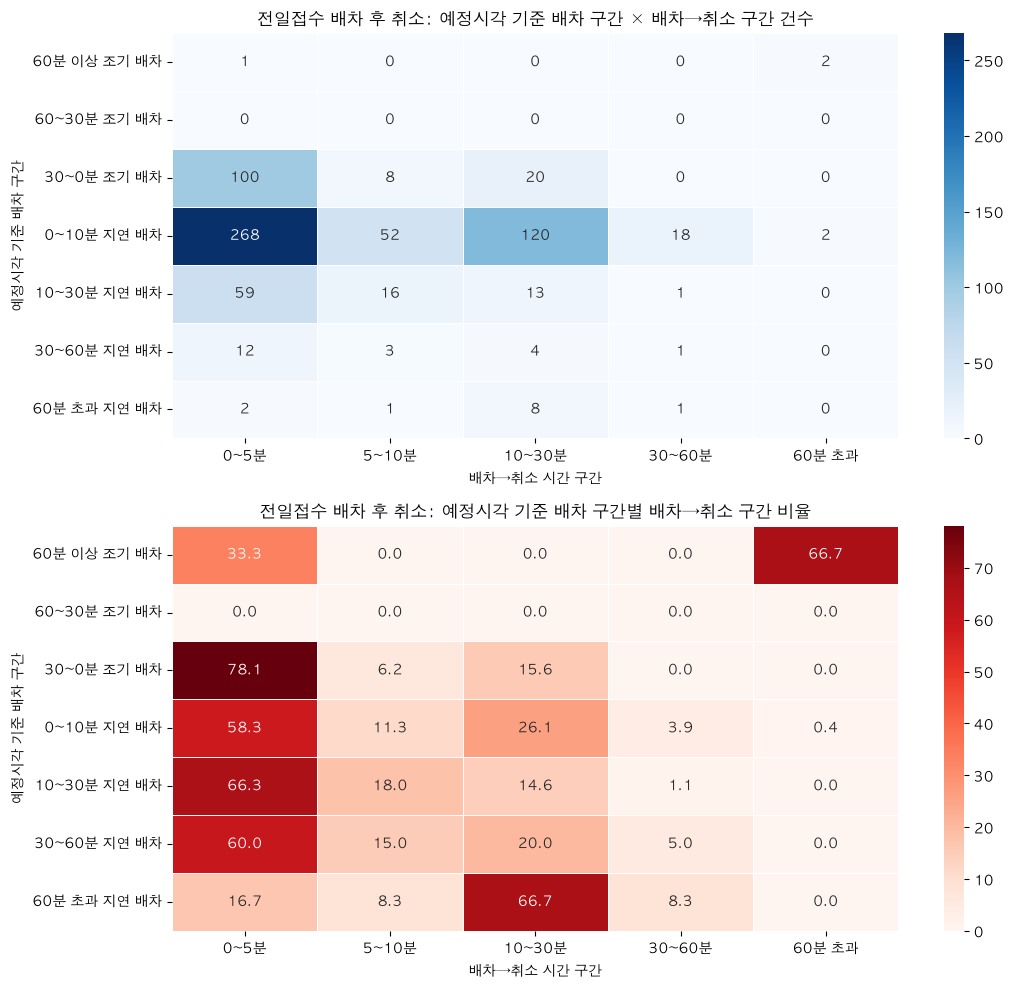

In [58]:
# 코드 셀 목적: 전일접수 배차 후 취소에서 예정대비 배차시점과 배차→취소 시간의 관계를 확인한다.

previous_day_dispatch_relation = previous_day_dispatch_cancel.copy()

schedule_dispatch_bins = [-float("inf"), -60, -30, 0, 10, 30, 60, float("inf")]
schedule_dispatch_labels = [
    "60분 이상 조기 배차",
    "60~30분 조기 배차",
    "30~0분 조기 배차",
    "0~10분 지연 배차",
    "10~30분 지연 배차",
    "30~60분 지연 배차",
    "60분 초과 지연 배차",
]

dispatch_cancel_bins = [0, 5, 10, 30, 60, float("inf")]
dispatch_cancel_labels = ["0~5분", "5~10분", "10~30분", "30~60분", "60분 초과"]

previous_day_dispatch_relation["예정대비_배차_구간"] = pd.cut(
    previous_day_dispatch_relation["예정대비_배차_분"],
    bins=schedule_dispatch_bins,
    labels=schedule_dispatch_labels,
    right=True,
    include_lowest=True,
)

previous_day_dispatch_relation["배차_취소_구간"] = pd.cut(
    previous_day_dispatch_relation["배차_취소_분"],
    bins=dispatch_cancel_bins,
    labels=dispatch_cancel_labels,
    right=True,
    include_lowest=True,
)

previous_day_relation_count = (
    previous_day_dispatch_relation
    .pivot_table(
        index="예정대비_배차_구간",
        columns="배차_취소_구간",
        values="취소일시",
        aggfunc="count",
        observed=False,
    )
    .reindex(index=schedule_dispatch_labels, columns=dispatch_cancel_labels)
    .fillna(0)
    .astype(float)
)

previous_day_relation_ratio = (
    previous_day_relation_count
    .div(previous_day_relation_count.sum(axis=1).replace(0, pd.NA), axis=0)
    * 100
)

previous_day_relation_ratio = (
    previous_day_relation_ratio
    .replace({pd.NA: 0})
    .fillna(0)
    .astype(float)
)

focus_masks = []

for label, lower in [
    ("예정시각 기준 -30분 이후 배차", -30),
    ("예정시각 이후 배차", 0),
    ("예정시각 기준 +10분 이후 배차", 10),
]:
    base_mask = previous_day_dispatch_relation["예정대비_배차_분"].ge(lower)
    quick_mask = (
        base_mask
        & previous_day_dispatch_relation["배차_취소_분"].between(0, 5, inclusive="both")
    )

    focus_masks.append({
        "조건": label,
        "대상건수": base_mask.sum(),
        "배차직후_0~5분_취소건수": quick_mask.sum(),
        "배차직후_0~5분_취소비율(%)": (
            quick_mask.sum() / base_mask.sum() * 100
            if base_mask.sum() > 0
            else pd.NA
        ),
    })

focus_summary = pd.DataFrame(focus_masks)
focus_summary["배차직후_0~5분_취소비율(%)"] = (
    pd.to_numeric(focus_summary["배차직후_0~5분_취소비율(%)"], errors="coerce")
    .round(2)
)

display(focus_summary)

fig, axes = plt.subplots(2, 1, figsize=(11, 10))

sns.heatmap(
    previous_day_relation_count,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=axes[0],
)

axes[0].set_title("전일접수 배차 후 취소: 예정시각 기준 배차 구간 × 배차→취소 구간 건수")
axes[0].set_xlabel("배차→취소 시간 구간")
axes[0].set_ylabel("예정시각 기준 배차 구간")

sns.heatmap(
    previous_day_relation_ratio,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    ax=axes[1],
)

axes[1].set_title("전일접수 배차 후 취소: 예정시각 기준 배차 구간별 배차→취소 구간 비율")
axes[1].set_xlabel("배차→취소 시간 구간")
axes[1].set_ylabel("예정시각 기준 배차 구간")

plt.tight_layout()
plt.show()

가장 많이 몰린 구간 
```text
예정대비 배차 0~10분 후 + 배차→취소 0~5분: 268건
예정대비 배차 0~10분 후 + 배차→취소 10~30분: 120건
예정대비 배차 30~0분 전 + 배차→취소 0~5분: 100건

## 6-9. 심야시간 사전예약 배차 후 취소 분석

심야시간 사전예약 배차 후 취소도 예약성 접수이므로 `예정일시` 기준으로 해석한다. 다만 심야시간 사전예약 취소 후보는 건수가 작을 수 있으므로, 분석 결과는 일반화보다 패턴 확인에 가깝게 본다.

분석 관점은 전일접수와 동일하다.

```text
예정대비 배차:
심야 예약 차량이 예정시각보다 얼마나 먼저 또는 늦게 배차되었는지

배차→취소:
차량 배정 뒤 취소까지 걸린 시간

예정대비 취소:
취소가 예정시각보다 얼마나 전에 또는 후에 발생했는지

배차 직후 0~5분 취소:
배차 알림 또는 배차 정보 확인 직후 취소 가능성이 있는 건
```

단, 표본 수가 작으면 시간대별·구간별 수치 하나하나를 과도하게 해석하지 않는다.

심야시간 사전예약 배차 후 취소 데이터 재생성: 5건


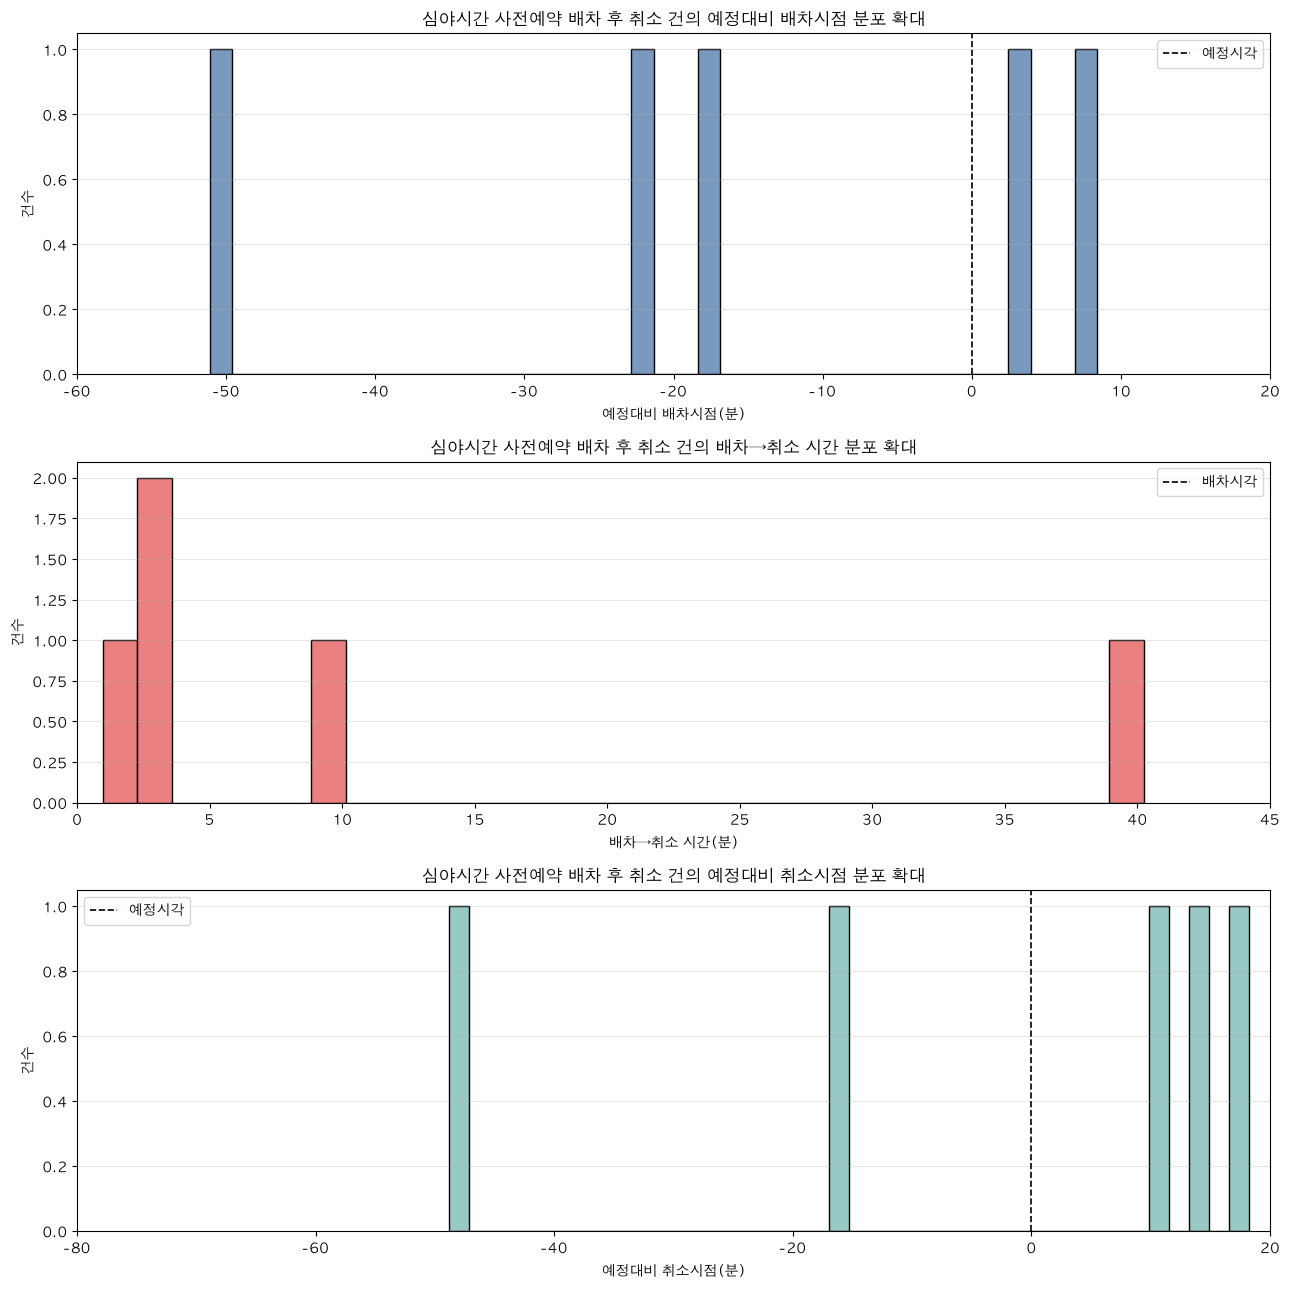

In [59]:
# 코드 셀 목적: 심야시간 사전예약 배차 후 취소 건의 주요 시간 분포를 표본 범위에 맞게 확대해 확인한다.

from pathlib import Path
import platform

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

if "special_cancel_night_reservation" not in globals():
    project_root = Path.cwd()
    if not (project_root / "data" / "processed").exists():
        project_root = project_root.parent

    final_dataset_path = project_root / "data" / "processed" / "특장차_대기시간_전처리_접수유형분류.csv"
    df_special = pd.read_csv(final_dataset_path)

    for col in ["접수일시", "예정일시", "배차일시", "승차일시", "하차일시", "취소일시"]:
        if col in df_special.columns:
            df_special[col] = pd.to_datetime(df_special[col], errors="coerce")

    cancel_type_col = "취소_접수유형_후보"
    if cancel_type_col not in df_special.columns:
        raise KeyError("취소_접수유형_후보 컬럼이 없습니다. 03번 노트북의 취소 접수유형 분류 저장을 먼저 확인해 주세요.")

    special_cancel = df_special[df_special["취소일시"].notna()].copy()
    special_cancel_night_reservation = special_cancel[
        special_cancel[cancel_type_col].eq("심야시간 사전예약 취소 후보")
    ].copy()

if "night_dispatch_cancel" not in globals():
    night_dispatch_cancel = special_cancel_night_reservation.copy()

    for col in ["예정일시", "배차일시", "취소일시"]:
        night_dispatch_cancel[col] = pd.to_datetime(night_dispatch_cancel[col], errors="coerce")

    for col in ["접수_취소_분", "배차_취소_분"]:
        night_dispatch_cancel[col] = pd.to_numeric(night_dispatch_cancel[col], errors="coerce")

    night_dispatch_cancel = night_dispatch_cancel[
        night_dispatch_cancel["예정일시"].notna()
        & night_dispatch_cancel["배차일시"].notna()
        & night_dispatch_cancel["취소일시"].notna()
        & night_dispatch_cancel["배차_취소_분"].ge(0)
    ].copy()

    night_dispatch_cancel["예정대비_배차_분"] = (
        night_dispatch_cancel["배차일시"] - night_dispatch_cancel["예정일시"]
    ).dt.total_seconds() / 60
    night_dispatch_cancel["예정대비_취소_분"] = (
        night_dispatch_cancel["취소일시"] - night_dispatch_cancel["예정일시"]
    ).dt.total_seconds() / 60
    night_dispatch_cancel["배차직후_0_5분_취소여부"] = (
        night_dispatch_cancel["배차_취소_분"].between(0, 5, inclusive="both")
    )
    night_dispatch_cancel["예정시간대_HH"] = night_dispatch_cancel["예정일시"].dt.strftime("%H")
    night_dispatch_cancel["배차시간대_HH"] = night_dispatch_cancel["배차일시"].dt.strftime("%H")

    print(f"심야시간 사전예약 배차 후 취소 데이터 재생성: {len(night_dispatch_cancel):,}건")


fig, axes = plt.subplots(3, 1, figsize=(13, 13))

plot_specs = [
    {
        "col": "예정대비_배차_분",
        "title": "심야시간 사전예약 배차 후 취소 건의 예정대비 배차시점 분포 확대",
        "xlabel": "예정대비 배차시점(분)",
        "color": "#4c78a8",
        "xlim": (-60, 20),
        "bins": 40,
        "zero_label": "예정시각",
    },
    {
        "col": "배차_취소_분",
        "title": "심야시간 사전예약 배차 후 취소 건의 배차→취소 시간 분포 확대",
        "xlabel": "배차→취소 시간(분)",
        "color": "#e45756",
        "xlim": (0, 45),
        "bins": 30,
        "zero_label": "배차시각",
    },
    {
        "col": "예정대비_취소_분",
        "title": "심야시간 사전예약 배차 후 취소 건의 예정대비 취소시점 분포 확대",
        "xlabel": "예정대비 취소시점(분)",
        "color": "#76b7b2",
        "xlim": (-80, 20),
        "bins": 40,
        "zero_label": "예정시각",
    },
]

for ax, spec in zip(axes, plot_specs):
    values = night_dispatch_cancel[spec["col"]].dropna()
    values = values[values.between(spec["xlim"][0], spec["xlim"][1])]

    sns.histplot(
        values,
        bins=spec["bins"],
        color=spec["color"],
        ax=ax,
    )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=spec["zero_label"],
    )

    ax.set_title(spec["title"])
    ax.set_xlabel(spec["xlabel"])
    ax.set_ylabel("건수")
    ax.set_xlim(spec["xlim"])
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## 6-10. 심야시간 사전예약 배차 후 취소: 예정대비 배차시점과 배차 직후 취소 관계

심야시간 사전예약 배차 후 취소도 `예정대비 배차시점`과 `배차→취소` 시간을 함께 확인한다. 심야예약은 차량이 예정시각보다 미리 배차되는 경우가 있을 수 있으므로, 배차 후 취소가 **미리 배차된 뒤 발생한 취소인지, 예정시각에 임박해 발생한 취소인지**를 구분해야 한다.

다만 심야시간 사전예약 배차 후 취소는 건수가 매우 적을 수 있으므로, 히트맵은 통계적 일반화보다는 원자료 점검을 위한 보조 자료로 본다.

,조건,대상건수,배차직후_0~5분_취소건수,배차직후_0~5분_취소비율(%)
0,예정시각 기준 -30분 이후 배차,4,2,50.0
1,예정시각 이후 배차,2,1,50.0
2,예정시각 기준 +10분 이후 배차,0,0,NaN


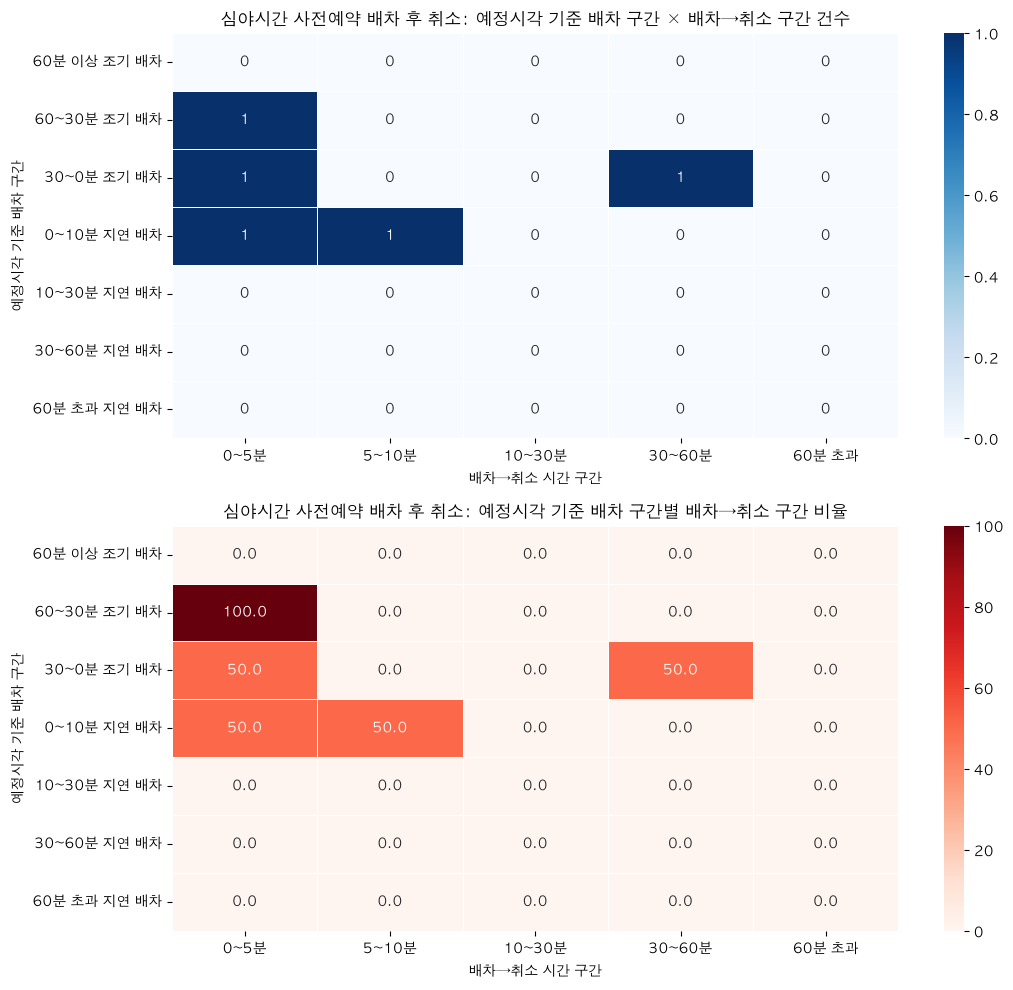

In [60]:
# 코드 셀 목적: 심야시간 사전예약 배차 후 취소에서 예정시각 기준 배차시점과 배차→취소 시간의 관계를 확인한다.

from pathlib import Path
import platform

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

if "special_cancel_night_reservation" not in globals():
    project_root = Path.cwd()
    if not (project_root / "data" / "processed").exists():
        project_root = project_root.parent

    final_dataset_path = project_root / "data" / "processed" / "특장차_대기시간_전처리_접수유형분류.csv"
    df_special = pd.read_csv(final_dataset_path)

    for col in ["접수일시", "예정일시", "배차일시", "승차일시", "하차일시", "취소일시"]:
        if col in df_special.columns:
            df_special[col] = pd.to_datetime(df_special[col], errors="coerce")

    cancel_type_col = "취소_접수유형_후보"
    if cancel_type_col not in df_special.columns:
        raise KeyError("취소_접수유형_후보 컬럼이 없습니다. 03번 노트북의 취소 접수유형 분류 저장을 먼저 확인해 주세요.")

    special_cancel = df_special[df_special["취소일시"].notna()].copy()
    special_cancel_night_reservation = special_cancel[
        special_cancel[cancel_type_col].eq("심야시간 사전예약 취소 후보")
    ].copy()

if "night_dispatch_cancel" not in globals():
    night_dispatch_cancel = special_cancel_night_reservation.copy()

    for col in ["예정일시", "배차일시", "취소일시"]:
        night_dispatch_cancel[col] = pd.to_datetime(night_dispatch_cancel[col], errors="coerce")

    for col in ["접수_취소_분", "배차_취소_분"]:
        night_dispatch_cancel[col] = pd.to_numeric(night_dispatch_cancel[col], errors="coerce")

    night_dispatch_cancel = night_dispatch_cancel[
        night_dispatch_cancel["예정일시"].notna()
        & night_dispatch_cancel["배차일시"].notna()
        & night_dispatch_cancel["취소일시"].notna()
        & night_dispatch_cancel["배차_취소_분"].ge(0)
    ].copy()

    night_dispatch_cancel["예정대비_배차_분"] = (
        night_dispatch_cancel["배차일시"] - night_dispatch_cancel["예정일시"]
    ).dt.total_seconds() / 60
    night_dispatch_cancel["예정대비_취소_분"] = (
        night_dispatch_cancel["취소일시"] - night_dispatch_cancel["예정일시"]
    ).dt.total_seconds() / 60
    night_dispatch_cancel["배차직후_0_5분_취소여부"] = (
        night_dispatch_cancel["배차_취소_분"].between(0, 5, inclusive="both")
    )
    night_dispatch_cancel["예정시간대_HH"] = night_dispatch_cancel["예정일시"].dt.strftime("%H")
    night_dispatch_cancel["배차시간대_HH"] = night_dispatch_cancel["배차일시"].dt.strftime("%H")

    print(f"심야시간 사전예약 배차 후 취소 데이터 재생성: {len(night_dispatch_cancel):,}건")


night_dispatch_relation = night_dispatch_cancel.copy()

schedule_dispatch_bins = [-float("inf"), -60, -30, 0, 10, 30, 60, float("inf")]
schedule_dispatch_labels = [
    "60분 이상 조기 배차",
    "60~30분 조기 배차",
    "30~0분 조기 배차",
    "0~10분 지연 배차",
    "10~30분 지연 배차",
    "30~60분 지연 배차",
    "60분 초과 지연 배차",
]

dispatch_cancel_bins = [0, 5, 10, 30, 60, float("inf")]
dispatch_cancel_labels = ["0~5분", "5~10분", "10~30분", "30~60분", "60분 초과"]

night_dispatch_relation["예정시각기준_배차구간"] = pd.cut(
    night_dispatch_relation["예정대비_배차_분"],
    bins=schedule_dispatch_bins,
    labels=schedule_dispatch_labels,
    right=True,
    include_lowest=True,
)

night_dispatch_relation["배차_취소_구간"] = pd.cut(
    night_dispatch_relation["배차_취소_분"],
    bins=dispatch_cancel_bins,
    labels=dispatch_cancel_labels,
    right=True,
    include_lowest=True,
)

night_relation_count = (
    night_dispatch_relation
    .pivot_table(
        index="예정시각기준_배차구간",
        columns="배차_취소_구간",
        values="취소일시",
        aggfunc="count",
        observed=False,
    )
    .reindex(index=schedule_dispatch_labels, columns=dispatch_cancel_labels)
    .fillna(0)
    .astype(float)
)

night_relation_ratio = (
    night_relation_count
    .div(night_relation_count.sum(axis=1).replace(0, pd.NA), axis=0)
    * 100
)

night_relation_ratio = (
    night_relation_ratio
    .replace({pd.NA: 0})
    .fillna(0)
    .astype(float)
)

night_focus_masks = []

for label, lower in [
    ("예정시각 기준 -30분 이후 배차", -30),
    ("예정시각 이후 배차", 0),
    ("예정시각 기준 +10분 이후 배차", 10),
]:
    base_mask = night_dispatch_relation["예정대비_배차_분"].ge(lower)
    quick_mask = (
        base_mask
        & night_dispatch_relation["배차_취소_분"].between(0, 5, inclusive="both")
    )

    night_focus_masks.append({
        "조건": label,
        "대상건수": base_mask.sum(),
        "배차직후_0~5분_취소건수": quick_mask.sum(),
        "배차직후_0~5분_취소비율(%)": (
            quick_mask.sum() / base_mask.sum() * 100
            if base_mask.sum() > 0
            else pd.NA
        ),
    })

night_focus_summary = pd.DataFrame(night_focus_masks)
night_focus_summary["배차직후_0~5분_취소비율(%)"] = (
    pd.to_numeric(night_focus_summary["배차직후_0~5분_취소비율(%)"], errors="coerce")
    .round(2)
)

display(night_focus_summary)

fig, axes = plt.subplots(2, 1, figsize=(11, 10))

sns.heatmap(
    night_relation_count,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=axes[0],
)

axes[0].set_title("심야시간 사전예약 배차 후 취소: 예정시각 기준 배차 구간 × 배차→취소 구간 건수")
axes[0].set_xlabel("배차→취소 시간 구간")
axes[0].set_ylabel("예정시각 기준 배차 구간")

sns.heatmap(
    night_relation_ratio,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    ax=axes[1],
)

axes[1].set_title("심야시간 사전예약 배차 후 취소: 예정시각 기준 배차 구간별 배차→취소 구간 비율")
axes[1].set_xlabel("배차→취소 시간 구간")
axes[1].set_ylabel("예정시각 기준 배차 구간")

plt.tight_layout()
plt.show()

## 7. 접수시간대별 대기시간 분석

접수시간대별로 바로콜 후보의 `접수→배차`, `접수→승차`, `배차→승차` 90분위수를 확인한다. 90분위수는 평균보다 극단값 영향이 작으면서 장시간 대기 구간을 볼 수 있는 지표다.


In [61]:
# 코드 셀 목적: 특장차 바로콜 후보의 장시간 대기 기준 설정을 위한 대기시간 분포와 분위수를 확인한다.

baro_wait_distribution = special_ride_baro_call.copy()

for col in ["접수_배차_분", "접수_승차_분", "배차_승차_분"]:
    baro_wait_distribution[col] = pd.to_numeric(
        baro_wait_distribution[col],
        errors="coerce",
    )

wait_metric_specs = [
    ("접수_배차_분", "접수→배차"),
    ("접수_승차_분", "접수→승차"),
    ("배차_승차_분", "배차→승차"),
]

quantile_summary = []

for col, label in wait_metric_specs:
    values = baro_wait_distribution[col].dropna()
    values = values[values.ge(0)]

    quantile_summary.append({
        "지표": label,
        "건수": len(values),
        "평균": values.mean(),
        "중앙값": values.median(),
        "75분위수": values.quantile(0.75),
        "80분위수": values.quantile(0.80),
        "85분위수": values.quantile(0.85),
        "90분위수": values.quantile(0.90),
        "95분위수": values.quantile(0.95),
        "99분위수": values.quantile(0.99),
        "최대값": values.max(),
    })

quantile_summary = pd.DataFrame(quantile_summary)
display(quantile_summary.round(2))

,지표,건수,평균,중앙값,75분위수,80분위수,85분위수,90분위수,95분위수,99분위수,최대값
0,접수→배차,1099084,27.47,11.98,36.92,46.03,57.94,72.12,107.83,142.38,198.33
1,접수→승차,1099084,46.27,33.42,57.33,66.53,78.84,95.13,133.94,166.64,199.99
2,배차→승차,1099084,18.80,17.85,23.56,25.11,26.96,29.42,33.46,42.77,137.37


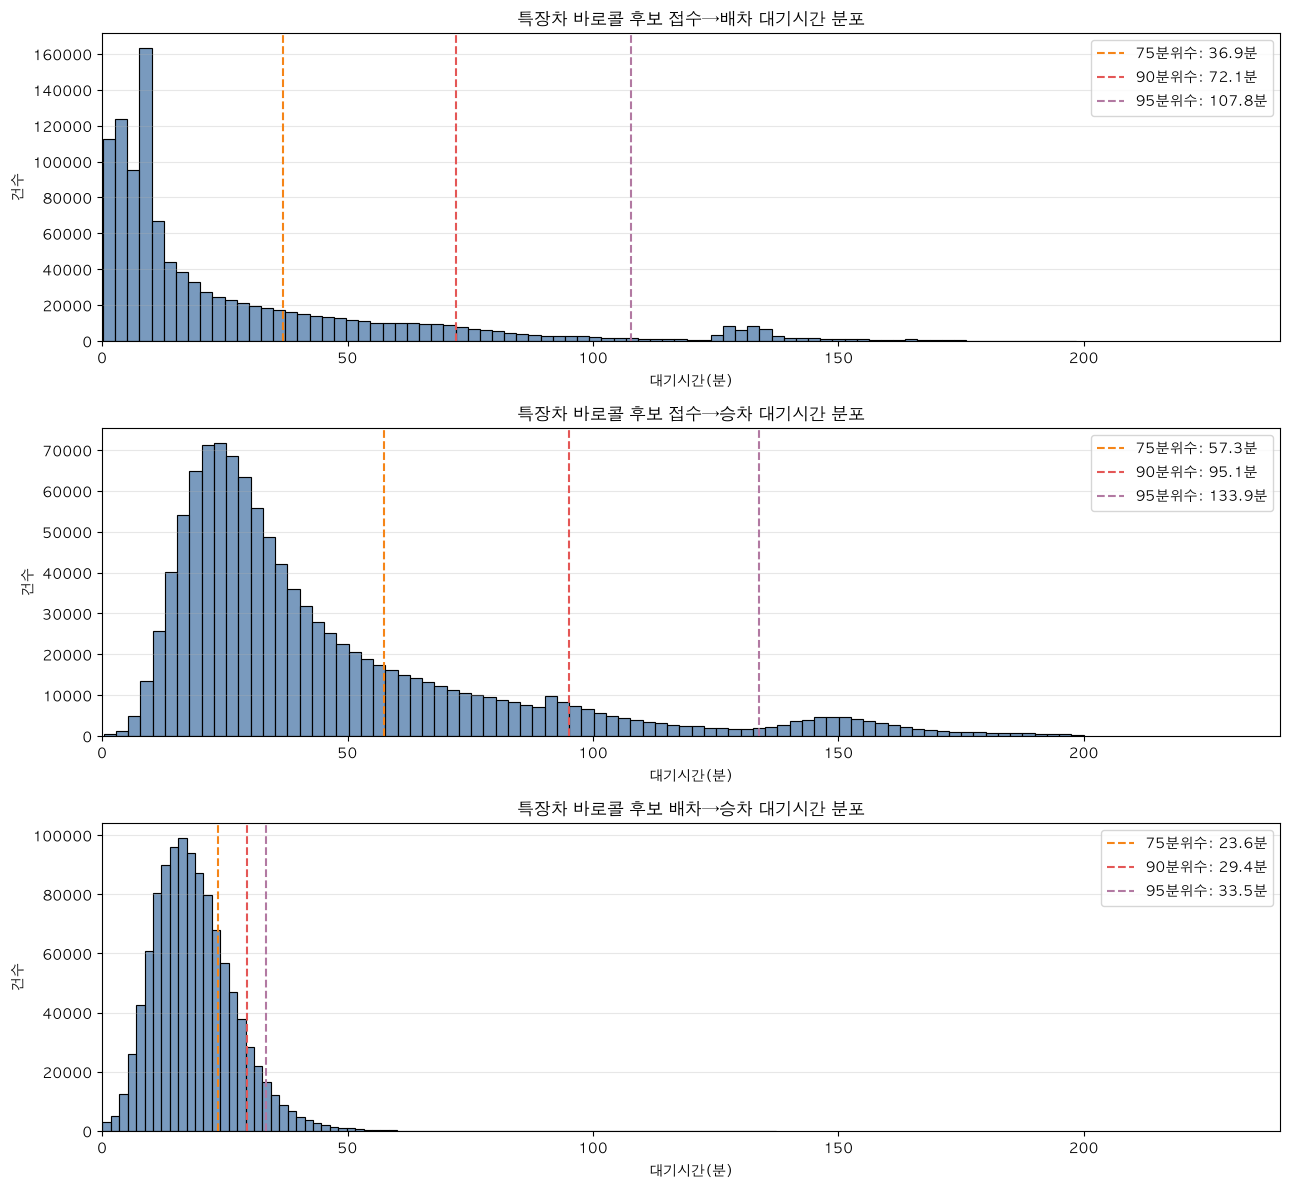

In [62]:
# 코드 셀 목적: 장시간 대기 기준 설정을 위해 바로콜 후보 대기시간 분포를 시각화한다.

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

for ax, (col, label) in zip(axes, wait_metric_specs):
    values = baro_wait_distribution[col].dropna()
    values = values[values.between(0, 240)]

    p75 = values.quantile(0.75)
    p90 = values.quantile(0.90)
    p95 = values.quantile(0.95)

    sns.histplot(
        values,
        bins=80,
        color="#4c78a8",
        ax=ax,
    )

    ax.axvline(p75, color="#f58518", linestyle="--", linewidth=1.5, label=f"75분위수: {p75:.1f}분")
    ax.axvline(p90, color="#e45756", linestyle="--", linewidth=1.5, label=f"90분위수: {p90:.1f}분")
    ax.axvline(p95, color="#b279a2", linestyle="--", linewidth=1.5, label=f"95분위수: {p95:.1f}분")

    ax.set_title(f"특장차 바로콜 후보 {label} 대기시간 분포")
    ax.set_xlabel("대기시간(분)")
    ax.set_ylabel("건수")
    ax.set_xlim(0, 240)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

본 분석에서는 바로콜 대기시간의 병목이 배차 이후 이동시간보다 접수 후 배차까지의 시간에서 크게 나타났으므로,
장시간 대기 기준은 접수→배차 대기시간을 기준으로 설정하였다.

접수→배차 대기시간의 75분위수는 약 36.9분으로 전체의 25%를 포함해 장시간 대기 기준으로는 다소 넓고,
95분위수는 약 107.8분으로 극단적 사례 중심의 기준이 된다.

따라서 일반 대기와 장시간 대기를 구분하면서도 충분한 분석 표본을 확보할 수 있는
90분위수, 즉 약 72.1분을 장시간 대기 기준으로 사용하였다.
실무 적용과 해석 편의를 위해서는 접수→배차 75분 이상으로 반올림해 사용할 수 있다.

,접수시간대_HH,승차완료건수,접수_배차_중앙값,접수_배차_75분위수,접수_배차_90분위수,접수_승차_중앙값,접수_승차_75분위수,접수_승차_90분위수
0,00,1685,12.794550,29.302833,49.737143,39.600500,54.929167,75.003963
1,01,1024,11.816808,30.223437,78.963933,39.381117,56.781158,106.820100
2,02,2546,97.308608,104.252900,110.526308,119.057758,130.913675,140.874892
3,03,2583,9.864433,99.965258,111.006950,36.779667,127.465075,138.895287
4,04,10542,133.877300,149.557138,163.818178,152.726200,170.161704,184.428728
5,05,12134,128.158392,135.759938,150.307000,146.668533,161.238804,174.286215
6,06,18466,51.965725,104.330867,136.965908,71.488633,125.876963,160.573467
7,07,69751,36.519717,60.467833,76.104000,56.374617,80.251808,98.218717
8,08,88382,36.083450,57.287000,73.659738,55.216083,76.687304,95.187872
9,09,75245,19.072383,39.218450,69.865730,39.315000,59.139717,91.948830


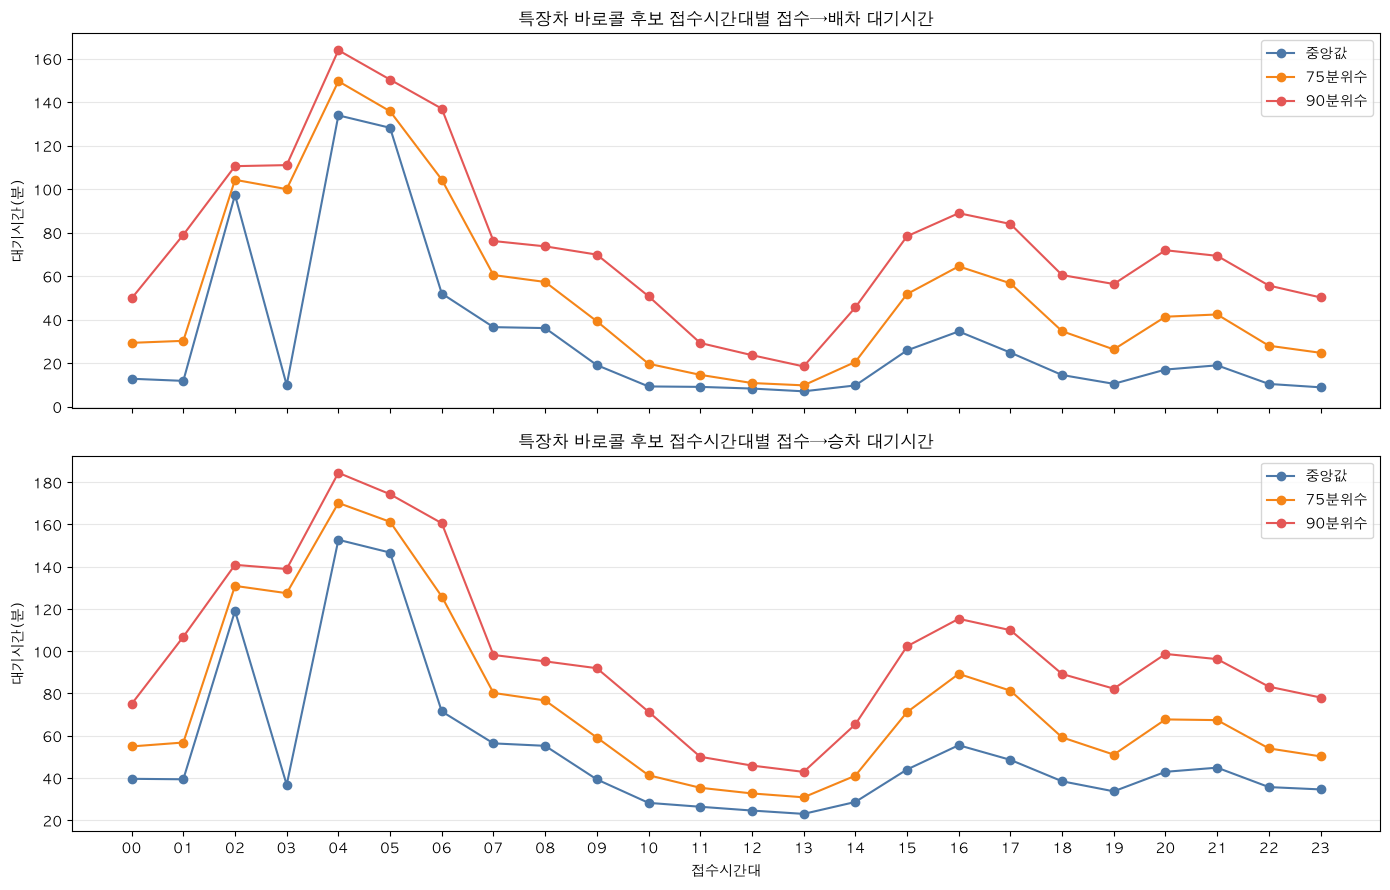

In [63]:
# 코드 셀 목적: 특장차 바로콜 후보의 접수시간대별 접수→배차·접수→승차 대기시간 분위수를 확인한다.
if "special_ride_baro_call" not in globals():
    project_root = Path.cwd()
    if not (project_root / "data" / "processed").exists():
        project_root = project_root.parent

    final_dataset_path = project_root / "data" / "processed" / "특장차_대기시간_전처리_접수유형분류.csv"
    df_special = pd.read_csv(final_dataset_path)

    datetime_cols = [
        "접수일시",
        "예정일시",
        "배차일시",
        "승차일시",
        "하차일시",
        "취소일시",
        "접수일자",
        "예정일자",
        "배차일자",
        "승차일자",
        "하차일자",
    ]

    for col in datetime_cols:
        if col in df_special.columns:
            df_special[col] = pd.to_datetime(df_special[col], errors="coerce")

    request_type_col = "특장차_접수유형_후보_최종"
    if request_type_col not in df_special.columns:
        request_type_col = "특장차_접수유형_후보_보완"

    special_ride_valid = df_special[
        df_special["특장차_탑승완료_시간논리정상여부"].fillna(False)
    ].copy()

    special_ride_baro_call = special_ride_valid[
        special_ride_valid[request_type_col].eq("바로콜 후보")
    ].copy()

    print(f"특장차 바로콜 후보 데이터 재생성: {len(special_ride_baro_call):,}건")

baro_wait_by_request_hour = special_ride_baro_call.copy()

baro_wait_by_request_hour["접수일시"] = pd.to_datetime(
    baro_wait_by_request_hour["접수일시"],
    errors="coerce",
)

baro_wait_by_request_hour["접수시간대_HH"] = (
    baro_wait_by_request_hour["접수일시"]
    .dt.strftime("%H")
)

wait_cols = [
    "접수_배차_분",
    "접수_승차_분",
]

for col in wait_cols:
    baro_wait_by_request_hour[col] = pd.to_numeric(
        baro_wait_by_request_hour[col],
        errors="coerce",
    )

hour_order = [f"{hour:02d}" for hour in range(24)]

baro_wait_hour_summary = (
    baro_wait_by_request_hour
    .groupby("접수시간대_HH", observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_75분위수=("접수_배차_분", lambda x: x.quantile(0.75)),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_75분위수=("접수_승차_분", lambda x: x.quantile(0.75)),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reindex(hour_order)
    .reset_index()
)

display(baro_wait_hour_summary)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

plot_specs = [
    ("접수_배차", "접수→배차"),
    ("접수_승차", "접수→승차"),
]

for ax, (prefix, title) in zip(axes, plot_specs):
    ax.plot(
        baro_wait_hour_summary["접수시간대_HH"],
        baro_wait_hour_summary[f"{prefix}_중앙값"],
        marker="o",
        label="중앙값",
        color="#4c78a8",
    )
    ax.plot(
        baro_wait_hour_summary["접수시간대_HH"],
        baro_wait_hour_summary[f"{prefix}_75분위수"],
        marker="o",
        label="75분위수",
        color="#f58518",
    )
    ax.plot(
        baro_wait_hour_summary["접수시간대_HH"],
        baro_wait_hour_summary[f"{prefix}_90분위수"],
        marker="o",
        label="90분위수",
        color="#e45756",
    )

    ax.set_title(f"특장차 바로콜 후보 접수시간대별 {title} 대기시간")
    ax.set_ylabel("대기시간(분)")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("접수시간대")

plt.tight_layout()
plt.show()

특장차 바로콜 후보의 접수시간대별 대기시간은 시간대별 편차가 크다.
특히 04~05시 접수 건에서 접수→배차 및 접수→승차 대기시간이 가장 길게 나타났으며,
이는 심야·새벽 시간대 차량 공급 부족 또는 배차 가능 차량 감소의 영향으로 해석된다.

반면 11~13시는 중앙값과 90분위수가 모두 낮아 상대적으로 안정적인 배차가 이루어지는 시간대다.
오후 15~17시와 저녁 20~21시에도 대기시간이 다시 상승해,
새벽 시간대 외에도 특정 피크 시간대에서 장시간 대기 관리가 필요하다.

접수→배차와 접수→승차 그래프의 패턴이 거의 동일하므로,
바로콜 장시간 대기의 주요 병목은 배차 이후 이동보다 접수 후 배차 단계에 있는 것으로 판단된다.

,접수시간대,승차완료건수,접수_배차_중앙값,접수_배차_90분위수,접수_승차_중앙값,접수_승차_90분위수,배차_승차_중앙값,배차_승차_90분위수,접수시간대_HH
0,00:00:00,1685,12.794550,49.737143,39.600500,75.003963,23.566383,36.497030,00
1,01:00:00,1024,11.816808,78.963933,39.381117,106.820100,22.865833,36.537767,01
2,02:00:00,2546,97.308608,110.526308,119.057758,140.874892,22.815675,36.451025,02
3,03:00:00,2583,9.864433,111.006950,36.779667,138.895287,22.610000,36.020743,03
4,04:00:00,10542,133.877300,163.818178,152.726200,184.428728,19.408225,31.062772,04
5,05:00:00,12134,128.158392,150.307000,146.668533,174.286215,19.959442,31.179402,05
6,06:00:00,18466,51.965725,136.965908,71.488633,160.573467,18.909200,29.906033,06
7,07:00:00,69751,36.519717,76.104000,56.374617,98.218717,19.556950,30.216383,07
8,08:00:00,88382,36.083450,73.659738,55.216083,95.187872,18.757283,28.861617,08
9,09:00:00,75245,19.072383,69.865730,39.315000,91.948830,18.462550,29.060150,09


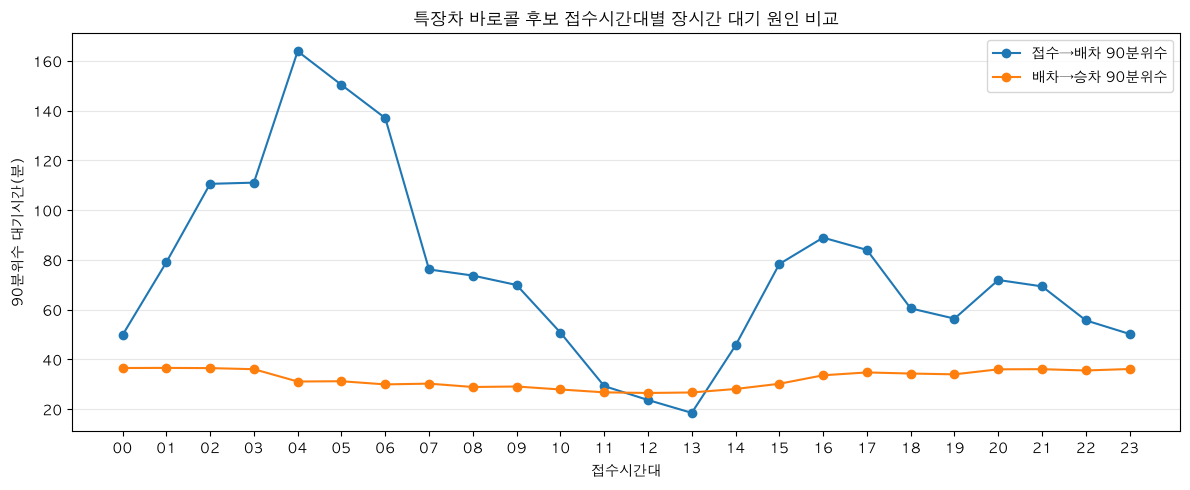

In [64]:
# 코드 셀 목적: 특장차 바로콜 후보의 접수시간대별 대기시간을 집계하고 시각화한다.

hourly_baro_summary = (
    special_ride_baro_call
    .groupby("접수시간대", observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
    .sort_values("접수시간대")
)

hourly_baro_summary["접수시간대_HH"] = hourly_baro_summary["접수시간대"].astype(str).str.slice(0, 2)

display(hourly_baro_summary)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_baro_summary["접수시간대_HH"], hourly_baro_summary["접수_배차_90분위수"], marker="o", label="접수→배차 90분위수")
ax.plot(hourly_baro_summary["접수시간대_HH"], hourly_baro_summary["배차_승차_90분위수"], marker="o", label="배차→승차 90분위수")
ax.set_title("특장차 바로콜 후보 접수시간대별 장시간 대기 원인 비교")
ax.set_xlabel("접수시간대")
ax.set_ylabel("90분위수 대기시간(분)")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


- 차량이 배정된 뒤 승차지까지 오는 시간은 비교적 안정적인데 차량이 배정되기까지 걸리는 시간이 특정 시간대에 급격히 길어진다
- 13시는 접수→배차 90분위수가 20분 안팎으로 가장 안정적 => 이 시간대는 바로콜 수요와 공급 대응이 상대적으로 잘 맞는 구간

접수시간대별 90분위수 기준으로 장시간 대기의 원인을 비교한 결과,
배차→승차 대기시간은 전 시간대에서 30분 내외로 비교적 안정적인 반면,
접수→배차 대기시간은 시간대별 편차가 크게 나타났다.

특히 04~06시에는 접수→배차 90분위수가 130~160분대로 급증하지만,
배차→승차 90분위수는 30분대에 머물러 있다.
이는 해당 시간대 장시간 대기가 차량 배정 이후 이동 지연보다,
접수 후 배차 가능한 차량을 확보하는 단계에서 발생했음을 의미한다.

따라서 특장차 바로콜의 장시간 대기 문제는 주로 접수→배차 단계의 병목으로 해석되며,
새벽 04~06시, 오후 15~17시, 저녁 20~21시를 우선 관리 시간대로 볼 수 있다.

## 7-1. 시간대별 접수 규모 확인

접수시간대별 대기시간을 해석할 때는 대기시간 자체뿐 아니라 해당 시간대의 접수 규모를 함께 확인해야 한다.

예를 들어 04~06시의 대기시간이 길게 나타나더라도 해당 시간대 접수건수가 매우 적다면, 이는 일부 사례의 영향이 크게 반영된 결과일 수 있다. 반면 15~17시처럼 접수건수도 많고 대기시간도 긴 시간대는 실제 운영 부담과 이용자 불편이 동시에 큰 구간으로 볼 수 있다.

따라서 시간대별 접수건수, 승차완료건수, 취소건수를 함께 확인하여 장시간 대기 시간대의 운영 우선순위를 판단한다.

In [65]:
# 코드 셀 목적: 특장차 바로콜 후보의 접수시간대별 접수건수·승차완료건수·취소건수를 확인한다.

baro_hourly_volume = special_ride_baro_call.copy()
baro_hourly_cancel = special_cancel_baro_call.copy()

baro_hourly_volume["접수일시"] = pd.to_datetime(
    baro_hourly_volume["접수일시"],
    errors="coerce",
)
baro_hourly_cancel["접수일시"] = pd.to_datetime(
    baro_hourly_cancel["접수일시"],
    errors="coerce",
)

baro_hourly_volume["접수시간대_HH"] = baro_hourly_volume["접수일시"].dt.strftime("%H")
baro_hourly_cancel["접수시간대_HH"] = baro_hourly_cancel["접수일시"].dt.strftime("%H")

hour_order = [f"{hour:02d}" for hour in range(24)]

baro_ride_hourly_count = (
    baro_hourly_volume
    .groupby("접수시간대_HH", observed=False)
    .agg(
        승차완료건수=("접수일시", "count"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reindex(hour_order)
    .reset_index()
)

baro_cancel_hourly_count = (
    baro_hourly_cancel
    .groupby("접수시간대_HH", observed=False)
    .agg(
        취소건수=("접수일시", "count"),
    )
    .reindex(hour_order)
    .reset_index()
)

baro_hourly_count_summary = baro_ride_hourly_count.merge(
    baro_cancel_hourly_count,
    on="접수시간대_HH",
    how="left",
)

baro_hourly_count_summary["취소건수"] = (
    baro_hourly_count_summary["취소건수"]
    .fillna(0)
    .astype(int)
)

baro_hourly_count_summary["전체접수건수"] = (
    baro_hourly_count_summary["승차완료건수"]
    + baro_hourly_count_summary["취소건수"]
)

baro_hourly_count_summary["취소율(%)"] = (
    baro_hourly_count_summary["취소건수"]
    / baro_hourly_count_summary["전체접수건수"].replace(0, pd.NA)
    * 100
)

display(baro_hourly_count_summary.round(2))

,접수시간대_HH,승차완료건수,접수_배차_90분위수,접수_승차_90분위수,취소건수,전체접수건수,취소율(%)
0,00,1685,49.74,75.00,499,2184,22.85
1,01,1024,78.96,106.82,305,1329,22.95
2,02,2546,110.53,140.87,296,2842,10.42
3,03,2583,111.01,138.90,590,3173,18.59
4,04,10542,163.82,184.43,3836,14378,26.68
5,05,12134,150.31,174.29,5646,17780,31.75
6,06,18466,136.97,160.57,5361,23827,22.50
7,07,69751,76.10,98.22,16232,85983,18.88
8,08,88382,73.66,95.19,17695,106077,16.68
9,09,75245,69.87,91.95,15794,91039,17.35


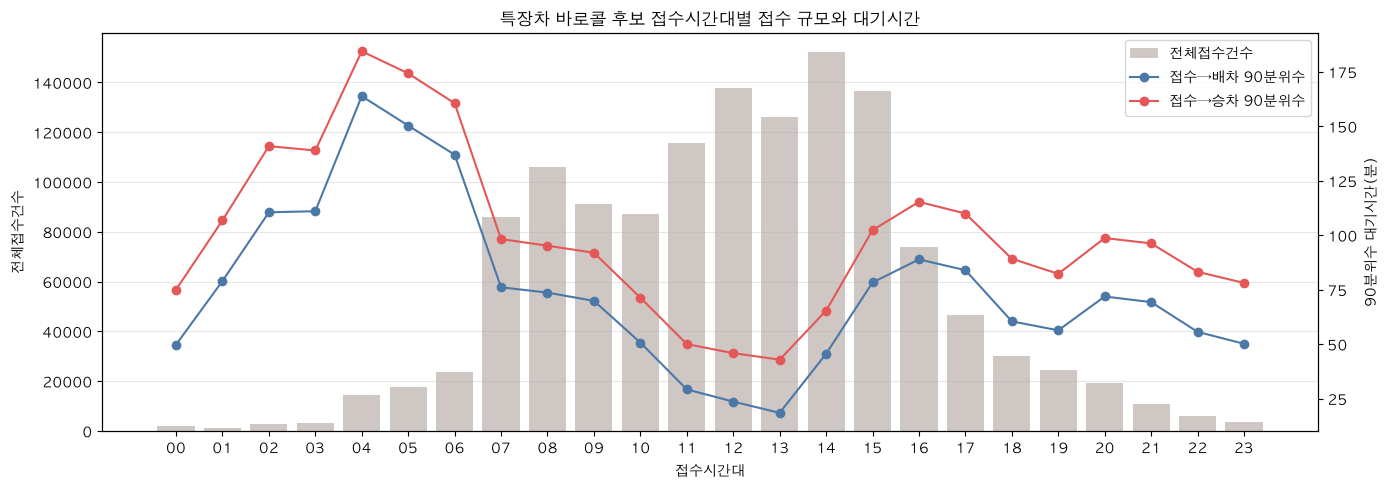

In [66]:
# 코드 셀 목적: 접수시간대별 접수 규모와 장시간 대기 수준을 함께 시각화한다.

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(
    baro_hourly_count_summary["접수시간대_HH"],
    baro_hourly_count_summary["전체접수건수"],
    color="#bab0ab",
    alpha=0.7,
    label="전체접수건수",
)

ax1.set_title("특장차 바로콜 후보 접수시간대별 접수 규모와 대기시간")
ax1.set_xlabel("접수시간대")
ax1.set_ylabel("전체접수건수")
ax1.grid(axis="y", alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    baro_hourly_count_summary["접수시간대_HH"],
    baro_hourly_count_summary["접수_배차_90분위수"],
    marker="o",
    color="#4c78a8",
    label="접수→배차 90분위수",
)

ax2.plot(
    baro_hourly_count_summary["접수시간대_HH"],
    baro_hourly_count_summary["접수_승차_90분위수"],
    marker="o",
    color="#e45756",
    label="접수→승차 90분위수",
)

ax2.set_ylabel("90분위수 대기시간(분)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

접수시간대별 접수 규모와 대기시간을 함께 비교한 결과,
장시간 대기가 가장 심한 시간대는 04~06시였으나 해당 시간대의 접수 규모는 크지 않았다.
반면 11~15시는 접수건수가 가장 많았지만 대기시간 90분위수는 상대적으로 낮아,
수요 집중이 곧바로 장시간 대기로 이어지지는 않는 것으로 나타났다.

운영 우선순위 관점에서는 접수 규모와 장시간 대기가 동시에 나타나는 16~17시가 가장 중요하다.
04~06시는 건수는 적지만 대기시간이 매우 길어 취약 시간대 관리 대상으로 볼 수 있으며,
20~21시는 저녁 시간대 보조 관리 구간으로 해석된다.

## 7-2. 시간대별 장시간 대기 건수와 비율 확인

접수시간대별 대기시간을 해석할 때는 90분위수 같은 분위수 지표뿐 아니라, 실제 장시간 대기 건수와 비율을 함께 확인해야 한다.

본 분석에서는 바로콜 대기 병목이 주로 `접수→배차` 단계에서 나타났으므로, `접수→배차 75분 이상`을 장시간 대기 기준으로 설정한다.

장시간 대기 건수는 해당 시간대의 운영 부담 규모를 보여준다. 반면 장시간 대기 비율은 해당 시간대에 접수한 이용자가 장시간 대기를 경험할 위험도를 보여준다.

예를 들어 특정 시간대의 장시간 대기 건수가 많다면 차량 배정 부담이 큰 시간대로 볼 수 있고, 장시간 대기 비율이 높다면 접수 규모가 크지 않더라도 해당 시간대 이용자의 대기 위험이 높은 것으로 해석할 수 있다.

따라서 시간대별로 전체 접수건수, 장시간 대기 건수, 장시간 대기 비율을 함께 확인하여 운영 개선 우선순위를 판단한다.

In [67]:
# 코드 셀 목적: 특장차 바로콜 후보의 접수시간대별 장시간 대기 건수와 비율을 확인한다.

long_wait_threshold = 75

baro_long_wait_by_hour = special_ride_baro_call.copy()

baro_long_wait_by_hour["접수일시"] = pd.to_datetime(
    baro_long_wait_by_hour["접수일시"],
    errors="coerce",
)

baro_long_wait_by_hour["접수시간대_HH"] = (
    baro_long_wait_by_hour["접수일시"]
    .dt.strftime("%H")
)

baro_long_wait_by_hour["접수_배차_분"] = pd.to_numeric(
    baro_long_wait_by_hour["접수_배차_분"],
    errors="coerce",
)

baro_long_wait_by_hour = baro_long_wait_by_hour[
    baro_long_wait_by_hour["접수시간대_HH"].notna()
    & baro_long_wait_by_hour["접수_배차_분"].notna()
    & baro_long_wait_by_hour["접수_배차_분"].ge(0)
].copy()

baro_long_wait_by_hour["장시간대기여부"] = (
    baro_long_wait_by_hour["접수_배차_분"].ge(long_wait_threshold)
)

hour_order = [f"{hour:02d}" for hour in range(24)]

baro_long_wait_hour_summary = (
    baro_long_wait_by_hour
    .groupby("접수시간대_HH", observed=False)
    .agg(
        전체접수건수=("접수_배차_분", "count"),
        장시간대기건수=("장시간대기여부", "sum"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
    )
    .reindex(hour_order)
    .reset_index()
)

baro_long_wait_hour_summary["장시간대기비율(%)"] = (
    baro_long_wait_hour_summary["장시간대기건수"]
    / baro_long_wait_hour_summary["전체접수건수"].replace(0, pd.NA)
    * 100
)

display(baro_long_wait_hour_summary.round(2))

,접수시간대_HH,전체접수건수,장시간대기건수,접수_배차_중앙값,접수_배차_90분위수,장시간대기비율(%)
0,00,1685,40,12.79,49.74,2.37
1,01,1024,108,11.82,78.96,10.55
2,02,2546,1529,97.31,110.53,60.05
3,03,2583,948,9.86,111.01,36.70
4,04,10542,7113,133.88,163.82,67.47
5,05,12134,9204,128.16,150.31,75.85
6,06,18466,5744,51.97,136.97,31.11
7,07,69751,7527,36.52,76.10,10.79
8,08,88382,8073,36.08,73.66,9.13
9,09,75245,6800,19.07,69.87,9.04


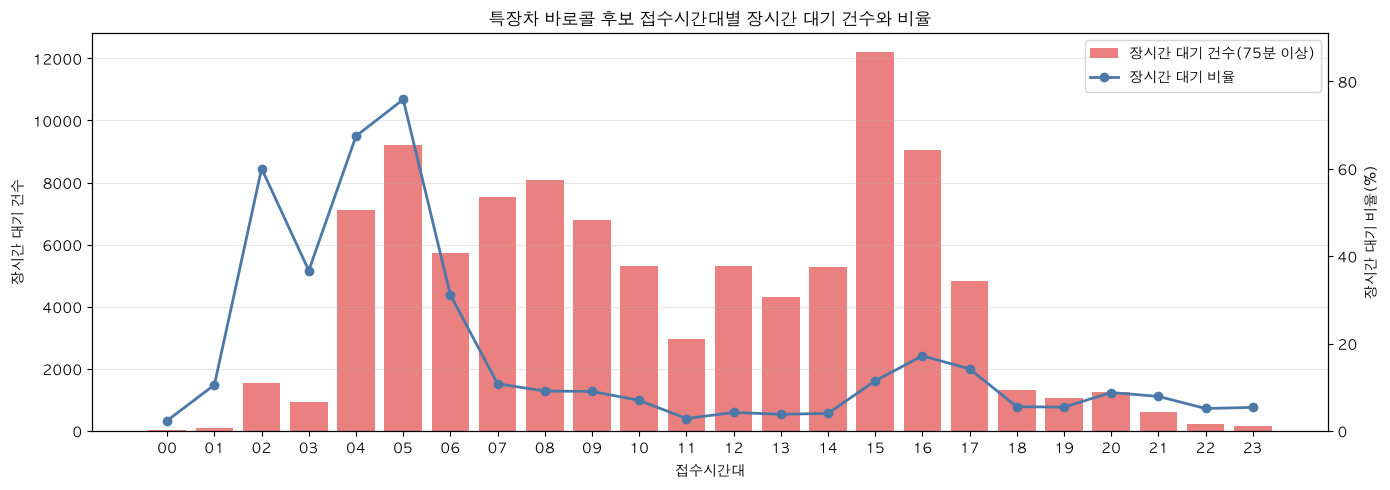

In [68]:
# 코드 셀 목적: 특장차 바로콜 후보의 접수시간대별 장시간 대기 건수와 비율을 함께 시각화한다.

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(
    baro_long_wait_hour_summary["접수시간대_HH"],
    baro_long_wait_hour_summary["장시간대기건수"],
    color="#e45756",
    alpha=0.75,
    label=f"장시간 대기 건수({long_wait_threshold}분 이상)",
)

ax1.set_title("특장차 바로콜 후보 접수시간대별 장시간 대기 건수와 비율")
ax1.set_xlabel("접수시간대")
ax1.set_ylabel("장시간 대기 건수")
ax1.grid(axis="y", alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    baro_long_wait_hour_summary["접수시간대_HH"],
    baro_long_wait_hour_summary["장시간대기비율(%)"],
    marker="o",
    linewidth=2,
    color="#4c78a8",
    label="장시간 대기 비율",
)

ax2.set_ylabel("장시간 대기 비율(%)")

max_ratio = baro_long_wait_hour_summary["장시간대기비율(%)"].dropna().max()
ax2.set_ylim(0, max_ratio * 1.2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
)

plt.tight_layout()
plt.show()

접수→배차 75분 이상을 장시간 대기로 정의하여 시간대별 장시간 대기 건수와 비율을 비교한 결과 장시간 대기 비율과 장시간 대기 건수의 피크 시간대가 서로 다르게 나타났다.

04~05시는 장시간 대기 비율이 가장 높아 해당 시간대 접수 건의 상당수가 장시간 대기로 이어지는 취약 시간대다.
반면 15~16시는 장시간 대기 비율은 새벽 시간대보다 낮지만 접수 규모가 커서,
실제 장시간 대기 건수가 가장 많이 발생하는 운영 부담 시간대다.

따라서 장시간 대기 개선 우선순위는 이용자 위험도 측면의 04~05시와,
운영 부담 측면의 15~16시를 구분하여 설정할 필요가 있다.

## 7-3. 시간대별 취소율 확인

접수시간대별 대기시간을 해석할 때는 장시간 대기가 실제 취소 증가로 이어지는지도 함께 확인해야 한다.

대기시간이 긴 시간대라도 취소율이 낮다면, 해당 시간대는 불편은 크지만 실제 탑승으로 이어지는 비중이 높은 구간으로 볼 수 있다. 반대로 접수→배차 대기시간이 길고 취소율도 함께 높다면, 이용자가 대기 중 이탈할 가능성이 큰 서비스 이탈 위험 시간대로 해석할 수 있다.

따라서 시간대별로 승차완료건수, 취소건수, 전체접수건수, 취소율, 접수→배차 90분위수를 함께 비교하여 장시간 대기와 취소의 관계를 확인한다.

In [69]:
# 코드 셀 목적: 특장차 바로콜 후보의 접수시간대별 취소율과 접수→배차 대기시간을 함께 확인한다.

baro_cancel_rate_by_hour = special_ride_baro_call.copy()
baro_cancel_by_hour = special_cancel_baro_call.copy()

baro_cancel_rate_by_hour["접수일시"] = pd.to_datetime(
    baro_cancel_rate_by_hour["접수일시"],
    errors="coerce",
)
baro_cancel_by_hour["접수일시"] = pd.to_datetime(
    baro_cancel_by_hour["접수일시"],
    errors="coerce",
)

baro_cancel_rate_by_hour["접수시간대_HH"] = (
    baro_cancel_rate_by_hour["접수일시"]
    .dt.strftime("%H")
)
baro_cancel_by_hour["접수시간대_HH"] = (
    baro_cancel_by_hour["접수일시"]
    .dt.strftime("%H")
)

baro_cancel_rate_by_hour["접수_배차_분"] = pd.to_numeric(
    baro_cancel_rate_by_hour["접수_배차_분"],
    errors="coerce",
)

hour_order = [f"{hour:02d}" for hour in range(24)]

baro_ride_hourly = (
    baro_cancel_rate_by_hour
    .groupby("접수시간대_HH", observed=False)
    .agg(
        승차완료건수=("접수일시", "count"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
    )
    .reindex(hour_order)
    .reset_index()
)

baro_cancel_hourly = (
    baro_cancel_by_hour
    .groupby("접수시간대_HH", observed=False)
    .agg(
        취소건수=("접수일시", "count"),
    )
    .reindex(hour_order)
    .reset_index()
)

baro_cancel_rate_hour_summary = baro_ride_hourly.merge(
    baro_cancel_hourly,
    on="접수시간대_HH",
    how="left",
)

baro_cancel_rate_hour_summary["취소건수"] = (
    baro_cancel_rate_hour_summary["취소건수"]
    .fillna(0)
    .astype(int)
)

baro_cancel_rate_hour_summary["전체접수건수"] = (
    baro_cancel_rate_hour_summary["승차완료건수"]
    + baro_cancel_rate_hour_summary["취소건수"]
)

baro_cancel_rate_hour_summary["취소율(%)"] = (
    baro_cancel_rate_hour_summary["취소건수"]
    / baro_cancel_rate_hour_summary["전체접수건수"].replace(0, pd.NA)
    * 100
)

display(baro_cancel_rate_hour_summary.round(2))

,접수시간대_HH,승차완료건수,접수_배차_90분위수,취소건수,전체접수건수,취소율(%)
0,00,1685,49.74,499,2184,22.85
1,01,1024,78.96,305,1329,22.95
2,02,2546,110.53,296,2842,10.42
3,03,2583,111.01,590,3173,18.59
4,04,10542,163.82,3836,14378,26.68
5,05,12134,150.31,5646,17780,31.75
6,06,18466,136.97,5361,23827,22.50
7,07,69751,76.10,16232,85983,18.88
8,08,88382,73.66,17695,106077,16.68
9,09,75245,69.87,15794,91039,17.35


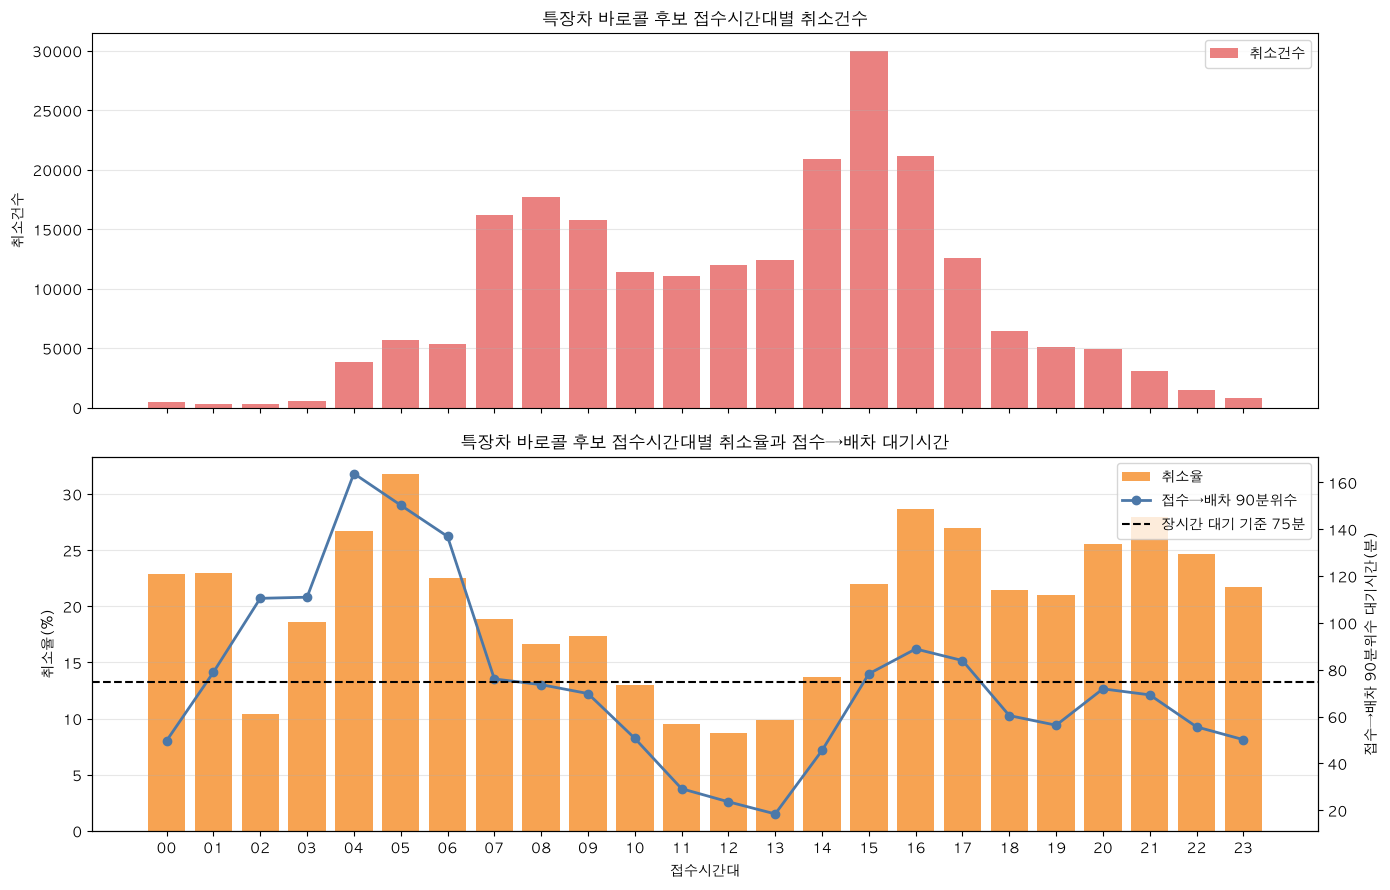

In [70]:
# 코드 셀 목적: 특장차 바로콜 후보의 접수시간대별 취소건수·취소율·접수→배차 대기시간을 함께 시각화한다.

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].bar(
    baro_cancel_rate_hour_summary["접수시간대_HH"],
    baro_cancel_rate_hour_summary["취소건수"],
    color="#e45756",
    alpha=0.75,
    label="취소건수",
)

axes[0].set_title("특장차 바로콜 후보 접수시간대별 취소건수")
axes[0].set_ylabel("취소건수")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

axes[1].bar(
    baro_cancel_rate_hour_summary["접수시간대_HH"],
    baro_cancel_rate_hour_summary["취소율(%)"],
    color="#f58518",
    alpha=0.75,
    label="취소율",
)

ax2 = axes[1].twinx()

ax2.plot(
    baro_cancel_rate_hour_summary["접수시간대_HH"],
    baro_cancel_rate_hour_summary["접수_배차_90분위수"],
    marker="o",
    linewidth=2,
    color="#4c78a8",
    label="접수→배차 90분위수",
)

ax2.axhline(
    75,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="장시간 대기 기준 75분",
)

axes[1].set_title("특장차 바로콜 후보 접수시간대별 취소율과 접수→배차 대기시간")
axes[1].set_xlabel("접수시간대")
axes[1].set_ylabel("취소율(%)")
ax2.set_ylabel("접수→배차 90분위수 대기시간(분)")
axes[1].grid(axis="y", alpha=0.3)

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

axes[1].legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
)

plt.tight_layout()
plt.show()

*취소가 많은 시간대와 장시간 대기가 심한 시간대가 일부 겹치지만, 완전히 같은 패턴은 아니다*

- 접수시간대별 취소건수와 취소율을 접수→배차 90분위수와 함께 비교한 결과 취소건수는 접수 규모가 큰 15~17시에 집중되었으며 특히 16시에 가장 많이 발생하였다.

- 취소율은 04~05시, 15~17시, 20~23시에서 높게 나타났다. 이 중 04~06시와 15~17시는 접수→배차 90분위수도 장시간 대기 기준인 75분을 넘거나 근접해
장시간 대기와 취소 위험이 함께 나타나는 시간대로 해석된다.

- 반면 20~23시는 취소율은 높지만 접수→배차 대기시간은 상대적으로 낮아 대기시간 외의 취소 요인이 작용했을 가능성이 있다.

- 따라서 서비스 이탈 위험 관리 측면에서는 04~06시와 15~17시를 우선적으로 검토하고 20~23시는 취소 사유 또는 이용 패턴을 추가로 확인할 필요가 있다.

## 7-4. 요일별·평일/주말별 시간대 패턴 확인

접수시간대별 장시간 대기와 취소율은 평일과 주말에 따라 다르게 나타날 수 있다.

특장차 이용은 병원 진료, 통원, 복지시설 이동 등 평일 낮 시간대 목적과 연결될 가능성이 크다. 따라서 전체 시간대 평균만 보면 평일 수요 집중과 주말 패턴 차이가 섞여 해석될 수 있다.

특히 앞선 분석에서 장시간 대기 또는 취소 위험이 높게 나타난 04~06시, 15~17시, 20~21시가 평일과 주말 모두에서 반복되는지 확인해야 한다. 만약 특정 시간대의 문제가 평일에만 집중된다면 병원·통원 목적 수요 또는 평일 차량 운영 구조와 관련될 수 있고, 주말에도 동일하게 나타난다면 시간대 자체의 공급 부족 문제일 가능성이 크다.

따라서 접수시간대별 대기시간, 장시간 대기 비율, 취소율을 평일/주말 및 요일별로 나누어 비교한다.

In [71]:
# 코드 셀 목적: 특장차 바로콜 후보의 평일/주말별 접수시간대별 대기시간과 장시간 대기 비율을 확인한다.

long_wait_threshold = 75

baro_weekday_hour = special_ride_baro_call.copy()

baro_weekday_hour["접수일시"] = pd.to_datetime(
    baro_weekday_hour["접수일시"],
    errors="coerce",
)

baro_weekday_hour["접수_배차_분"] = pd.to_numeric(
    baro_weekday_hour["접수_배차_분"],
    errors="coerce",
)

baro_weekday_hour = baro_weekday_hour[
    baro_weekday_hour["접수일시"].notna()
    & baro_weekday_hour["접수_배차_분"].notna()
    & baro_weekday_hour["접수_배차_분"].ge(0)
].copy()

baro_weekday_hour["접수시간대_HH"] = baro_weekday_hour["접수일시"].dt.strftime("%H")
baro_weekday_hour["접수요일번호"] = baro_weekday_hour["접수일시"].dt.dayofweek
baro_weekday_hour["평일주말"] = baro_weekday_hour["접수요일번호"].apply(
    lambda x: "주말" if x >= 5 else "평일"
)
baro_weekday_hour["장시간대기여부"] = (
    baro_weekday_hour["접수_배차_분"].ge(long_wait_threshold)
)

hour_order = [f"{hour:02d}" for hour in range(24)]
weekday_type_order = ["평일", "주말"]

baro_weekday_hour_summary = (
    baro_weekday_hour
    .groupby(["평일주말", "접수시간대_HH"], observed=False)
    .agg(
        승차완료건수=("접수_배차_분", "count"),
        장시간대기건수=("장시간대기여부", "sum"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

baro_weekday_hour_summary["평일주말"] = pd.Categorical(
    baro_weekday_hour_summary["평일주말"],
    categories=weekday_type_order,
    ordered=True,
)

baro_weekday_hour_summary["접수시간대_HH"] = pd.Categorical(
    baro_weekday_hour_summary["접수시간대_HH"],
    categories=hour_order,
    ordered=True,
)

baro_weekday_hour_summary["장시간대기비율(%)"] = (
    baro_weekday_hour_summary["장시간대기건수"]
    / baro_weekday_hour_summary["승차완료건수"].replace(0, pd.NA)
    * 100
)

baro_weekday_hour_summary = (
    baro_weekday_hour_summary
    .sort_values(["평일주말", "접수시간대_HH"])
    .reset_index(drop=True)
)

display(baro_weekday_hour_summary.round(2))

,평일주말,접수시간대_HH,승차완료건수,장시간대기건수,접수_배차_중앙값,접수_배차_90분위수,장시간대기비율(%)
0,평일,00,1056,16,11.80,45.33,1.52
1,평일,01,697,63,9.74,64.66,9.04
2,평일,02,1953,1265,98.49,110.01,64.77
3,평일,03,2043,881,11.05,113.63,43.12
4,평일,04,9231,6714,134.43,163.91,72.73
5,평일,05,10936,8797,129.44,151.80,80.44
6,평일,06,16729,5279,51.94,137.75,31.56
7,평일,07,64013,7161,38.56,76.55,11.19
8,평일,08,73756,7167,40.62,74.57,9.72
9,평일,09,58691,5119,19.00,64.84,8.72


In [72]:
# 코드 셀 목적: 특장차 바로콜 후보의 평일/주말별 접수시간대별 취소율 집계표를 생성한다.

baro_cancel_weekday_hour_ride = special_ride_baro_call.copy()
baro_cancel_weekday_hour_cancel = special_cancel_baro_call.copy()

for data in [baro_cancel_weekday_hour_ride, baro_cancel_weekday_hour_cancel]:
    data["접수일시"] = pd.to_datetime(data["접수일시"], errors="coerce")
    data["접수시간대_HH"] = data["접수일시"].dt.strftime("%H")
    data["접수요일번호"] = data["접수일시"].dt.dayofweek
    data["평일주말"] = data["접수요일번호"].apply(
        lambda x: "주말" if x >= 5 else "평일"
    )

hour_order = [f"{hour:02d}" for hour in range(24)]
weekday_type_order = ["평일", "주말"]

baro_weekday_hour_ride_count = (
    baro_cancel_weekday_hour_ride
    .dropna(subset=["접수일시"])
    .groupby(["평일주말", "접수시간대_HH"], observed=False)
    .agg(
        승차완료건수=("접수일시", "count"),
    )
    .reset_index()
)

baro_weekday_hour_cancel_count = (
    baro_cancel_weekday_hour_cancel
    .dropna(subset=["접수일시"])
    .groupby(["평일주말", "접수시간대_HH"], observed=False)
    .agg(
        취소건수=("접수일시", "count"),
    )
    .reset_index()
)

baro_weekday_hour_cancel_summary = baro_weekday_hour_ride_count.merge(
    baro_weekday_hour_cancel_count,
    on=["평일주말", "접수시간대_HH"],
    how="outer",
)

baro_weekday_hour_cancel_summary["승차완료건수"] = (
    baro_weekday_hour_cancel_summary["승차완료건수"]
    .fillna(0)
    .astype(int)
)

baro_weekday_hour_cancel_summary["취소건수"] = (
    baro_weekday_hour_cancel_summary["취소건수"]
    .fillna(0)
    .astype(int)
)

baro_weekday_hour_cancel_summary["전체접수건수"] = (
    baro_weekday_hour_cancel_summary["승차완료건수"]
    + baro_weekday_hour_cancel_summary["취소건수"]
)

baro_weekday_hour_cancel_summary["취소율(%)"] = (
    baro_weekday_hour_cancel_summary["취소건수"]
    / baro_weekday_hour_cancel_summary["전체접수건수"].replace(0, pd.NA)
    * 100
)

baro_weekday_hour_cancel_summary["평일주말"] = pd.Categorical(
    baro_weekday_hour_cancel_summary["평일주말"],
    categories=weekday_type_order,
    ordered=True,
)

baro_weekday_hour_cancel_summary["접수시간대_HH"] = pd.Categorical(
    baro_weekday_hour_cancel_summary["접수시간대_HH"],
    categories=hour_order,
    ordered=True,
)

baro_weekday_hour_cancel_summary = (
    baro_weekday_hour_cancel_summary
    .sort_values(["평일주말", "접수시간대_HH"])
    .reset_index(drop=True)
)

display(baro_weekday_hour_cancel_summary.round(2))

,평일주말,접수시간대_HH,승차완료건수,취소건수,전체접수건수,취소율(%)
0,평일,00,1056,300,1356,22.12
1,평일,01,697,169,866,19.52
2,평일,02,1953,185,2138,8.65
3,평일,03,2043,522,2565,20.35
4,평일,04,9231,3582,12813,27.96
5,평일,05,10936,5304,16240,32.66
6,평일,06,16729,4806,21535,22.32
7,평일,07,64013,14960,78973,18.94
8,평일,08,73756,14911,88667,16.82
9,평일,09,58691,11346,70037,16.20


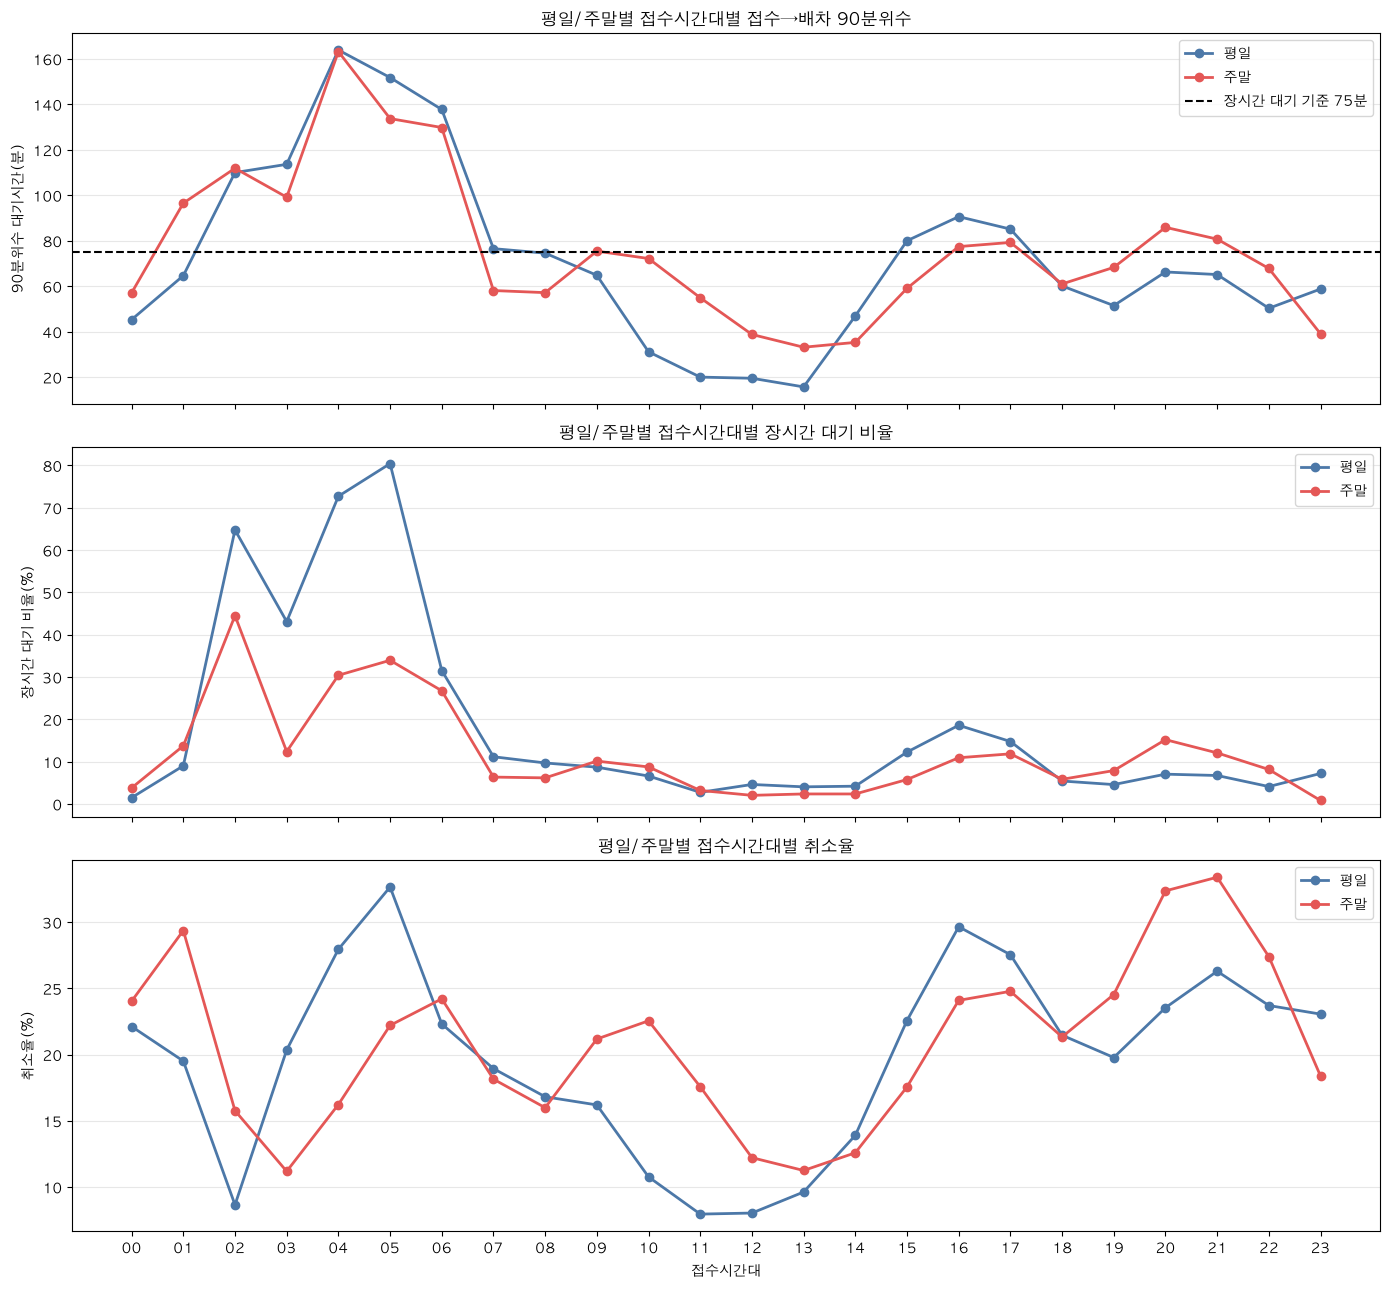

In [73]:
# 코드 셀 목적: 평일/주말별 접수→배차 대기시간, 장시간 대기 비율, 취소율을 함께 비교한다.

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

plot_configs = [
    {
        "summary": baro_weekday_hour_summary,
        "metric": "접수_배차_90분위수",
        "ylabel": "90분위수 대기시간(분)",
        "title": "평일/주말별 접수시간대별 접수→배차 90분위수",
        "threshold": long_wait_threshold,
    },
    {
        "summary": baro_weekday_hour_summary,
        "metric": "장시간대기비율(%)",
        "ylabel": "장시간 대기 비율(%)",
        "title": "평일/주말별 접수시간대별 장시간 대기 비율",
        "threshold": None,
    },
    {
        "summary": baro_weekday_hour_cancel_summary,
        "metric": "취소율(%)",
        "ylabel": "취소율(%)",
        "title": "평일/주말별 접수시간대별 취소율",
        "threshold": None,
    },
]

for ax, config in zip(axes, plot_configs):
    for label, color in [("평일", "#4c78a8"), ("주말", "#e45756")]:
        plot_data = config["summary"][
            config["summary"]["평일주말"].eq(label)
        ]

        ax.plot(
            plot_data["접수시간대_HH"].astype(str),
            plot_data[config["metric"]],
            marker="o",
            linewidth=2,
            color=color,
            label=label,
        )

    if config["threshold"] is not None:
        ax.axhline(
            config["threshold"],
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=f"장시간 대기 기준 {config['threshold']}분",
        )

    ax.set_title(config["title"])
    ax.set_ylabel(config["ylabel"])
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("접수시간대")

plt.tight_layout()
plt.show()

평일/주말별 접수시간대 패턴을 비교한 결과,
04~06시의 장시간 대기는 평일과 주말 모두에서 공통적으로 나타났다.
이는 특정 요일 수요보다는 새벽 시간대의 배차 가능 차량 부족 또는 운영 공백과 관련된 구조적 취약 시간대로 해석된다.

다만 오후·저녁 시간대에서는 평일과 주말의 양상이 달랐다.
평일은 15~17시에 접수→배차 90분위수와 취소율이 함께 상승하여,
평일 오후 시간대의 운영 부담과 서비스 이탈 위험이 확인되었다.
반면 주말은 20~21시에 취소율이 크게 상승해,
주말 저녁 시간대에는 대기시간 외에도 이용 목적 변경이나 대체 이동수단 확보 등 다른 취소 요인을 추가로 검토할 필요가 있다.

따라서 시간대별 관리 전략은 평일과 주말을 구분해 설정할 필요가 있으며,
공통 취약 구간인 04~06시와 평일 15~17시, 주말 20~21시를 우선 검토 시간대로 볼 수 있다.

## 8. 요일별 대기시간 분석

요일별로 특장차 바로콜 후보의 승차 완료건수와 대기시간을 비교한다. 평일과 주말은 이용 목적과 차량 운영 패턴이 다를 수 있다.


In [74]:
# 코드 셀 목적: 특장차 바로콜 후보의 요일별 승차완료건수와 대기시간을 확인한다.

weekday_order = ["월", "화", "수", "목", "금", "토", "일"]
special_ride_baro_call["접수요일"] = pd.Categorical(
    special_ride_baro_call["접수요일"],
    categories=weekday_order,
    ordered=True,
)

weekday_baro_summary = (
    special_ride_baro_call
    .groupby("접수요일", observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(weekday_baro_summary)


,접수요일,승차완료건수,접수_배차_중앙값,접수_배차_90분위수,접수_승차_중앙값,접수_승차_90분위수
0,월,187531,10.522383,72.700117,31.599500,94.913717
1,화,184885,12.147500,71.966537,33.281550,95.235033
2,수,190139,12.781783,75.669243,33.838833,98.865750
3,목,180334,11.160975,71.709948,32.411692,95.083698
4,금,183115,12.346117,76.765273,33.597617,100.781393
5,토,91178,13.245358,64.079250,36.286525,88.380100
6,일,81902,12.946442,62.668233,34.755083,84.340600


## 8-1. 바로콜 요일별 대기시간 확인

접수시간대별 분석에 이어, 바로콜 후보의 대기시간이 요일별로 차이가 있는지 확인한다.

요일별 분석은 특정 시간대의 장시간 대기가 평일 전체에서 반복되는 문제인지, 특정 요일에 집중되는 문제인지 구분하는 데 필요하다. 특히 특장차는 병원 진료, 통원, 복지시설 이동 등 평일 목적성 이동과 연결될 가능성이 있으므로, 월~금과 주말의 대기시간 차이를 함께 확인한다.

여기서는 요일별 승차완료건수와 `접수→배차`, `접수→승차`, `배차→승차` 대기시간의 중앙값 및 90분위수를 비교한다.

In [75]:
# 코드 셀 목적: 특장차 바로콜 후보의 요일별 대기시간과 장시간 대기 비율을 확인한다.

long_wait_threshold = 75

baro_wait_by_weekday = special_ride_baro_call.copy()

baro_wait_by_weekday["접수일시"] = pd.to_datetime(
    baro_wait_by_weekday["접수일시"],
    errors="coerce",
)

for col in ["접수_배차_분", "접수_승차_분", "배차_승차_분"]:
    baro_wait_by_weekday[col] = pd.to_numeric(
        baro_wait_by_weekday[col],
        errors="coerce",
    )

baro_wait_by_weekday = baro_wait_by_weekday[
    baro_wait_by_weekday["접수일시"].notna()
    & baro_wait_by_weekday["접수_배차_분"].notna()
    & baro_wait_by_weekday["접수_배차_분"].ge(0)
].copy()

weekday_order = ["월", "화", "수", "목", "금", "토", "일"]

baro_wait_by_weekday["접수요일"] = pd.Categorical(
    baro_wait_by_weekday["접수일시"].dt.day_name().map({
        "Monday": "월",
        "Tuesday": "화",
        "Wednesday": "수",
        "Thursday": "목",
        "Friday": "금",
        "Saturday": "토",
        "Sunday": "일",
    }),
    categories=weekday_order,
    ordered=True,
)

baro_wait_by_weekday["장시간대기여부"] = (
    baro_wait_by_weekday["접수_배차_분"].ge(long_wait_threshold)
)

baro_weekday_wait_summary = (
    baro_wait_by_weekday
    .groupby("접수요일", observed=False)
    .agg(
        승차완료건수=("접수_배차_분", "count"),
        장시간대기건수=("장시간대기여부", "sum"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_75분위수=("접수_배차_분", lambda x: x.quantile(0.75)),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

baro_weekday_wait_summary["장시간대기비율(%)"] = (
    baro_weekday_wait_summary["장시간대기건수"]
    / baro_weekday_wait_summary["승차완료건수"].replace(0, pd.NA)
    * 100
)

display(baro_weekday_wait_summary.round(2))

,접수요일,승차완료건수,장시간대기건수,접수_배차_중앙값,접수_배차_75분위수,접수_배차_90분위수,접수_승차_중앙값,접수_승차_90분위수,배차_승차_중앙값,배차_승차_90분위수,장시간대기비율(%)
0,월,187531,17454,10.52,36.91,72.70,31.60,94.91,17.24,28.47,9.31
1,화,184885,16992,12.15,37.32,71.97,33.28,95.24,17.66,29.17,9.19
2,수,190139,19398,12.78,40.14,75.67,33.84,98.87,17.71,29.21,10.20
3,목,180334,16346,11.16,35.87,71.71,32.41,95.08,17.59,29.26,9.06
4,금,183115,19134,12.35,37.95,76.77,33.60,100.78,17.87,29.72,10.45
5,토,91178,6542,13.25,33.91,64.08,36.29,88.38,19.51,31.67,7.17
6,일,81902,5125,12.95,33.33,62.67,34.76,84.34,18.71,29.61,6.26


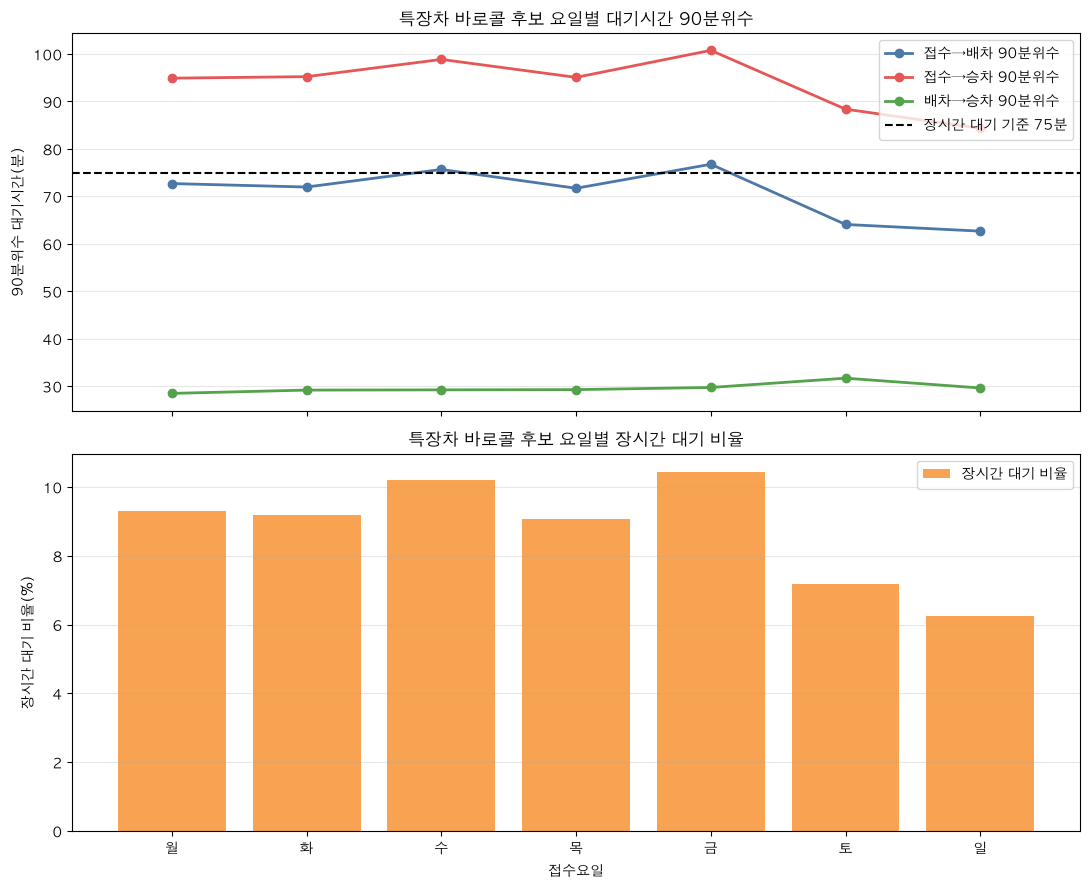

In [76]:
# 코드 셀 목적: 특장차 바로콜 후보의 요일별 대기시간과 장시간 대기 비율을 시각화한다.

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

axes[0].plot(
    baro_weekday_wait_summary["접수요일"].astype(str),
    baro_weekday_wait_summary["접수_배차_90분위수"],
    marker="o",
    linewidth=2,
    color="#4c78a8",
    label="접수→배차 90분위수",
)

axes[0].plot(
    baro_weekday_wait_summary["접수요일"].astype(str),
    baro_weekday_wait_summary["접수_승차_90분위수"],
    marker="o",
    linewidth=2,
    color="#e45756",
    label="접수→승차 90분위수",
)

axes[0].plot(
    baro_weekday_wait_summary["접수요일"].astype(str),
    baro_weekday_wait_summary["배차_승차_90분위수"],
    marker="o",
    linewidth=2,
    color="#54a24b",
    label="배차→승차 90분위수",
)

axes[0].axhline(
    long_wait_threshold,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"장시간 대기 기준 {long_wait_threshold}분",
)

axes[0].set_title("특장차 바로콜 후보 요일별 대기시간 90분위수")
axes[0].set_ylabel("90분위수 대기시간(분)")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

axes[1].bar(
    baro_weekday_wait_summary["접수요일"].astype(str),
    baro_weekday_wait_summary["장시간대기비율(%)"],
    color="#f58518",
    alpha=0.75,
    label="장시간 대기 비율",
)

axes[1].set_title("특장차 바로콜 후보 요일별 장시간 대기 비율")
axes[1].set_xlabel("접수요일")
axes[1].set_ylabel("장시간 대기 비율(%)")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

특장차 바로콜 후보의 요일별 대기시간을 비교한 결과,
접수→배차 90분위수는 평일에는 장시간 대기 기준인 75분 전후로 나타났으나,
주말에는 60분대 초반으로 낮아졌다.

접수→승차 90분위수 역시 평일, 특히 수요일과 금요일에 높게 나타났으며,
장시간 대기 비율도 수요일과 금요일에서 상대적으로 높았다.
반면 토요일과 일요일은 접수→배차 90분위수와 장시간 대기 비율이 모두 낮아,
주말에는 바로콜 장시간 대기 부담이 상대적으로 완화되는 것으로 해석된다.

배차→승차 90분위수는 요일별 차이가 크지 않아,
요일별 장시간 대기 차이는 배차 이후 이동 단계보다 접수→배차 단계에서 주로 발생하는 것으로 판단된다.

## 8-2. 바로콜 요일별 취소 대기시간 확인

바로콜 취소 건은 실제 승차로 이어지지 않았기 때문에 `접수→승차` 대기시간을 볼 수 없다. 따라서 취소 분석에서는 `접수→취소` 대기시간과 `배차→취소` 시간을 중심으로 확인한다.

`접수→취소`는 이용자가 접수 후 어느 시점에 취소했는지를 보여준다. 이 값이 길다면 이용자가 일정 시간 대기하다가 취소했을 가능성이 있다.

`배차→취소`는 차량이 배정된 뒤 취소까지 걸린 시간을 보여준다. 이 값이 짧다면 배차 알림 직후 취소 또는 배차 정보 확인 후 취소 가능성을 의심할 수 있다.

요일별로 취소 대기시간을 확인하면 특정 요일에 대기 후 취소가 집중되는지, 또는 배차 직후 취소가 특정 요일에 더 강하게 나타나는지를 파악할 수 있다.

In [77]:
# 코드 셀 목적: 특장차 바로콜 취소 후보의 요일별 접수→취소, 배차→취소 시간을 확인한다.

baro_cancel_wait_by_weekday = special_cancel_baro_call.copy()

baro_cancel_wait_by_weekday["접수일시"] = pd.to_datetime(
    baro_cancel_wait_by_weekday["접수일시"],
    errors="coerce",
)
baro_cancel_wait_by_weekday["배차일시"] = pd.to_datetime(
    baro_cancel_wait_by_weekday["배차일시"],
    errors="coerce",
)
baro_cancel_wait_by_weekday["취소일시"] = pd.to_datetime(
    baro_cancel_wait_by_weekday["취소일시"],
    errors="coerce",
)

for col in ["접수_취소_분", "배차_취소_분", "접수_배차_분"]:
    baro_cancel_wait_by_weekday[col] = pd.to_numeric(
        baro_cancel_wait_by_weekday[col],
        errors="coerce",
    )

weekday_order = ["월", "화", "수", "목", "금", "토", "일"]

baro_cancel_wait_by_weekday["접수요일"] = pd.Categorical(
    baro_cancel_wait_by_weekday["접수일시"].dt.day_name().map({
        "Monday": "월",
        "Tuesday": "화",
        "Wednesday": "수",
        "Thursday": "목",
        "Friday": "금",
        "Saturday": "토",
        "Sunday": "일",
    }),
    categories=weekday_order,
    ordered=True,
)

baro_cancel_wait_by_weekday["배차후취소여부"] = (
    baro_cancel_wait_by_weekday["배차일시"].notna()
    & baro_cancel_wait_by_weekday["취소일시"].notna()
    & baro_cancel_wait_by_weekday["배차_취소_분"].ge(0)
)

baro_cancel_wait_by_weekday["배차직후_0_5분_취소여부"] = (
    baro_cancel_wait_by_weekday["배차후취소여부"]
    & baro_cancel_wait_by_weekday["배차_취소_분"].between(0, 5, inclusive="both")
)

baro_cancel_weekday_wait_summary = (
    baro_cancel_wait_by_weekday
    .groupby("접수요일", observed=False)
    .agg(
        취소건수=("취소일시", "count"),
        접수_취소_중앙값=("접수_취소_분", "median"),
        접수_취소_75분위수=("접수_취소_분", lambda x: x.quantile(0.75)),
        접수_취소_90분위수=("접수_취소_분", lambda x: x.quantile(0.90)),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        배차후취소건수=("배차후취소여부", "sum"),
        배차_취소_중앙값=("배차_취소_분", "median"),
        배차_취소_75분위수=("배차_취소_분", lambda x: x.quantile(0.75)),
        배차_취소_90분위수=("배차_취소_분", lambda x: x.quantile(0.90)),
        배차직후_0_5분_취소건수=("배차직후_0_5분_취소여부", "sum"),
    )
    .reset_index()
)

baro_cancel_weekday_wait_summary["배차후취소비율(%)"] = (
    baro_cancel_weekday_wait_summary["배차후취소건수"]
    / baro_cancel_weekday_wait_summary["취소건수"].replace(0, pd.NA)
    * 100
)

baro_cancel_weekday_wait_summary["배차직후_0_5분_취소비율(%)"] = (
    baro_cancel_weekday_wait_summary["배차직후_0_5분_취소건수"]
    / baro_cancel_weekday_wait_summary["배차후취소건수"].replace(0, pd.NA)
    * 100
)

display(baro_cancel_weekday_wait_summary.round(2))

,접수요일,취소건수,접수_취소_중앙값,접수_취소_75분위수,접수_취소_90분위수,접수_배차_중앙값,접수_배차_90분위수,배차후취소건수,배차_취소_중앙값,배차_취소_75분위수,배차_취소_90분위수,배차직후_0_5분_취소건수,배차후취소비율(%),배차직후_0_5분_취소비율(%)
0,월,33217,12.30,38.64,83.60,11.49,93.56,8036,2.54,5.96,14.08,5750,24.19,71.55
1,화,34845,14.10,40.42,84.17,12.97,97.68,8016,2.42,5.72,14.58,5790,23.00,72.23
2,수,37558,15.29,43.96,89.03,13.97,103.10,8420,2.48,5.63,14.01,6119,22.42,72.67
3,목,35426,13.26,39.12,82.15,12.60,102.82,8157,2.50,5.66,14.32,5898,23.03,72.31
4,금,39611,14.62,43.08,89.76,14.14,123.66,8677,2.51,5.80,13.98,6239,21.91,71.90
5,토,21189,12.03,32.58,62.04,12.44,74.95,4774,2.59,6.71,15.27,3321,22.53,69.56
6,일,17799,13.28,34.18,61.60,13.05,73.63,4046,2.65,7.26,15.06,2757,22.73,68.14


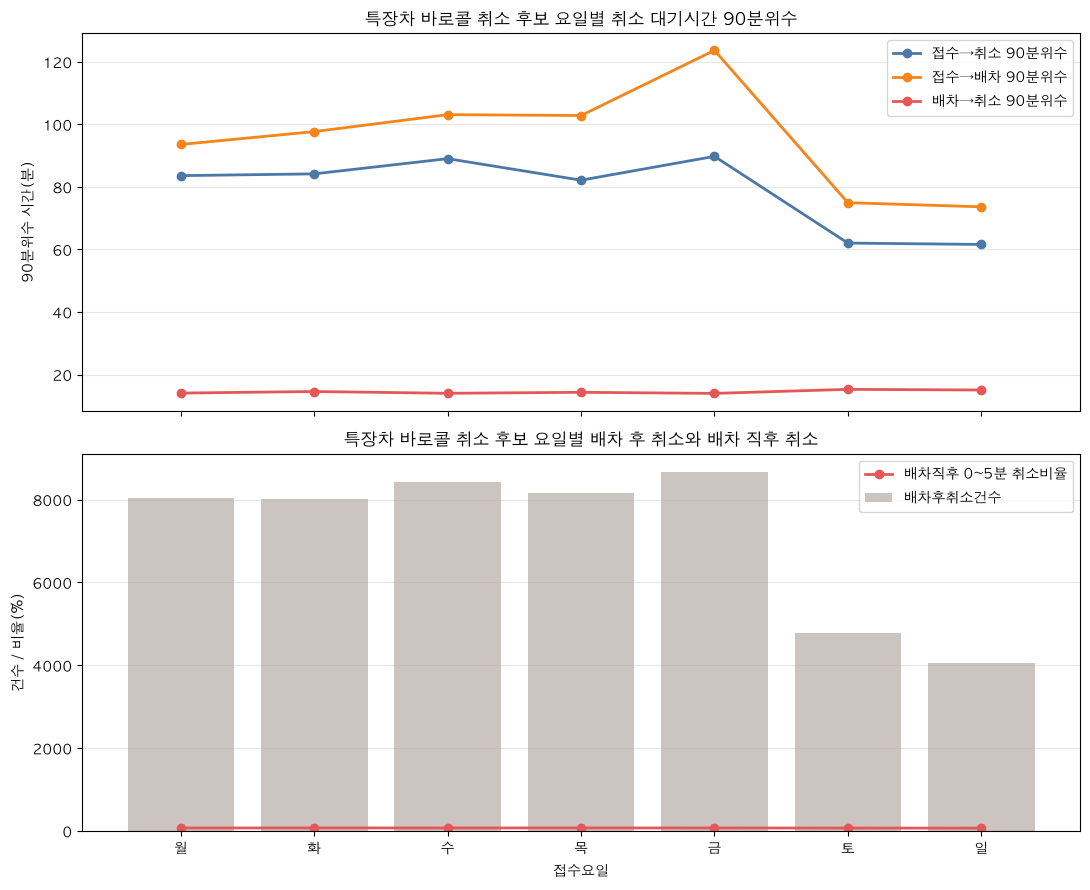

In [78]:
# 코드 셀 목적: 특장차 바로콜 취소 후보의 요일별 취소 대기시간을 시각화한다.

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

axes[0].plot(
    baro_cancel_weekday_wait_summary["접수요일"].astype(str),
    baro_cancel_weekday_wait_summary["접수_취소_90분위수"],
    marker="o",
    linewidth=2,
    color="#4c78a8",
    label="접수→취소 90분위수",
)

axes[0].plot(
    baro_cancel_weekday_wait_summary["접수요일"].astype(str),
    baro_cancel_weekday_wait_summary["접수_배차_90분위수"],
    marker="o",
    linewidth=2,
    color="#f58518",
    label="접수→배차 90분위수",
)

axes[0].plot(
    baro_cancel_weekday_wait_summary["접수요일"].astype(str),
    baro_cancel_weekday_wait_summary["배차_취소_90분위수"],
    marker="o",
    linewidth=2,
    color="#e45756",
    label="배차→취소 90분위수",
)

axes[0].set_title("특장차 바로콜 취소 후보 요일별 취소 대기시간 90분위수")
axes[0].set_ylabel("90분위수 시간(분)")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

axes[1].bar(
    baro_cancel_weekday_wait_summary["접수요일"].astype(str),
    baro_cancel_weekday_wait_summary["배차후취소건수"],
    color="#bab0ab",
    alpha=0.75,
    label="배차후취소건수",
)

axes[1].plot(
    baro_cancel_weekday_wait_summary["접수요일"].astype(str),
    baro_cancel_weekday_wait_summary["배차직후_0_5분_취소비율(%)"],
    marker="o",
    linewidth=2,
    color="#e45756",
    label="배차직후 0~5분 취소비율",
)

axes[1].set_title("특장차 바로콜 취소 후보 요일별 배차 후 취소와 배차 직후 취소")
axes[1].set_xlabel("접수요일")
axes[1].set_ylabel("건수 / 비율(%)")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

특장차 바로콜 취소 후보의 요일별 취소 대기시간을 비교한 결과,
평일은 주말보다 접수→취소 및 접수→배차 90분위수가 높게 나타났다.
특히 금요일은 접수→배차 90분위수가 가장 높아,
취소 건 중에서도 배차 전 대기시간이 긴 사례가 집중되는 요일로 확인된다.

반면 배차→취소 90분위수는 모든 요일에서 15분 내외로 유사하게 나타나,
요일별 취소 대기시간 차이는 배차 이후보다 접수 후 배차 전 단계에서 주로 발생하는 것으로 해석된다.

배차후취소건수는 평일이 주말보다 많아,
평일의 높은 이용 규모와 배차 운영 부담이 취소 규모 증가로 이어진 것으로 볼 수 있다.

## 8-3. 전일접수 요일별 예정시각 기준 대기시간

전일접수 후보는 예약성 접수이므로 바로콜처럼 접수시각 기준의 `접수→배차`, `접수→승차` 대기시간을 그대로 해석하기 어렵다. 전일접수는 실제 이용 예정시각이 존재하므로, 요일별 대기시간은 `예정일시`를 기준으로 배차와 승차가 얼마나 빠르거나 늦게 이루어졌는지를 중심으로 확인한다.

따라서 본 분석에서는 `예정대비 배차`, `예정대비 승차`, `배차→승차`를 요일별로 비교한다. `예정대비 배차`와 `예정대비 승차`가 0보다 크면 예정시각 이후에 배차 또는 승차가 이루어진 것으로 해석하며, 이는 예약 이용자의 체감 지연과 직접적으로 연결될 수 있다.

In [79]:
# 코드 셀 목적: 특장차 전일접수 후보의 요일별 예정시각 기준 배차·승차 시간과 지연 비율을 확인한다.

previous_day_delay_threshold = 0

previous_day_wait_by_weekday = special_ride_previous_day.copy()

for col in ["접수일시", "예정일시", "배차일시", "승차일시"]:
    previous_day_wait_by_weekday[col] = pd.to_datetime(
        previous_day_wait_by_weekday[col],
        errors="coerce",
    )

previous_day_wait_by_weekday["배차_승차_분"] = pd.to_numeric(
    previous_day_wait_by_weekday["배차_승차_분"],
    errors="coerce",
)

previous_day_wait_by_weekday = previous_day_wait_by_weekday[
    previous_day_wait_by_weekday["예정일시"].notna()
    & previous_day_wait_by_weekday["배차일시"].notna()
    & previous_day_wait_by_weekday["승차일시"].notna()
    & previous_day_wait_by_weekday["배차_승차_분"].notna()
    & previous_day_wait_by_weekday["배차_승차_분"].ge(0)
].copy()

previous_day_wait_by_weekday["예정시각기준_배차_분"] = (
    previous_day_wait_by_weekday["배차일시"]
    - previous_day_wait_by_weekday["예정일시"]
).dt.total_seconds() / 60

previous_day_wait_by_weekday["예정시각기준_승차_분"] = (
    previous_day_wait_by_weekday["승차일시"]
    - previous_day_wait_by_weekday["예정일시"]
).dt.total_seconds() / 60

weekday_order = ["월", "화", "수", "목", "금", "토", "일"]

previous_day_wait_by_weekday["접수요일"] = pd.Categorical(
    previous_day_wait_by_weekday["접수일시"].dt.day_name().map({
        "Monday": "월",
        "Tuesday": "화",
        "Wednesday": "수",
        "Thursday": "목",
        "Friday": "금",
        "Saturday": "토",
        "Sunday": "일",
    }),
    categories=weekday_order,
    ordered=True,
)

previous_day_wait_by_weekday["예정이후배차여부"] = (
    previous_day_wait_by_weekday["예정시각기준_배차_분"] > previous_day_delay_threshold
)

previous_day_wait_by_weekday["예정이후승차여부"] = (
    previous_day_wait_by_weekday["예정시각기준_승차_분"] > previous_day_delay_threshold
)

previous_day_weekday_wait_summary = (
    previous_day_wait_by_weekday
    .groupby("접수요일", observed=False)
    .agg(
        승차완료건수=("예정시각기준_승차_분", "count"),
        예정시각기준_배차_중앙값=("예정시각기준_배차_분", "median"),
        예정시각기준_배차_75분위수=("예정시각기준_배차_분", lambda x: x.quantile(0.75)),
        예정시각기준_배차_90분위수=("예정시각기준_배차_분", lambda x: x.quantile(0.90)),
        예정시각기준_승차_중앙값=("예정시각기준_승차_분", "median"),
        예정시각기준_승차_75분위수=("예정시각기준_승차_분", lambda x: x.quantile(0.75)),
        예정시각기준_승차_90분위수=("예정시각기준_승차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
        예정이후배차건수=("예정이후배차여부", "sum"),
        예정이후승차건수=("예정이후승차여부", "sum"),
    )
    .reset_index()
)

previous_day_weekday_wait_summary["예정이후배차비율(%)"] = (
    previous_day_weekday_wait_summary["예정이후배차건수"]
    / previous_day_weekday_wait_summary["승차완료건수"].replace(0, pd.NA)
    * 100
)

previous_day_weekday_wait_summary["예정이후승차비율(%)"] = (
    previous_day_weekday_wait_summary["예정이후승차건수"]
    / previous_day_weekday_wait_summary["승차완료건수"].replace(0, pd.NA)
    * 100
)

display(previous_day_weekday_wait_summary.round(2))

,접수요일,승차완료건수,예정시각기준_배차_중앙값,예정시각기준_배차_75분위수,예정시각기준_배차_90분위수,예정시각기준_승차_중앙값,예정시각기준_승차_75분위수,예정시각기준_승차_90분위수,배차_승차_중앙값,배차_승차_90분위수,예정이후배차건수,예정이후승차건수,예정이후배차비율(%),예정이후승차비율(%)
0,월,8837,6.24,9.10,9.83,24.23,30.52,37.38,18.63,29.42,7844,8828,88.76,99.90
1,화,8924,5.91,9.05,9.80,23.59,29.93,36.56,18.35,29.01,7754,8916,86.89,99.91
2,수,8549,6.20,9.10,9.70,23.71,30.11,36.82,18.21,28.96,7609,8543,89.00,99.93
3,목,8556,6.05,9.04,9.75,23.79,30.10,36.46,18.36,28.89,7463,8542,87.23,99.84
4,금,2616,6.10,8.89,11.43,23.23,29.59,37.45,18.21,28.07,2153,2612,82.30,99.85
5,토,3097,5.32,9.06,14.18,23.50,31.25,39.78,19.26,29.01,2452,3090,79.17,99.77
6,일,8352,5.89,9.09,9.88,23.95,30.70,37.75,18.46,29.81,7400,8347,88.60,99.94


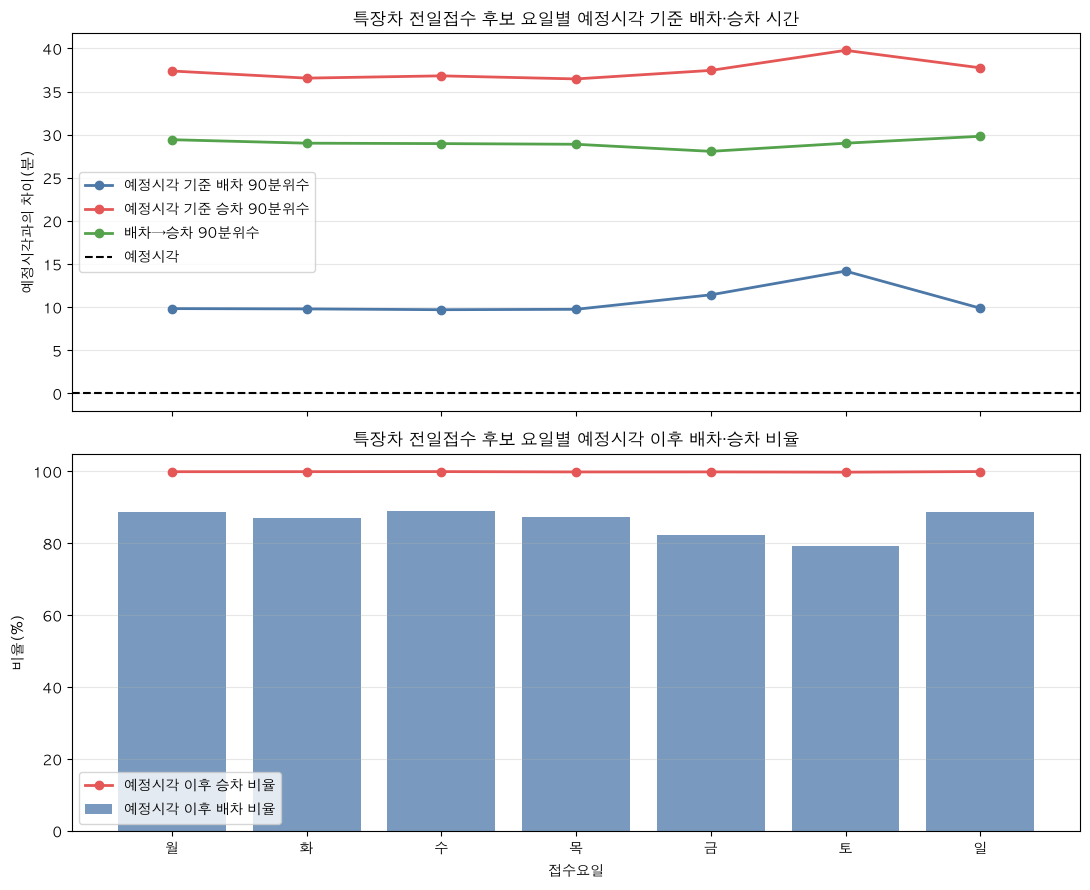

In [80]:
# 코드 셀 목적: 특장차 전일접수 후보의 요일별 예정시각 기준 배차·승차 지연을 시각화한다.

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

axes[0].plot(
    previous_day_weekday_wait_summary["접수요일"].astype(str),
    previous_day_weekday_wait_summary["예정시각기준_배차_90분위수"],
    marker="o",
    linewidth=2,
    color="#4c78a8",
    label="예정시각 기준 배차 90분위수",
)

axes[0].plot(
    previous_day_weekday_wait_summary["접수요일"].astype(str),
    previous_day_weekday_wait_summary["예정시각기준_승차_90분위수"],
    marker="o",
    linewidth=2,
    color="#e45756",
    label="예정시각 기준 승차 90분위수",
)

axes[0].plot(
    previous_day_weekday_wait_summary["접수요일"].astype(str),
    previous_day_weekday_wait_summary["배차_승차_90분위수"],
    marker="o",
    linewidth=2,
    color="#54a24b",
    label="배차→승차 90분위수",
)

axes[0].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="예정시각",
)

axes[0].set_title("특장차 전일접수 후보 요일별 예정시각 기준 배차·승차 시간")
axes[0].set_ylabel("예정시각과의 차이(분)")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

axes[1].bar(
    previous_day_weekday_wait_summary["접수요일"].astype(str),
    previous_day_weekday_wait_summary["예정이후배차비율(%)"],
    color="#4c78a8",
    alpha=0.75,
    label="예정시각 이후 배차 비율",
)

axes[1].plot(
    previous_day_weekday_wait_summary["접수요일"].astype(str),
    previous_day_weekday_wait_summary["예정이후승차비율(%)"],
    marker="o",
    linewidth=2,
    color="#e45756",
    label="예정시각 이후 승차 비율",
)

axes[1].set_title("특장차 전일접수 후보 요일별 예정시각 이후 배차·승차 비율")
axes[1].set_xlabel("접수요일")
axes[1].set_ylabel("비율(%)")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

```text
파란 막대: 예정시각 이후 배차 비율
= 배차일시가 예정일시보다 늦은 건 / 전체 전일접수 승차완료 건 × 100

빨간 선: 예정시각 이후 승차 비율
= 승차일시가 예정일시보다 늦은 건 / 전체 전일접수 승차완료 건 × 100
```

전일접수 후보의 요일별 예정시각 기준 배차·승차 시간을 분석한 결과,
예정시각 기준 배차 90분위수는 모든 요일에서 약 10~15분 수준으로 나타났다.
이는 늦게 배차되는 상위 10% 건도 대부분 예정시각 이후 15분 이내에 배차됨을 의미한다.

반면 예정시각 기준 승차 90분위수는 약 36~40분으로,
배차→승차 90분위수 약 28~30분이 더해지면서 실제 승차는 예정시각보다 30분 이상 늦어지는 구조가 확인된다.

예정시각 이후 배차 비율은 대부분 요일에서 80~90% 수준이고,
예정시각 이후 승차 비율은 거의 100%로 나타났다.
따라서 전일접수 후보는 대부분 예정시각 이후에 배차 및 승차가 이루어지는 구조로 해석된다.

## 8-4. 전일접수 요일별 취소 대기시간

전일접수 취소 후보는 예약성 접수이므로 취소 대기시간을 바로콜과 동일하게 해석하면 안 된다. 특히 전일접수는 실제 이용 예정시각이 존재하므로, `접수→취소`, `접수→배차`, `배차→취소`뿐 아니라 `예정대비 취소시점`과 `예정대비 배차시점`을 함께 확인하는 것이 중요하다.

요일별 취소 대기시간 분석은 특정 요일에 배차 전 장시간 대기 후 취소가 집중되는지, 또는 예정시각에 임박한 취소·배차 직후 취소가 특정 요일에 더 많이 나타나는지를 확인하기 위한 것이다.

In [81]:
# 코드 셀 목적: 특장차 전일접수 취소 후보의 요일별 예정시각 기준 취소 대기시간을 확인한다.

previous_day_cancel_wait_by_weekday = special_cancel_previous_day.copy()

for col in ["접수일시", "예정일시", "배차일시", "취소일시"]:
    previous_day_cancel_wait_by_weekday[col] = pd.to_datetime(
        previous_day_cancel_wait_by_weekday[col],
        errors="coerce",
    )

for col in ["접수_취소_분", "배차_취소_분"]:
    previous_day_cancel_wait_by_weekday[col] = pd.to_numeric(
        previous_day_cancel_wait_by_weekday[col],
        errors="coerce",
    )

previous_day_cancel_wait_by_weekday = previous_day_cancel_wait_by_weekday[
    previous_day_cancel_wait_by_weekday["접수일시"].notna()
    & previous_day_cancel_wait_by_weekday["예정일시"].notna()
    & previous_day_cancel_wait_by_weekday["취소일시"].notna()
].copy()

previous_day_cancel_wait_by_weekday["예정시각기준_배차_분"] = (
    previous_day_cancel_wait_by_weekday["배차일시"]
    - previous_day_cancel_wait_by_weekday["예정일시"]
).dt.total_seconds() / 60

previous_day_cancel_wait_by_weekday["예정시각기준_취소_분"] = (
    previous_day_cancel_wait_by_weekday["취소일시"]
    - previous_day_cancel_wait_by_weekday["예정일시"]
).dt.total_seconds() / 60

weekday_order = ["월", "화", "수", "목", "금", "토", "일"]

previous_day_cancel_wait_by_weekday["접수요일"] = pd.Categorical(
    previous_day_cancel_wait_by_weekday["접수일시"].dt.day_name().map({
        "Monday": "월",
        "Tuesday": "화",
        "Wednesday": "수",
        "Thursday": "목",
        "Friday": "금",
        "Saturday": "토",
        "Sunday": "일",
    }),
    categories=weekday_order,
    ordered=True,
)

previous_day_cancel_wait_by_weekday["배차후취소여부"] = (
    previous_day_cancel_wait_by_weekday["배차일시"].notna()
    & previous_day_cancel_wait_by_weekday["취소일시"].notna()
    & previous_day_cancel_wait_by_weekday["배차_취소_분"].ge(0)
)

previous_day_cancel_wait_by_weekday["배차직후_0_5분_취소여부"] = (
    previous_day_cancel_wait_by_weekday["배차후취소여부"]
    & previous_day_cancel_wait_by_weekday["배차_취소_분"].between(0, 5, inclusive="both")
)

previous_day_cancel_weekday_wait_summary = (
    previous_day_cancel_wait_by_weekday
    .groupby("접수요일", observed=False)
    .agg(
        취소건수=("취소일시", "count"),
        접수_취소_중앙값=("접수_취소_분", "median"),
        접수_취소_90분위수=("접수_취소_분", lambda x: x.quantile(0.90)),
        예정시각기준_배차_중앙값=("예정시각기준_배차_분", "median"),
        예정시각기준_배차_90분위수=("예정시각기준_배차_분", lambda x: x.quantile(0.90)),
        예정시각기준_취소_중앙값=("예정시각기준_취소_분", "median"),
        예정시각기준_취소_90분위수=("예정시각기준_취소_분", lambda x: x.quantile(0.90)),
        배차후취소건수=("배차후취소여부", "sum"),
        배차_취소_중앙값=("배차_취소_분", "median"),
        배차_취소_90분위수=("배차_취소_분", lambda x: x.quantile(0.90)),
        배차직후_0_5분_취소건수=("배차직후_0_5분_취소여부", "sum"),
    )
    .reset_index()
)

previous_day_cancel_weekday_wait_summary["배차후취소비율(%)"] = (
    previous_day_cancel_weekday_wait_summary["배차후취소건수"]
    / previous_day_cancel_weekday_wait_summary["취소건수"].replace(0, pd.NA)
    * 100
)

previous_day_cancel_weekday_wait_summary["배차직후_0_5분_취소비율(%)"] = (
    previous_day_cancel_weekday_wait_summary["배차직후_0_5분_취소건수"]
    / previous_day_cancel_weekday_wait_summary["배차후취소건수"].replace(0, pd.NA)
    * 100
)

display(previous_day_cancel_weekday_wait_summary.round(2))

,접수요일,취소건수,접수_취소_중앙값,접수_취소_90분위수,예정시각기준_배차_중앙값,예정시각기준_배차_90분위수,예정시각기준_취소_중앙값,예정시각기준_취소_90분위수,배차후취소건수,배차_취소_중앙값,배차_취소_90분위수,배차직후_0_5분_취소건수,배차후취소비율(%),배차직후_0_5분_취소비율(%)
0,월,983,1265.32,1444.47,6.34,24.22,-147.70,7.85,134,3.17,20.37,80,13.63,59.70
1,화,930,1307.82,1440.28,5.37,11.58,-116.69,4.19,110,2.81,14.52,74,11.83,67.27
2,수,1053,1288.32,1438.72,5.07,12.22,-126.05,2.92,106,2.96,14.73,73,10.07,68.87
3,목,1037,1284.68,1438.77,5.10,9.70,-126.68,2.55,111,3.70,16.14,69,10.70,62.16
4,금,584,1091.21,1443.61,3.49,12.88,-302.75,4.16,70,3.60,18.82,44,11.99,62.86
5,토,572,1350.21,1441.34,3.52,27.63,-69.33,3.52,60,2.52,15.50,43,10.49,71.67
6,일,779,1351.38,1443.64,5.97,12.61,-73.75,11.43,121,5.49,22.02,59,15.53,48.76


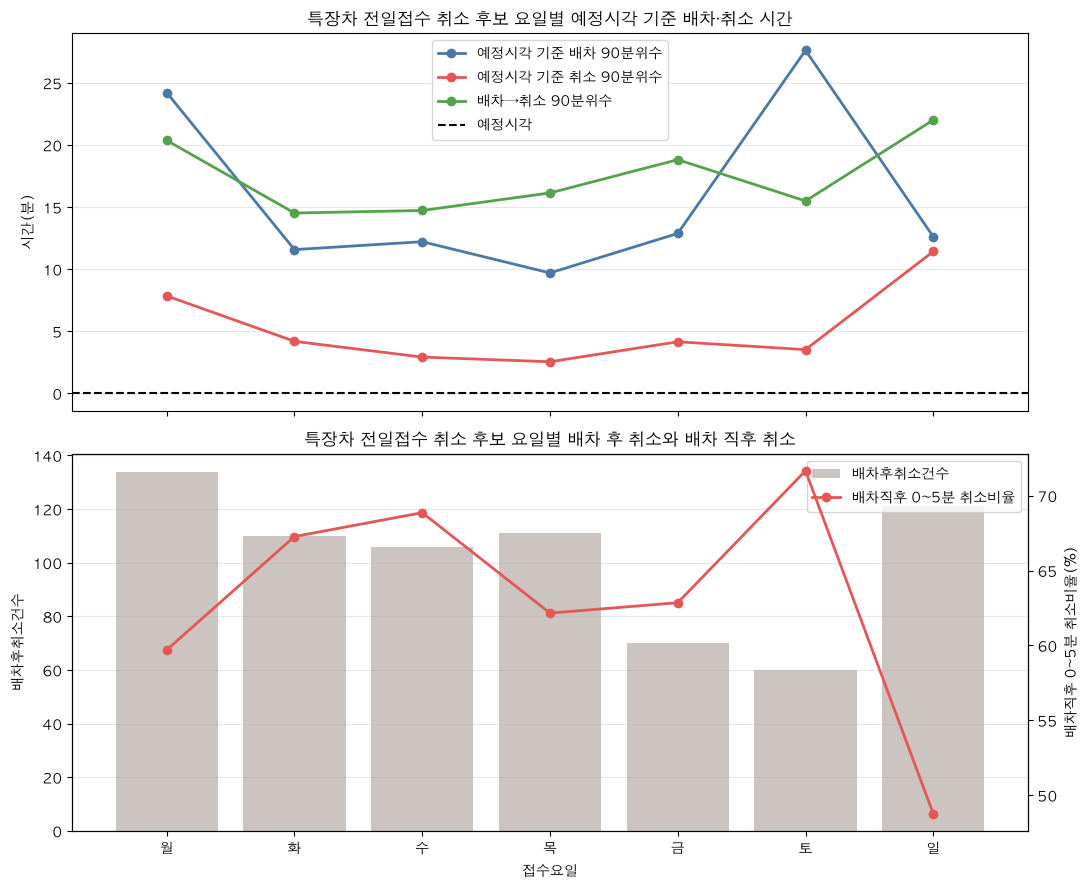

In [82]:
# 코드 셀 목적: 특장차 전일접수 취소 후보의 요일별 예정시각 기준 취소 패턴을 시각화한다.

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

axes[0].plot(
    previous_day_cancel_weekday_wait_summary["접수요일"].astype(str),
    previous_day_cancel_weekday_wait_summary["예정시각기준_배차_90분위수"],
    marker="o",
    linewidth=2,
    color="#4c78a8",
    label="예정시각 기준 배차 90분위수",
)

axes[0].plot(
    previous_day_cancel_weekday_wait_summary["접수요일"].astype(str),
    previous_day_cancel_weekday_wait_summary["예정시각기준_취소_90분위수"],
    marker="o",
    linewidth=2,
    color="#e45756",
    label="예정시각 기준 취소 90분위수",
)

axes[0].plot(
    previous_day_cancel_weekday_wait_summary["접수요일"].astype(str),
    previous_day_cancel_weekday_wait_summary["배차_취소_90분위수"],
    marker="o",
    linewidth=2,
    color="#54a24b",
    label="배차→취소 90분위수",
)

axes[0].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="예정시각",
)

axes[0].set_title("특장차 전일접수 취소 후보 요일별 예정시각 기준 배차·취소 시간")
axes[0].set_ylabel("시간(분)")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

ax_count = axes[1]
ax_ratio = ax_count.twinx()

ax_count.bar(
    previous_day_cancel_weekday_wait_summary["접수요일"].astype(str),
    previous_day_cancel_weekday_wait_summary["배차후취소건수"],
    color="#bab0ab",
    alpha=0.75,
    label="배차후취소건수",
)

ax_ratio.plot(
    previous_day_cancel_weekday_wait_summary["접수요일"].astype(str),
    previous_day_cancel_weekday_wait_summary["배차직후_0_5분_취소비율(%)"],
    marker="o",
    linewidth=2,
    color="#e45756",
    label="배차직후 0~5분 취소비율",
)

ax_count.set_title("특장차 전일접수 취소 후보 요일별 배차 후 취소와 배차 직후 취소")
ax_count.set_xlabel("접수요일")
ax_count.set_ylabel("배차후취소건수")
ax_ratio.set_ylabel("배차직후 0~5분 취소비율(%)")
ax_count.grid(axis="y", alpha=0.3)

lines1, labels1 = ax_count.get_legend_handles_labels()
lines2, labels2 = ax_ratio.get_legend_handles_labels()

ax_count.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
)

plt.tight_layout()
plt.show()

1. 배차와 취소가 예정시각보다 얼마나 늦게 발생했는지, 배차 후 취소까지 얼마나 걸렸는지를 요일별 90분위수로 보여줌
    - 파란선 : 모든 요일에서 0보다 큼 => 모든 요일에서 예정일시 이후 배차  
    - 빨간선 : 모든 요일에서 0보다 큼 => 예정일시 이후 취소, 일요일은 예정시각이 지난 뒤 취소되는 사례가 상대적으로 늦게까지 남아 있음
    - 초록선 : 배차->취소는 15-22분, 일요일은 배차 후 바로 취소되기보다 시간이 지난 뒤 취소되는 경향 

2. 요일별로 배차 후 취소가 몇 건 발생했는지, 그중 배차 직후 0~5분 안에 취소된 비율
    - 빨간선 : 일요일은 배차 후 즉시 취소라기보다 배차 후 일정 시간이 지난 뒤 취소되는 패턴이 상대적으로 강함

전일접수 취소 후보의 요일별 예정시각 기준 배차·취소 패턴을 분석한 결과,
모든 요일에서 예정시각 이후 배차 및 취소가 일부 발생하였다.

토요일은 예정시각 기준 배차 90분위수가 가장 높고,
배차직후 0~5분 취소비율도 가장 높게 나타났다.
이는 토요일에 예정시각 이후 배차된 뒤 배차 직후 취소되는 패턴이 상대적으로 강함을 시사한다.

일요일은 배차후취소건수가 많고 예정시각 기준 취소 90분위수와 배차→취소 90분위수가 높았다.
이는 일요일에는 배차 직후 즉시 취소보다는 배차 후 일정 시간이 지난 뒤 취소되는 사례가 상대적으로 많을 가능성을 보여준다.

월요일은 배차후취소건수가 가장 많고 예정시각 기준 배차 90분위수도 높은 편이므로,
운영 부담 측면에서 추가 점검이 필요한 요일로 볼 수 있다.

## 9. 출발구별·이동유형별 대기시간 분석

출발구와 세부이동유형을 함께 보아 지역별 차량 접근성과 광역 이동 부담을 확인한다.


## 10. 승차거리에 따른 대기시간 분석

승차거리가 길어질수록 배차가 늦어지는지 확인한다. 장거리 이동은 기사 입장에서 운행 및 회차 부담이 커질 수 있으므로 `접수→배차`를 핵심 지표로 본다.


,승차거리구간,승차완료건수,접수_배차_중앙값,접수_배차_90분위수,접수_승차_중앙값,접수_승차_90분위수,배차_승차_중앙값,배차_승차_90분위수
0,0.5~3km,261985,9.917717,63.055857,29.625783,82.920687,16.469667,27.417333
1,0~0.5km,3666,9.447475,53.564642,28.901000,77.019308,17.116450,31.406942
2,10~15km,130101,14.872267,76.942550,36.845833,101.200450,18.906500,30.967000
3,15~25km,111497,16.543617,79.019197,39.221000,103.653480,19.761167,32.369087
4,25km 초과,61054,18.148142,86.205652,41.062917,111.173155,19.959775,33.115768
5,3~5km,245016,10.634833,69.261775,31.335225,90.419442,17.063500,27.957892
6,5~10km,285765,12.557883,71.544957,34.326333,93.990920,18.208450,29.467697


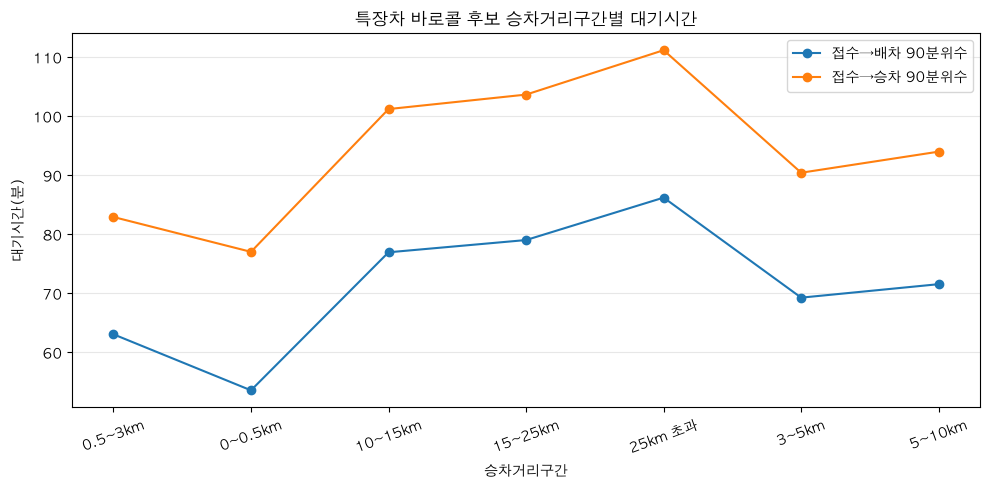

In [83]:
# 코드 셀 목적: 승차거리구간별 특장차 바로콜 후보의 대기시간을 확인한다.

distance_baro_summary = (
    special_ride_baro_call
    .groupby("승차거리구간", observed=False)
    .agg(
        승차완료건수=("접수_배차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(distance_baro_summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(distance_baro_summary["승차거리구간"].astype(str), distance_baro_summary["접수_배차_90분위수"], marker="o", label="접수→배차 90분위수")
ax.plot(distance_baro_summary["승차거리구간"].astype(str), distance_baro_summary["접수_승차_90분위수"], marker="o", label="접수→승차 90분위수")
ax.set_title("특장차 바로콜 후보 승차거리구간별 대기시간")
ax.set_xlabel("승차거리구간")
ax.set_ylabel("대기시간(분)")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


,출발구,세부이동유형,승차완료건수,접수_배차_중앙값,접수_배차_90분위수,접수_승차_중앙값,접수_승차_90분위수
72,안양시동안구,서울 외→서울,33,101.078000,159.886283,109.403333,193.799877
74,양주시,서울 외→서울,273,109.082783,154.522037,134.170950,176.178090
14,고양시일산서구,서울 외→서울,90,99.540558,150.455617,123.301783,168.891107
89,의정부시,서울 외→서울,281,77.316050,144.842950,98.633617,161.665833
13,고양시일산동구,서울 외→서울,365,89.921217,143.575383,115.043617,168.845720
61,성남시중원구,서울 외→서울,74,90.438133,142.839787,101.786800,163.590735
32,남양주시,서울 외→서울,677,91.277450,142.744953,113.838667,170.223070
48,부천시소사구,서울 외→서울,60,81.718950,141.683917,106.171250,173.452610
50,부천시원미구,서울 외→서울,146,79.364558,140.278967,98.323858,167.950000
19,광명시,서울 외→서울,198,76.691417,136.732218,97.500750,150.568350


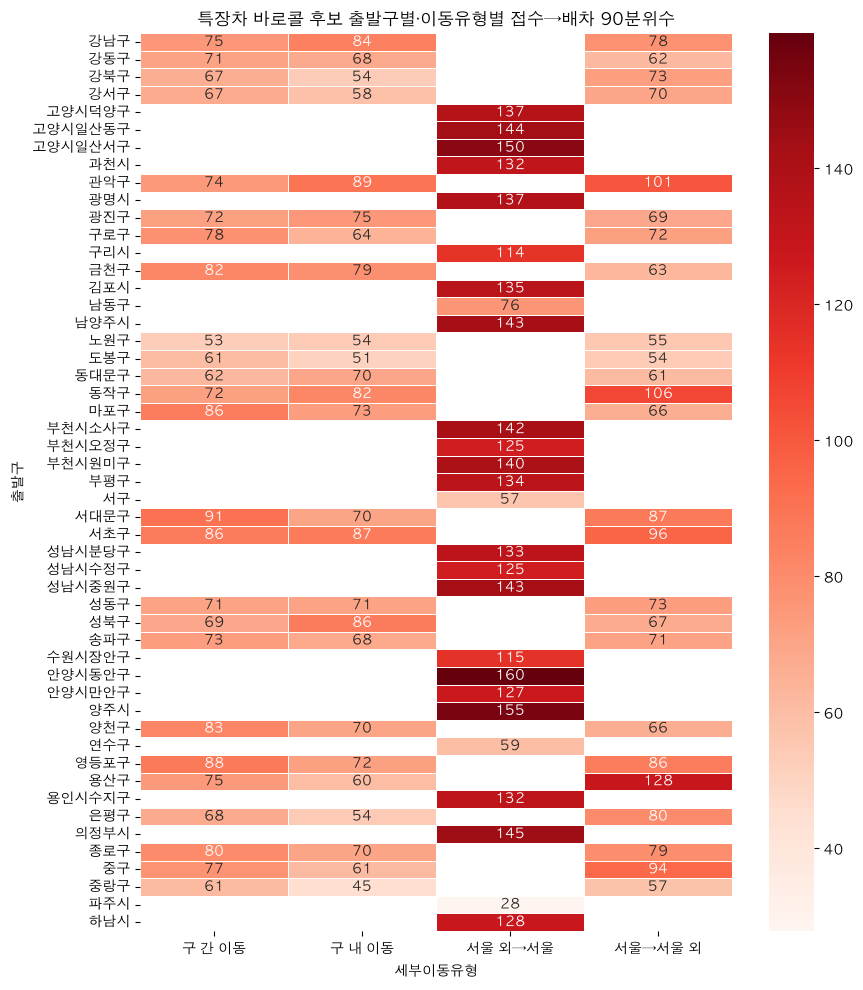

In [84]:
# 코드 셀 목적: 출발구별·세부이동유형별 접수→배차 90분위수와 승차완료건수를 확인한다.

district_movement_baro_summary = (
    special_ride_baro_call
    .groupby(["출발구", "세부이동유형"], observed=False)
    .agg(
        승차완료건수=("접수_배차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(district_movement_baro_summary.sort_values(["접수_배차_90분위수", "승차완료건수"], ascending=False).head(30))

heatmap_data = district_movement_baro_summary.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_배차_90분위수",
    aggfunc="median",
)

fig, ax = plt.subplots(figsize=(9, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Reds", linewidths=0.5, ax=ax)
ax.set_title("특장차 바로콜 후보 출발구별·이동유형별 접수→배차 90분위수")
ax.set_xlabel("세부이동유형")
ax.set_ylabel("출발구")
plt.tight_layout()
plt.show()


## 11. 장시간 대기 건 특징 분석

바로콜 후보 중 `접수→배차` 90분위수 이상인 장시간 대기 건이 특정 시간대, 요일, 지역, 이동유형, 승차거리구간에 집중되는지 확인한다.


In [85]:
# 코드 셀 목적: 특장차 바로콜 후보 중 접수→배차 장시간 대기 건의 특징을 확인한다.

dispatch_delay_cutoff = special_ride_baro_call["접수_배차_분"].quantile(0.90)
long_dispatch_baro = special_ride_baro_call[
    special_ride_baro_call["접수_배차_분"].ge(dispatch_delay_cutoff)
].copy()

print(f"접수→배차 장시간 기준(90분위수): {dispatch_delay_cutoff:.1f}분")
print(f"장시간 대기 건수: {len(long_dispatch_baro):,}건")

feature_cols = ["접수시간대", "접수요일", "출발구", "세부이동유형", "승차거리구간"]
for col in feature_cols:
    print(f"\n[{col}]")
    display(
        long_dispatch_baro[col]
        .value_counts(dropna=False)
        .reset_index(name="장시간대기건수")
        .head(20)
    )


접수→배차 장시간 기준(90분위수): 72.1분
장시간 대기 건수: 109,909건

[접수시간대]


,접수시간대,장시간대기건수
0,15:00:00,13708
1,16:00:00,10148
2,08:00:00,9801
3,05:00:00,9437
4,07:00:00,9073
5,09:00:00,7162
6,04:00:00,7115
7,14:00:00,5995
8,06:00:00,5938
9,10:00:00,5496



[접수요일]


,접수요일,장시간대기건수
0,수,21155
1,금,20545
2,월,19130
3,화,18406
4,목,17818
5,토,7133
6,일,5722



[출발구]


,출발구,장시간대기건수
0,서대문구,8293
1,마포구,7302
2,영등포구,6518
3,노원구,6479
4,강서구,5341
5,강동구,5258
6,강남구,5115
7,서초구,4992
8,관악구,4937
9,은평구,4506



[세부이동유형]


,세부이동유형,장시간대기건수
0,구 간 이동,65115
1,구 내 이동,32826
2,서울→서울 외,8658
3,서울 외→서울,3310



[승차거리구간]


,승차거리구간,장시간대기건수
0,5~10km,28070
1,3~5km,22635
2,0.5~3km,20437
3,10~15km,15206
4,15~25km,14131
5,25km 초과,9235
6,0~0.5km,195


## 12. 취소율과 대기시간 관계 분석

취소율은 승차 완료건수와 취소건수를 함께 보아야 한다. 이 단계에서는 접수시간대, 요일, 출발구, 세부이동유형별 취소율을 확인한다.


In [86]:
# 코드 셀 목적: 조건별 특장차 취소율을 계산한다.

def summarize_cancel_rate(ride_df, cancel_df, group_col):
    ride_summary = (
        ride_df.groupby(group_col, observed=False)
        .size()
        .reset_index(name="승차완료건수")
    )
    cancel_summary = (
        cancel_df.groupby(group_col, observed=False)
        .size()
        .reset_index(name="취소건수")
    )
    summary = ride_summary.merge(cancel_summary, on=group_col, how="outer")
    summary["승차완료건수"] = summary["승차완료건수"].fillna(0).astype(int)
    summary["취소건수"] = summary["취소건수"].fillna(0).astype(int)
    summary["전체접수건수"] = summary["승차완료건수"] + summary["취소건수"]
    summary["취소율(%)"] = summary["취소건수"] / summary["전체접수건수"] * 100
    return summary.sort_values(["취소율(%)", "전체접수건수"], ascending=False).reset_index(drop=True)

cancel_rate_by_hour = summarize_cancel_rate(special_ride_baro_call, special_cancel, "접수시간대")
cancel_rate_by_weekday = summarize_cancel_rate(special_ride_baro_call, special_cancel, "접수요일")
cancel_rate_by_district = summarize_cancel_rate(special_ride_baro_call, special_cancel, "출발구")
cancel_rate_by_movement = summarize_cancel_rate(special_ride_baro_call, special_cancel, "세부이동유형")

display(cancel_rate_by_hour)
display(cancel_rate_by_weekday)
display(cancel_rate_by_district.head(20))
display(cancel_rate_by_movement)


,접수시간대,승차완료건수,취소건수,전체접수건수,취소율(%)
0,05:00:00,12134,5674,17808,31.862084
1,16:00:00,52677,21409,74086,28.897498
2,21:00:00,7883,3178,11061,28.731579
3,17:00:00,33987,12791,46778,27.344051
4,04:00:00,10542,3864,14406,26.822157
5,20:00:00,14274,5024,19298,26.033786
6,22:00:00,4495,1541,6036,25.530152
7,23:00:00,2858,871,3729,23.357468
8,01:00:00,1024,305,1329,22.949586
9,00:00:00,1685,500,2185,22.883295


,접수요일,승차완료건수,취소건수,전체접수건수,취소율(%)
0,토,91178,22028,113206,19.458333
1,일,81902,19054,100956,18.873569
2,금,183115,40691,223806,18.181371
3,수,190139,39191,229330,17.089347
4,목,180334,37044,217378,17.041283
5,화,184885,36246,221131,16.391189
6,월,187531,34733,222264,15.626912


,출발구,승차완료건수,취소건수,전체접수건수,취소율(%)
0,수원시팔달구,0,1,1,100.000000
1,의왕시,0,1,1,100.000000
2,과천시,47,16,63,25.396825
3,고양시일산동구,365,119,484,24.586777
4,서초구,31576,9889,41465,23.849029
5,강남구,43214,13009,56223,23.138217
6,용산구,21779,6197,27976,22.151130
7,금천구,17962,4993,22955,21.751252
8,종로구,35008,9620,44628,21.555974
9,중구,19574,5364,24938,21.509343


,세부이동유형,승차완료건수,취소건수,전체접수건수,취소율(%)
0,서울→서울 외,77522,18141,95663,18.963445
1,구 내 이동,389964,81310,471274,17.253233
2,구 간 이동,626759,128620,755379,17.027214
3,서울 외→서울,4839,916,5755,15.916594


## 13. 배차 지연형과 배차 후 지연형 분리

바로콜 후보의 장시간 대기가 차량 배정 단계에서 발생하는지, 배차 후 차량 접근 단계에서 발생하는지 분리한다.


In [87]:
# 코드 셀 목적: 특장차 바로콜 후보의 지연유형을 접수→배차와 배차→승차 90분위수 기준으로 분리한다.

dispatch_delay_cutoff = special_ride_baro_call["접수_배차_분"].quantile(0.90)
pickup_delay_cutoff = special_ride_baro_call["배차_승차_분"].quantile(0.90)

special_ride_baro_call["접수_배차_장시간여부"] = special_ride_baro_call["접수_배차_분"].ge(dispatch_delay_cutoff)
special_ride_baro_call["배차_승차_장시간여부"] = special_ride_baro_call["배차_승차_분"].ge(pickup_delay_cutoff)

special_ride_baro_call["지연유형"] = "일반"
special_ride_baro_call.loc[
    special_ride_baro_call["접수_배차_장시간여부"] & ~special_ride_baro_call["배차_승차_장시간여부"],
    "지연유형",
] = "배차 지연형"
special_ride_baro_call.loc[
    ~special_ride_baro_call["접수_배차_장시간여부"] & special_ride_baro_call["배차_승차_장시간여부"],
    "지연유형",
] = "배차 후 지연형"
special_ride_baro_call.loc[
    special_ride_baro_call["접수_배차_장시간여부"] & special_ride_baro_call["배차_승차_장시간여부"],
    "지연유형",
] = "복합 지연형"

delay_type_summary = (
    special_ride_baro_call
    .groupby("지연유형", observed=False)
    .agg(
        건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)
delay_type_summary["비율(%)"] = delay_type_summary["건수"] / delay_type_summary["건수"].sum() * 100

display(delay_type_summary.sort_values("건수", ascending=False))


,지연유형,건수,접수_배차_중앙값,접수_배차_90분위수,배차_승차_중앙값,배차_승차_90분위수,접수_승차_중앙값,접수_승차_90분위수,비율(%)
3,일반,897734,9.874117,46.827652,16.661217,25.306182,28.986692,64.895450,81.680199
1,배차 후 지연형,91441,14.896833,58.014117,33.317167,42.262267,50.953883,93.403667,8.319746
0,배차 지연형,91438,114.112167,143.553933,18.662775,26.511722,132.966200,163.173903,8.319473
2,복합 지연형,18471,98.068667,137.670500,34.256617,44.873950,135.688717,175.346450,1.680581
